In [1]:
import ee
import re
import geemap
import numpy as np
import matplotlib.pyplot as plt
import osmnx as ox
from geopy.geocoders import Nominatim
import os
import pandas as pd


# Plot

In [2]:
class CityMapProcessor:
    def __init__(self, city_name):
        self.city_name = city_name
        self.boundary_data = None
        self.array = None
        self.output_resolution = (1024, 1024)  # Width x Height in pixels
        self.dpi = 100  # Dots per inch
        self.figsize = (self.output_resolution[0] / self.dpi, self.output_resolution[1] / self.dpi)
        self.output_dir = "/home/salvador_cb/3_term/Applied_research_studio/data/img/train"
        os.makedirs(self.output_dir, exist_ok=True)
        self.authenticate_and_initialize()

    def authenticate_and_initialize(self):
        # Authenticate and initialize Earth Engine
        ee.Authenticate()
        ee.Initialize(project='ee-salvadorcantuarias')  # Replace with your actual project ID

    def get_osm_boundary(self):
        # Get the bounding box for the city
        geolocator = Nominatim(user_agent="geoapi", timeout=10)
        try:
            location = geolocator.geocode(self.city_name, exactly_one=True)
            if location:
                bbox = location.raw.get('boundingbox', None)
                if bbox:
                    lat_min, lat_max, lon_min, lon_max = map(float, bbox)
                    self.boundary_data = {
                        "bbox": (lon_min, lat_min, lon_max, lat_max),
                        "gee_rectangle": ee.Geometry.BBox(lon_min, lat_min, lon_max, lat_max)
                    }
        except Exception as e:
            print(f"Error fetching bbox for {self.city_name}: {e}")

    def load_elevation_data(self):
        # Load elevation data from Google Earth Engine
        layer = "NASA/NASADEM_HGT/001"
        band = "elevation"
        image = ee.Image(layer).select(band)
        self.array = geemap.ee_to_numpy(image, region=self.boundary_data["gee_rectangle"], bands=[band])

    def save_image(self, ax, file_path):
        # Save the image with consistent resolution and no padding
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('auto')  # Ensure the aspect ratio matches the data
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Remove padding
        plt.savefig(file_path, dpi=self.dpi, bbox_inches="tight", pad_inches=0)
        plt.close()
        print(f"Image saved to {file_path}")

    def save_elevation_layer(self):
        # Save the elevation layer as an image
        if self.array is not None:
            fig, ax = plt.subplots(figsize=self.figsize, dpi=self.dpi)
            minx, miny, maxx, maxy = self.boundary_data["bbox"]
            self.array = self.array.astype(np.float32) / np.max(self.array)  # Normalize
            ax.imshow(self.array, extent=[minx, maxx, miny, maxy], origin="upper", cmap="gray")
            ax.set_xlim(minx, maxx)
            ax.set_ylim(miny, maxy)
            elevation_path = os.path.join(self.output_dir, f"elevation/{self.city_name}_elevation.png")
            if os.path.exists(elevation_path):
                print(f"Elevation for {self.city_name} already exist. Skipping...")
            else:
                self.save_image(ax, elevation_path)

    def save_street_layout(self):
        # Save the street layout as an image
        fig, ax = plt.subplots(figsize=self.figsize, dpi=self.dpi)
        G = ox.graph_from_bbox(self.boundary_data["bbox"], network_type='drive')
        gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
        gdf_edges.plot(ax=ax, color="red", linewidth=0.5, alpha=1)
        minx, miny, maxx, maxy = self.boundary_data["bbox"]
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        street_layout_path = os.path.join(self.output_dir, f"street/{self.city_name}_street_network.png")
        if os.path.exists(street_layout_path):
            print(f"Street layout for {self.city_name} already exist. Skipping...")
        else:
            self.save_image(ax, street_layout_path)

    def save_overlap(self):
        # Save the overlap of elevation and street layout as an image
        fig, ax = plt.subplots(figsize=self.figsize, dpi=self.dpi)
        if self.array is not None:
            minx, miny, maxx, maxy = self.boundary_data["bbox"]
            ax.imshow(self.array, extent=[minx, maxx, miny, maxy], origin="upper", cmap="gray")
        G = ox.graph_from_bbox(self.boundary_data["bbox"], network_type='drive')
        gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
        gdf_edges.plot(ax=ax, color="red", linewidth=0.5, alpha=1)
        minx, miny, maxx, maxy = self.boundary_data["bbox"]
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        overlap_path = os.path.join(self.output_dir, f"overlap/{self.city_name}_overlap.png")
        if os.path.exists(overlap_path):
            print(f"Overlap for {self.city_name} already exist. Skipping...")
        else:
            self.save_image(ax, overlap_path)

    def process(self):
        try:
            self.get_osm_boundary()
            if self.boundary_data is None:
                print(f"Could not fetch boundary data for {self.city_name}. Skipping...")
                return

            self.load_elevation_data()
            self.save_elevation_layer()
            self.save_street_layout()
            self.save_overlap()
        except Exception as e:
            print(f"An error occurred while processing {self.city_name}: {e}. Skipping...")

In [3]:
metadata_csv_path = "/home/salvador_cb/3_term/Applied_research_studio/data/csv/metadata.csv"

# Read the CSV file
metadata_df = pd.read_csv(metadata_csv_path)

# Extract the 'file_name' column into a list
file_names = metadata_df['file_name'].tolist()

# Print the list to verify
print(file_names)

['Aberdeen, UK_elevation.png', 'Abidjan, Ivory Coast_elevation.png', 'Accra, Ghana_elevation.png', 'Addis Ababa, Ethiopia_elevation.png', 'Ahmadabad, India_elevation.png', 'Aleppo, Syria_elevation.png', 'Alexandria, Egypt_elevation.png', 'Algiers, Algeria_elevation.png', 'Ankara, Turkey_elevation.png', 'Antananarivo, Madagascar_elevation.png', 'Apia, Samoa_elevation.png', 'Athens, Greece_elevation.png', 'Atlanta, USA_elevation.png', 'Baghdad, Iraq_elevation.png', 'Bandar Seri Begawan, Brunei_elevation.png', 'Bandung, Indonesia_elevation.png', 'Bangalore, India_elevation.png', 'Bangkok, Thailand_elevation.png', 'Banjul, Gambia_elevation.png', 'Barcelona, Spain_elevation.png', 'Basseterre, Saint Kitts and Nevis_elevation.png', 'Belfast, UK_elevation.png', 'Belgrade, Serbia_elevation.png', 'Belo Horizonte, Brazil_elevation.png', 'Bilbao, Spain_elevation.png', 'Birmingham, UK_elevation.png', 'Bogota, Colombia_elevation.png', 'Bordeaux, France_elevation.png', 'Boston, USA_elevation.png', 'B

### cities lists

In [4]:
# Albania
albania = [
    "Tirana, Albania", "Durres, Albania", "Vlore, Albania", "Shkoder, Albania", "Fier, Albania",
    "Sarande, Albania", "Berat, Albania", "Elbasan, Albania", "Korce, Albania", "Gjirokaster, Albania",
    "Lushnje, Albania", "Kukes, Albania", "Pogradec, Albania"
]

# Bosnia and Herzegovina
bosnia_and_herzegovina = [
    "Sarajevo, Bosnia and Herzegovina", "Banja Luka, Bosnia and Herzegovina", "Mostar, Bosnia and Herzegovina",
    "Tuzla, Bosnia and Herzegovina", "Zenica, Bosnia and Herzegovina", "Bijeljina, Bosnia and Herzegovina",
    "Prijedor, Bosnia and Herzegovina", "Trebinje, Bosnia and Herzegovina"
]

# Bulgaria
bulgaria = [
    "Sofia, Bulgaria", "Plovdiv, Bulgaria", "Varna, Bulgaria", "Burgas, Bulgaria", "Ruse, Bulgaria",
    "Stara Zagora, Bulgaria", "Pleven, Bulgaria", "Sliven, Bulgaria", "Dobrich, Bulgaria",
    "Haskovo, Bulgaria", "Shumen, Bulgaria", "Pazardzhik, Bulgaria", "Blagoevgrad, Bulgaria",
    "Veliko Tarnovo, Bulgaria"
]

# Croatia
croatia = [
    "Zagreb, Croatia", "Split, Croatia", "Rijeka, Croatia", "Osijek, Croatia", "Zadar, Croatia",
    "Dubrovnik, Croatia", "Pula, Croatia", "Slavonski Brod, Croatia", "Karlovac, Croatia",
    "Varaždin, Croatia", "Šibenik, Croatia"
]

# Greece
greece = [
    "Athens, Greece", "Thessaloniki, Greece", "Patras, Greece", "Heraklion, Greece", "Larissa, Greece",
    "Volos, Greece", "Ioannina, Greece", "Chania, Greece", "Kalamata, Greece", "Kavala, Greece",
    "Rhodes, Greece", "Serres, Greece", "Alexandroupoli, Greece"
]

# Kosovo
kosovo = [
    "Pristina, Kosovo", "Peja, Kosovo", "Mitrovica, Kosovo", "Gjilan, Kosovo", "Ferizaj, Kosovo",
    "Gjakova, Kosovo"
]

# Montenegro
montenegro = [
    "Podgorica, Montenegro", "Niksic, Montenegro", "Herceg Novi, Montenegro", "Bar, Montenegro",
    "Bijelo Polje, Montenegro", "Budva, Montenegro", "Cetinje, Montenegro"
]

# North Macedonia
north_macedonia = [
    "Skopje, North Macedonia", "Bitola, North Macedonia", "Prilep, North Macedonia", "Tetovo, North Macedonia",
    "Kumanovo, North Macedonia", "Ohrid, North Macedonia", "Veles, North Macedonia", "Strumica, North Macedonia"
]

# Romania
romania = [
    "Bucharest, Romania", "Cluj Napoca, Romania", "Timisoara, Romania", "Iasi, Romania", "Constanta, Romania",
    "Craiova, Romania", "Brasov, Romania", "Galati, Romania", "Arad, Romania", "Sibiu, Romania",
    "Oradea, Romania", "Ploiesti, Romania"
]

# Serbia
serbia = [
    "Belgrade, Serbia", "Novi Sad, Serbia", "Niš, Serbia", "Kragujevac, Serbia", "Subotica, Serbia",
    "Zrenjanin, Serbia", "Pančevo, Serbia", "Čačak, Serbia", "Leskovac, Serbia", "Kraljevo, Serbia",
    "Sombor, Serbia"
]

# Slovenia
slovenia = [
    "Ljubljana, Slovenia", "Maribor, Slovenia", "Celje, Slovenia", "Kranj, Slovenia",
    "Nova Gorica, Slovenia", "Ptuj, Slovenia"
]

# List of Balkan countries variables
balkan_countries = [
    albania, bosnia_and_herzegovina, bulgaria, croatia, greece, kosovo,
    montenegro, north_macedonia, romania, serbia, slovenia
]

In [5]:
# Armenia
armenia = [
    "Yerevan, Armenia", "Gyumri, Armenia", "Vanadzor, Armenia", "Hrazdan, Armenia", "Abovyan, Armenia",
    "Kapan, Armenia", "Ijevan, Armenia", "Gavar, Armenia"
]

# Azerbaijan
azerbaijan = [
    "Baku, Azerbaijan", "Ganja, Azerbaijan", "Sumqayit, Azerbaijan", "Mingachevir, Azerbaijan",
    "Lankaran, Azerbaijan", "Shirvan, Azerbaijan", "Nakhchivan, Azerbaijan"
]

# Bahrain
bahrain = [
    "Manama, Bahrain", "Riffa, Bahrain", "Muharraq, Bahrain", "Hamad Town, Bahrain", "Isa Town, Bahrain"
]

# Cyprus
cyprus = [
    "Nicosia, Cyprus", "Limassol, Cyprus", "Larnaca, Cyprus", "Famagusta, Cyprus", "Paphos, Cyprus"
]

# Georgia
georgia = [
    "Tbilisi, Georgia", "Kutaisi, Georgia", "Batumi, Georgia", "Rustavi, Georgia", "Gori, Georgia",
    "Zugdidi, Georgia", "Poti, Georgia", "Telavi, Georgia"
]

# Iran
iran = [
    "Tehran, Iran", "Mashhad, Iran", "Isfahan, Iran", "Karaj, Iran", "Tabriz, Iran", "Shiraz, Iran",
    "Ahvaz, Iran", "Qom, Iran", "Kermanshah, Iran", "Rasht, Iran", "Kerman, Iran", "Orumiyeh, Iran",
    "Hamedan, Iran", "Yazd, Iran"
]

# Iraq
iraq = [
    "Baghdad, Iraq", "Basra, Iraq", "Mosul, Iraq", "Erbil, Iraq", "Sulaymaniyah, Iraq", "Kirkuk, Iraq",
    "Najaf, Iraq", "Karbala, Iraq"
]

# Israel
israel = [
    "Jerusalem, Israel", "Tel Aviv, Israel", "Haifa, Israel", "Rishon LeZion, Israel", "Petah Tikva, Israel",
    "Ashdod, Israel", "Netanya, Israel", "Beersheba, Israel"
]

# Jordan
jordan = [
    "Amman, Jordan", "Zarqa, Jordan", "Irbid, Jordan", "Aqaba, Jordan", "Madaba, Jordan",
    "Salt, Jordan", "Jerash, Jordan"
]

# Kazakhstan
kazakhstan = [
    "Almaty, Kazakhstan", "Astana, Kazakhstan", "Shymkent, Kazakhstan", "Karaganda, Kazakhstan",
    "Aktobe, Kazakhstan", "Taraz, Kazakhstan", "Pavlodar, Kazakhstan"
]

# Kuwait
kuwait = [
    "Kuwait City, Kuwait", "Hawalli, Kuwait", "Al Ahmadi, Kuwait", "Farwaniya, Kuwait"
]

# Lebanon
lebanon = [
    "Beirut, Lebanon", "Tripoli, Lebanon", "Sidon, Lebanon", "Zahle, Lebanon", "Jounieh, Lebanon",
    "Tyre, Lebanon", "Baabda, Lebanon"
]

# Oman
oman = [
    "Muscat, Oman", "Salalah, Oman", "Sohar, Oman", "Nizwa, Oman"
]

# Qatar
qatar = [
    "Doha, Qatar", "Al Wakrah, Qatar", "Al Khor, Qatar", "Umm Salal, Qatar"
]

# Saudi Arabia
saudi_arabia = [
    "Riyadh, Saudi Arabia", "Jeddah, Saudi Arabia", "Mecca, Saudi Arabia", "Medina, Saudi Arabia",
    "Dammam, Saudi Arabia", "Khobar, Saudi Arabia", "Tabuk, Saudi Arabia"
]

# Syria
syria = [
    "Damascus, Syria", "Aleppo, Syria", "Homs, Syria", "Latakia, Syria", "Hama, Syria",
    "Raqqa, Syria", "Deir ez-Zor, Syria"
]

# Turkey
turkey = [
    "Istanbul, Turkey", "Ankara, Turkey", "Izmir, Turkey", "Bursa, Turkey", "Adana, Turkey",
    "Gaziantep, Turkey", "Konya, Turkey", "Antalya, Turkey"
]

# Turkmenistan
turkmenistan = [
    "Ashgabat, Turkmenistan", "Turkmenabat, Turkmenistan", "Mary, Turkmenistan", "Dashoguz, Turkmenistan"
]

# United Arab Emirates
uae = [
    "Dubai, United Arab Emirates", "Abu Dhabi, United Arab Emirates", "Sharjah, United Arab Emirates",
    "Ajman, United Arab Emirates", "Fujairah, United Arab Emirates"
]

# Uzbekistan
uzbekistan = [
    "Tashkent, Uzbekistan", "Samarkand, Uzbekistan", "Bukhara, Uzbekistan", "Andijan, Uzbekistan",
    "Nukus, Uzbekistan", "Fergana, Uzbekistan", "Navoi, Uzbekistan"
]

# Yemen
yemen = [
    "Sanaa, Yemen", "Aden, Yemen", "Taiz, Yemen", "Al Hudaydah, Yemen", "Ibb, Yemen"
]

# List of Western Asia and Eurasia country variables
western_asia_eurasia_countries = [
    armenia, azerbaijan, bahrain, cyprus, georgia, iran, iraq, israel, jordan,
    kazakhstan, kuwait, lebanon, oman, qatar, saudi_arabia, syria, turkey, turkmenistan,
    uae, uzbekistan, yemen
]

In [6]:
# Kazakhstan
kazakhstan = [
    "Almaty, Kazakhstan", "Astana, Kazakhstan", "Shymkent, Kazakhstan", "Karaganda, Kazakhstan",
    "Aktobe, Kazakhstan", "Taraz, Kazakhstan", "Pavlodar, Kazakhstan", "Ust-Kamenogorsk, Kazakhstan",
    "Semey, Kazakhstan", "Atyrau, Kazakhstan", "Kostanay, Kazakhstan", "Kyzylorda, Kazakhstan",
    "Petropavl, Kazakhstan", "Taldykorgan, Kazakhstan"
]

# Kyrgyzstan
kyrgyzstan = [
    "Bishkek, Kyrgyzstan", "Osh, Kyrgyzstan", "Jalal-Abad, Kyrgyzstan", "Karakol, Kyrgyzstan",
    "Tokmok, Kyrgyzstan", "Talas, Kyrgyzstan", "Naryn, Kyrgyzstan", "Batken, Kyrgyzstan"
]

# Tajikistan
tajikistan = [
    "Dushanbe, Tajikistan", "Khujand, Tajikistan", "Bokhtar, Tajikistan", "Kulob, Tajikistan",
    "Istaravshan, Tajikistan", "Tursunzoda, Tajikistan", "Isfara, Tajikistan", "Panjakent, Tajikistan"
]

# Turkmenistan
turkmenistan = [
    "Ashgabat, Turkmenistan", "Turkmenabat, Turkmenistan", "Mary, Turkmenistan", "Dashoguz, Turkmenistan",
    "Balkanabat, Turkmenistan", "Serdar, Turkmenistan"
]

# Uzbekistan
uzbekistan = [
    "Tashkent, Uzbekistan", "Samarkand, Uzbekistan", "Bukhara, Uzbekistan", "Andijan, Uzbekistan",
    "Nukus, Uzbekistan", "Fergana, Uzbekistan", "Namangan, Uzbekistan", "Navoi, Uzbekistan",
    "Kokand, Uzbekistan", "Jizzakh, Uzbekistan", "Termez, Uzbekistan"
]

# List of Central Asian country variables
central_asian_countries = [
    kazakhstan, kyrgyzstan, tajikistan, turkmenistan, uzbekistan
]

In [7]:
# Afghanistan
afghanistan = [
    "Kabul, Afghanistan", "Herat, Afghanistan", "Kandahar, Afghanistan", "Mazar-e-Sharif, Afghanistan",
    "Jalalabad, Afghanistan", "Ghazni, Afghanistan", "Khost, Afghanistan", "Kunduz, Afghanistan",
    "Pul-e-Khumri, Afghanistan"
]

# Bangladesh
bangladesh = [
    "Dhaka, Bangladesh", "Chittagong, Bangladesh", "Khulna, Bangladesh", "Rajshahi, Bangladesh",
    "Comilla, Bangladesh", "Sylhet, Bangladesh", "Mymensingh, Bangladesh", "Barisal, Bangladesh",
    "Jessore, Bangladesh", "Narayanganj, Bangladesh", "Bogra, Bangladesh"
]

# Bhutan
bhutan = [
    "Thimphu, Bhutan", "Phuentsholing, Bhutan", "Paro, Bhutan", "Punakha, Bhutan", "Gelephu, Bhutan",
    "Wangdue Phodrang, Bhutan", "Samdrup Jongkhar, Bhutan"
]

# India
india = [
    "Mumbai, India", "Delhi, India", "Bangalore, India", "Hyderabad, India", "Chennai, India",
    "Kolkata, India", "Ahmedabad, India", "Pune, India", "Jaipur, India", "Lucknow, India",
    "Kanpur, India", "Nagpur, India", "Indore, India", "Thane, India", "Bhopal, India",
    "Visakhapatnam, India", "Patna, India", "Vadodara, India", "Ghaziabad, India", "Ludhiana, India",
    "Coimbatore, India", "Agra, India", "Madurai, India", "Rajkot, India", "Varanasi, India",
    "Meerut, India", "Faridabad, India", "Amritsar, India"
]

# Maldives
maldives = [
    "Male, Maldives", "Hithadhoo, Maldives", "Addu City, Maldives", "Kulhudhuffushi, Maldives"
]

# Nepal
nepal = [
    "Kathmandu, Nepal", "Pokhara, Nepal", "Lalitpur, Nepal", "Biratnagar, Nepal", "Birgunj, Nepal",
    "Dharan, Nepal", "Bharatpur, Nepal", "Butwal, Nepal", "Hetauda, Nepal", "Janakpur, Nepal"
]

# Pakistan
pakistan = [
    "Karachi, Pakistan", "Lahore, Pakistan", "Islamabad, Pakistan", "Rawalpindi, Pakistan", 
    "Faisalabad, Pakistan", "Multan, Pakistan", "Peshawar, Pakistan", "Quetta, Pakistan", 
    "Gujranwala, Pakistan", "Sialkot, Pakistan", "Bahawalpur, Pakistan", "Sargodha, Pakistan",
    "Sukkur, Pakistan", "Larkana, Pakistan"
]

# Sri Lanka
sri_lanka = [
    "Colombo, Sri Lanka", "Kandy, Sri Lanka", "Galle, Sri Lanka", "Jaffna, Sri Lanka", "Negombo, Sri Lanka",
    "Matara, Sri Lanka", "Anuradhapura, Sri Lanka", "Batticaloa, Sri Lanka", "Ratnapura, Sri Lanka"
]

# List of South Asian country variables
south_asian_countries = [
    afghanistan, bangladesh, bhutan, india, maldives, nepal, pakistan, sri_lanka
]

In [8]:
# Brunei
brunei = [
    "Bandar Seri Begawan, Brunei", "Kuala Belait, Brunei", "Seria, Brunei", "Tutong, Brunei"
]

# Cambodia
cambodia = [
    "Phnom Penh, Cambodia", "Siem Reap, Cambodia", "Battambang, Cambodia", "Sihanoukville, Cambodia",
    "Kampong Cham, Cambodia", "Kampot, Cambodia", "Poipet, Cambodia", "Takeo, Cambodia"
]

# Indonesia
indonesia = [
    "Jakarta, Indonesia", "Surabaya, Indonesia", "Bandung, Indonesia", "Medan, Indonesia",
    "Semarang, Indonesia", "Makassar, Indonesia", "Palembang, Indonesia", "Bogor, Indonesia",
    "Denpasar, Indonesia", "Malang, Indonesia", "Pekanbaru, Indonesia", "Padang, Indonesia"
]

# Laos
laos = [
    "Vientiane, Laos", "Luang Prabang, Laos", "Savannakhet, Laos", "Pakse, Laos", "Thakhek, Laos",
    "Xam Neua, Laos"
]

# Malaysia
malaysia = [
    "Kuala Lumpur, Malaysia", "George Town, Malaysia", "Johor Bahru, Malaysia", "Ipoh, Malaysia",
    "Kota Kinabalu, Malaysia", "Malacca, Malaysia", "Kuching, Malaysia", "Alor Setar, Malaysia",
    "Miri, Malaysia"
]

# Myanmar
myanmar = [
    "Yangon, Myanmar", "Mandalay, Myanmar", "Naypyidaw, Myanmar", "Mawlamyine, Myanmar",
    "Bago, Myanmar", "Sittwe, Myanmar", "Taunggyi, Myanmar"
]

# Philippines
philippines = [
    "Manila, Philippines", "Quezon City, Philippines", "Cebu City, Philippines", "Davao City, Philippines",
    "Zamboanga City, Philippines", "Taguig, Philippines", "Antipolo, Philippines", "Pasig, Philippines",
    "Cagayan de Oro, Philippines", "Iloilo City, Philippines", "Bacolod, Philippines"
]

# Singapore
singapore = [
    "Singapore, Singapore"
]

# Thailand
thailand = [
    "Bangkok, Thailand", "Chiang Mai, Thailand", "Pattaya, Thailand", "Phuket, Thailand", "Hat Yai, Thailand",
    "Khon Kaen, Thailand", "Nakhon Ratchasima, Thailand", "Udon Thani, Thailand"
]

# Timor-Leste
timor_leste = [
    "Dili, Timor-Leste", "Baucau, Timor-Leste", "Maliana, Timor-Leste"
]

# Vietnam
vietnam = [
    "Hanoi, Vietnam", "Ho Chi Minh City, Vietnam", "Da Nang, Vietnam", "Hai Phong, Vietnam",
    "Nha Trang, Vietnam", "Can Tho, Vietnam", "Hue, Vietnam", "Vung Tau, Vietnam"
]

# List of Southeast Asian country variables
southeast_asian_countries = [
    brunei, cambodia, indonesia, laos, malaysia, myanmar, philippines, singapore,
    thailand, timor_leste, vietnam
]

In [9]:
# China
china = [
    "Beijing, China", "Shanghai, China", "Guangzhou, China", "Shenzhen, China", "Chengdu, China",
    "Chongqing, China", "Wuhan, China", "Xi'an, China", "Nanjing, China", "Hangzhou, China",
    "Suzhou, China", "Tianjin, China", "Changsha, China", "Harbin, China", "Shenyang, China",
    "Qingdao, China", "Dalian, China", "Kunming, China", "Xiamen, China", "Fuzhou, China"
]

# Hong Kong (Special Administrative Region)
hong_kong = [
    "Hong Kong, Hong Kong", "Kowloon, Hong Kong", "Tuen Mun, Hong Kong", "Sha Tin, Hong Kong",
    "Yuen Long, Hong Kong", "Tsuen Wan, Hong Kong"
]

# Japan
japan = [
    "Tokyo, Japan", "Osaka, Japan", "Yokohama, Japan", "Nagoya, Japan", "Sapporo, Japan",
    "Fukuoka, Japan", "Kobe, Japan", "Kyoto, Japan", "Hiroshima, Japan", "Sendai, Japan",
    "Chiba, Japan", "Kitakyushu, Japan", "Shizuoka, Japan", "Niigata, Japan", "Okayama, Japan"
]

# Macau (Special Administrative Region)
macau = [
    "Macau, Macau", "Taipa, Macau", "Coloane, Macau"
]

# Mongolia
mongolia = [
    "Ulaanbaatar, Mongolia", "Erdenet, Mongolia", "Darkhan, Mongolia", "Choibalsan, Mongolia",
    "Mörön, Mongolia"
]

# North Korea
north_korea = [
    "Pyongyang, North Korea", "Hamhung, North Korea", "Nampo, North Korea", "Kaesong, North Korea",
    "Chongjin, North Korea"
]

# South Korea
south_korea = [
    "Seoul, South Korea", "Busan, South Korea", "Incheon, South Korea", "Daegu, South Korea",
    "Daejeon, South Korea", "Gwangju, South Korea", "Ulsan, South Korea", "Suwon, South Korea",
    "Goyang, South Korea", "Changwon, South Korea"
]

# Taiwan
taiwan = [
    "Taipei, Taiwan", "Kaohsiung, Taiwan", "Taichung, Taiwan", "Tainan, Taiwan", "Keelung, Taiwan",
    "Hsinchu, Taiwan", "Taoyuan, Taiwan"
]

# List of East Asian country variables
east_asian_countries = [
    china, hong_kong, japan, macau, mongolia, north_korea, south_korea, taiwan
]

In [10]:
# Australia
australia = [
    "Sydney, Australia", "Melbourne, Australia", "Brisbane, Australia", "Perth, Australia",
    "Adelaide, Australia", "Gold Coast, Australia", "Canberra, Australia", "Newcastle, Australia",
    "Hobart, Australia", "Darwin, Australia", "Cairns, Australia", "Townsville, Australia",
    "Wollongong, Australia", "Geelong, Australia"
]

# Fiji
fiji = [
    "Suva, Fiji", "Nadi, Fiji", "Lautoka, Fiji", "Labasa, Fiji", "Ba, Fiji", "Levuka, Fiji"
]

# Kiribati
kiribati = [
    "Tarawa, Kiribati", "Betio, Kiribati", "Bairiki, Kiribati"
]

# Marshall Islands
marshall_islands = [
    "Majuro, Marshall Islands", "Ebeye, Marshall Islands"
]

# Micronesia (Federated States of Micronesia)
micronesia = [
    "Palikir, Micronesia", "Weno, Micronesia", "Kolonia, Micronesia"
]

# Nauru
nauru = [
    "Yaren, Nauru", "Denigomodu, Nauru"
]

# New Zealand
new_zealand = [
    "Auckland, New Zealand", "Wellington, New Zealand", "Christchurch, New Zealand",
    "Hamilton, New Zealand", "Dunedin, New Zealand", "Tauranga, New Zealand", "Napier, New Zealand",
    "Palmerston North, New Zealand", "Nelson, New Zealand", "Rotorua, New Zealand"
]

# Palau
palau = [
    "Ngerulmud, Palau", "Koror, Palau", "Melekeok, Palau"
]

# Papua New Guinea
papua_new_guinea = [
    "Port Moresby, Papua New Guinea", "Lae, Papua New Guinea", "Madang, Papua New Guinea",
    "Mount Hagen, Papua New Guinea", "Goroka, Papua New Guinea"
]

# Samoa
samoa = [
    "Apia, Samoa", "Vaitele, Samoa", "Faleasiu, Samoa"
]

# Solomon Islands
solomon_islands = [
    "Honiara, Solomon Islands", "Auki, Solomon Islands", "Gizo, Solomon Islands"
]

# Tonga
tonga = [
    "Nuku'alofa, Tonga", "Neiafu, Tonga", "Mu'a, Tonga"
]

# Tuvalu
tuvalu = [
    "Funafuti, Tuvalu", "Vaiaku, Tuvalu"
]

# Vanuatu
vanuatu = [
    "Port Vila, Vanuatu", "Luganville, Vanuatu"
]

# List of Oceania country variables
oceania_countries = [
    australia, fiji, kiribati, marshall_islands, micronesia, nauru, new_zealand,
    palau, papua_new_guinea, samoa, solomon_islands, tonga, tuvalu, vanuatu
]

In [11]:
# Algeria
algeria = [
    "Algiers, Algeria", "Oran, Algeria", "Constantine, Algeria", "Annaba, Algeria",
    "Batna, Algeria", "Blida, Algeria", "Sétif, Algeria", "Tlemcen, Algeria",
    "Tizi Ouzou, Algeria", "Béjaïa, Algeria", "Skikda, Algeria", "Ghardaïa, Algeria",
    "Mostaganem, Algeria", "Djelfa, Algeria"
]

# Egypt
egypt = [
    "Cairo, Egypt", "Alexandria, Egypt", "Giza, Egypt", "Shubra El Kheima, Egypt",
    "Port Said, Egypt", "Suez, Egypt", "Luxor, Egypt", "Aswan, Egypt", "Ismailia, Egypt",
    "Faiyum, Egypt", "Mansoura, Egypt", "Tanta, Egypt", "Damietta, Egypt", "Qena, Egypt"
]

# Libya
libya = [
    "Tripoli, Libya", "Benghazi, Libya", "Misrata, Libya", "Bayda, Libya",
    "Zawiya, Libya", "Sabha, Libya", "Derna, Libya", "Sirte, Libya"
]

# Morocco
morocco = [
    "Casablanca, Morocco", "Rabat, Morocco", "Marrakech, Morocco", "Fes, Morocco",
    "Tangier, Morocco", "Agadir, Morocco", "Meknes, Morocco", "Oujda, Morocco",
    "Kenitra, Morocco", "Tetouan, Morocco", "El Jadida, Morocco", "Beni Mellal, Morocco"
]

# Sudan
sudan = [
    "Khartoum, Sudan", "Omdurman, Sudan", "Port Sudan, Sudan", "Nyala, Sudan",
    "Kassala, Sudan", "El Obeid, Sudan", "Wad Madani, Sudan", "Al Fashir, Sudan"
]

# Tunisia
tunisia = [
    "Tunis, Tunisia", "Sfax, Tunisia", "Sousse, Tunisia", "Kairouan, Tunisia",
    "Gabes, Tunisia", "Bizerte, Tunisia", "Gafsa, Tunisia", "Nabeul, Tunisia"
]

# Western Sahara (territory claimed by Morocco)
western_sahara = [
    "El Aaiún, Western Sahara", "Dakhla, Western Sahara", "Smara, Western Sahara",
    "Boujdour, Western Sahara"
]

# List of North African country variables
north_african_countries = [
    algeria, egypt, libya, morocco, sudan, tunisia, western_sahara
]

In [12]:
# Benin
benin = [
    "Cotonou, Benin", "Porto-Novo, Benin", "Parakou, Benin", "Abomey, Benin",
    "Natitingou, Benin", "Djougou, Benin", "Bohicon, Benin", "Kandi, Benin"
]

# Burkina Faso
burkina_faso = [
    "Ouagadougou, Burkina Faso", "Bobo-Dioulasso, Burkina Faso", "Koudougou, Burkina Faso",
    "Banfora, Burkina Faso", "Ouahigouya, Burkina Faso", "Fada N'gourma, Burkina Faso",
    "Tenkodogo, Burkina Faso"
]

# Cape Verde
cape_verde = [
    "Praia, Cape Verde", "Mindelo, Cape Verde", "Santa Maria, Cape Verde",
    "Assomada, Cape Verde", "Espargos, Cape Verde"
]

# Ivory Coast
ivory_coast = [
    "Abidjan, Ivory Coast", "Yamoussoukro, Ivory Coast", "Bouaké, Ivory Coast",
    "San Pedro, Ivory Coast", "Daloa, Ivory Coast", "Korhogo, Ivory Coast",
    "Man, Ivory Coast", "Gagnoa, Ivory Coast"
]

# Gambia
gambia = [
    "Banjul, Gambia", "Serrekunda, Gambia", "Brikama, Gambia", "Farafenni, Gambia",
    "Kerewan, Gambia", "Basse Santa Su, Gambia"
]

# Ghana
ghana = [
    "Accra, Ghana", "Kumasi, Ghana", "Tamale, Ghana", "Takoradi, Ghana",
    "Sunyani, Ghana", "Cape Coast, Ghana", "Tema, Ghana", "Ho, Ghana",
    "Koforidua, Ghana", "Wa, Ghana", "Bolgatanga, Ghana"
]

# Guinea
guinea = [
    "Conakry, Guinea", "Kankan, Guinea", "Nzérékoré, Guinea", "Kindia, Guinea",
    "Labé, Guinea", "Mamou, Guinea", "Boké, Guinea"
]

# Guinea-Bissau
guinea_bissau = [
    "Bissau, Guinea-Bissau", "Bafatá, Guinea-Bissau", "Gabú, Guinea-Bissau",
    "Cacheu, Guinea-Bissau"
]

# Liberia
liberia = [
    "Monrovia, Liberia", "Gbarnga, Liberia", "Kakata, Liberia", "Bensonville, Liberia",
    "Harper, Liberia"
]

# Mali
mali = [
    "Bamako, Mali", "Sikasso, Mali", "Mopti, Mali", "Kayes, Mali", "Koutiala, Mali",
    "Gao, Mali", "Segou, Mali"
]

# Mauritania
mauritania = [
    "Nouakchott, Mauritania", "Nouadhibou, Mauritania", "Rosso, Mauritania",
    "Kaédi, Mauritania", "Atar, Mauritania"
]

# Niger
niger = [
    "Niamey, Niger", "Zinder, Niger", "Maradi, Niger", "Agadez, Niger",
    "Dosso, Niger", "Tahoua, Niger"
]

# Nigeria
nigeria = [
    "Lagos, Nigeria", "Abuja, Nigeria", "Kano, Nigeria", "Ibadan, Nigeria",
    "Port Harcourt, Nigeria", "Benin City, Nigeria", "Kaduna, Nigeria", "Enugu, Nigeria",
    "Onitsha, Nigeria", "Maiduguri, Nigeria", "Warri, Nigeria", "Jos, Nigeria",
    "Abeokuta, Nigeria", "Ilorin, Nigeria", "Owerri, Nigeria"
]

# Senegal
senegal = [
    "Dakar, Senegal", "Saint-Louis, Senegal", "Touba, Senegal", "Thiès, Senegal",
    "Kaolack, Senegal", "Ziguinchor, Senegal", "Rufisque, Senegal"
]

# Sierra Leone
sierra_leone = [
    "Freetown, Sierra Leone", "Bo, Sierra Leone", "Kenema, Sierra Leone",
    "Makeni, Sierra Leone", "Koidu, Sierra Leone"
]

# Togo
togo = [
    "Lomé, Togo", "Sokodé, Togo", "Kara, Togo", "Atakpamé, Togo",
    "Dapaong, Togo"
]

# List of West African country variables
west_african_countries = [
    benin, burkina_faso, cape_verde, ivory_coast, gambia, ghana, guinea, guinea_bissau,
    liberia, mali, mauritania, niger, nigeria, senegal, sierra_leone, togo
]

In [13]:
# Angola
angola = [
    "Luanda, Angola", "Benguela, Angola", "Lobito, Angola", "Huambo, Angola",
    "Malanje, Angola", "Lubango, Angola", "Kuito, Angola", "Namibe, Angola",
    "Soyo, Angola", "Cabinda, Angola"
]

# Cameroon
cameroon = [
    "Yaounde, Cameroon", "Douala, Cameroon", "Bamenda, Cameroon", "Bafoussam, Cameroon",
    "Ngaoundere, Cameroon", "Maroua, Cameroon", "Garoua, Cameroon", "Ebolowa, Cameroon"
]

# Central African Republic
central_african_republic = [
    "Bangui, Central African Republic", "Bimbo, Central African Republic",
    "Berberati, Central African Republic", "Kaga-Bandoro, Central African Republic",
    "Bossangoa, Central African Republic", "Bria, Central African Republic"
]

# Chad
chad = [
    "N'Djamena, Chad", "Moundou, Chad", "Sarh, Chad", "Abéché, Chad",
    "Kélo, Chad", "Pala, Chad", "Am Timan, Chad"
]

# Democratic Republic of the Congo
democratic_republic_of_the_congo = [
    "Kinshasa, Democratic Republic of the Congo", "Lubumbashi, Democratic Republic of the Congo",
    "Mbuji-Mayi, Democratic Republic of the Congo", "Kananga, Democratic Republic of the Congo",
    "Kisangani, Democratic Republic of the Congo", "Bukavu, Democratic Republic of the Congo",
    "Tshikapa, Democratic Republic of the Congo", "Matadi, Democratic Republic of the Congo"
]

# Equatorial Guinea
equatorial_guinea = [
    "Malabo, Equatorial Guinea", "Bata, Equatorial Guinea", "Ebebiyin, Equatorial Guinea",
    "Mongomo, Equatorial Guinea", "Evinayong, Equatorial Guinea"
]

# Gabon
gabon = [
    "Libreville, Gabon", "Port-Gentil, Gabon", "Franceville, Gabon", "Oyem, Gabon",
    "Lambarene, Gabon", "Bitam, Gabon"
]

# Republic of the Congo
republic_of_the_congo = [
    "Brazzaville, Republic of the Congo", "Pointe-Noire, Republic of the Congo",
    "Dolisie, Republic of the Congo", "Owando, Republic of the Congo", "Loandjili, Republic of the Congo"
]

# São Tomé and Príncipe
sao_tome_and_principe = [
    "São Tomé, São Tomé and Príncipe", "Santo António, São Tomé and Príncipe"
]

# List of Central African country variables
central_african_countries = [
    angola, cameroon, central_african_republic, chad, democratic_republic_of_the_congo,
    equatorial_guinea, gabon, republic_of_the_congo, sao_tome_and_principe
]

In [14]:
# Burundi
burundi = [
    "Bujumbura, Burundi", "Gitega, Burundi", "Ngozi, Burundi", "Muyinga, Burundi",
    "Rumonge, Burundi", "Ruyigi, Burundi", "Bururi, Burundi"
]

# Comoros
comoros = [
    "Moroni, Comoros", "Mutsamudu, Comoros", "Fomboni, Comoros"
]

# Djibouti
djibouti = [
    "Djibouti, Djibouti", "Ali Sabieh, Djibouti", "Tadjourah, Djibouti"
]

# Eritrea
eritrea = [
    "Asmara, Eritrea", "Keren, Eritrea", "Massawa, Eritrea", "Assab, Eritrea"
]

# Ethiopia
ethiopia = [
    "Addis Ababa, Ethiopia", "Dire Dawa, Ethiopia", "Mekelle, Ethiopia", "Gondar, Ethiopia",
    "Bahir Dar, Ethiopia", "Hawassa, Ethiopia", "Jimma, Ethiopia", "Harar, Ethiopia"
]

# Kenya
kenya = [
    "Nairobi, Kenya", "Mombasa, Kenya", "Kisumu, Kenya", "Nakuru, Kenya", "Eldoret, Kenya",
    "Malindi, Kenya", "Kitale, Kenya", "Thika, Kenya", "Nyeri, Kenya"
]

# Madagascar
madagascar = [
    "Antananarivo, Madagascar", "Toamasina, Madagascar", "Antsirabe, Madagascar",
    "Mahajanga, Madagascar", "Fianarantsoa, Madagascar", "Toliara, Madagascar"
]

# Malawi
malawi = [
    "Lilongwe, Malawi", "Blantyre, Malawi", "Mzuzu, Malawi", "Zomba, Malawi"
]

# Mauritius
mauritius = [
    "Port Louis, Mauritius", "Beau Bassin-Rose Hill, Mauritius", "Curepipe, Mauritius",
    "Quatre Bornes, Mauritius", "Vacoas-Phoenix, Mauritius"
]

# Mozambique
mozambique = [
    "Maputo, Mozambique", "Beira, Mozambique", "Nampula, Mozambique", "Quelimane, Mozambique",
    "Pemba, Mozambique", "Tete, Mozambique", "Xai-Xai, Mozambique"
]

# Rwanda
rwanda = [
    "Kigali, Rwanda", "Butare, Rwanda", "Muhanga, Rwanda", "Musanze, Rwanda", "Rubavu, Rwanda"
]

# Seychelles
seychelles = [
    "Victoria, Seychelles"
]

# Somalia
somalia = [
    "Mogadishu, Somalia", "Hargeisa, Somalia", "Kismayo, Somalia", "Baidoa, Somalia",
    "Bosaso, Somalia", "Garoowe, Somalia", "Berbera, Somalia"
]

# South Sudan
south_sudan = [
    "Juba, South Sudan", "Malakal, South Sudan", "Wau, South Sudan", "Bor, South Sudan"
]

# Tanzania
tanzania = [
    "Dar es Salaam, Tanzania", "Dodoma, Tanzania", "Mwanza, Tanzania", "Arusha, Tanzania",
    "Mbeya, Tanzania", "Morogoro, Tanzania", "Tanga, Tanzania", "Zanzibar City, Tanzania"
]

# Uganda
uganda = [
    "Kampala, Uganda", "Gulu, Uganda", "Mbarara, Uganda", "Jinja, Uganda", "Entebbe, Uganda",
    "Mbale, Uganda", "Fort Portal, Uganda"
]

# Zambia
zambia = [
    "Lusaka, Zambia", "Ndola, Zambia", "Kitwe, Zambia", "Livingstone, Zambia",
    "Chipata, Zambia", "Kasama, Zambia", "Chingola, Zambia"
]

# Zimbabwe
zimbabwe = [
    "Harare, Zimbabwe", "Bulawayo, Zimbabwe", "Mutare, Zimbabwe", "Gweru, Zimbabwe",
    "Masvingo, Zimbabwe", "Marondera, Zimbabwe", "Chitungwiza, Zimbabwe"
]

# List of East African country variables
east_african_countries = [
    burundi, comoros, djibouti, eritrea, ethiopia, kenya, madagascar, malawi,
    mauritius, mozambique, rwanda, seychelles, somalia, south_sudan, tanzania,
    uganda, zambia, zimbabwe
]

In [15]:
# Botswana
botswana = [
    "Gaborone, Botswana", "Francistown, Botswana", "Molepolole, Botswana", "Maun, Botswana",
    "Serowe, Botswana", "Mochudi, Botswana", "Lobatse, Botswana", "Kanye, Botswana"
]

# Eswatini (Swaziland)
eswatini = [
    "Mbabane, Eswatini", "Manzini, Eswatini", "Nhlangano, Eswatini", "Siteki, Eswatini"
]

# Lesotho
lesotho = [
    "Maseru, Lesotho", "Teyateyaneng, Lesotho", "Maputsoe, Lesotho", "Hlotse, Lesotho",
    "Mohale's Hoek, Lesotho", "Butha-Buthe, Lesotho"
]

# Namibia
namibia = [
    "Windhoek, Namibia", "Walvis Bay, Namibia", "Swakopmund, Namibia", "Rundu, Namibia",
    "Oshakati, Namibia", "Keetmanshoop, Namibia", "Katima Mulilo, Namibia"
]

# South Africa
south_africa = [
    "Johannesburg, South Africa", "Cape Town, South Africa", "Durban, South Africa",
    "Pretoria, South Africa", "Port Elizabeth, South Africa", "Bloemfontein, South Africa",
    "Nelspruit, South Africa", "Kimberley, South Africa", "Polokwane, South Africa",
    "East London, South Africa", "George, South Africa", "Welkom, South Africa"
]

# Zambia
zambia = [
    "Lusaka, Zambia", "Ndola, Zambia", "Kitwe, Zambia", "Livingstone, Zambia",
    "Chipata, Zambia", "Kasama, Zambia", "Chingola, Zambia"
]

# Zimbabwe
zimbabwe = [
    "Harare, Zimbabwe", "Bulawayo, Zimbabwe", "Mutare, Zimbabwe", "Gweru, Zimbabwe",
    "Masvingo, Zimbabwe", "Marondera, Zimbabwe", "Chitungwiza, Zimbabwe"
]

# List of Southern African country variables
southern_african_countries = [
    botswana, eswatini, lesotho, namibia, south_africa, zambia, zimbabwe
]

In [16]:
# Canada
canada = [
    "Toronto, Canada", "Montreal, Canada", "Vancouver, Canada", "Calgary, Canada",
    "Edmonton, Canada", "Ottawa, Canada", "Winnipeg, Canada", "Quebec City, Canada",
    "Hamilton, Canada", "Victoria, Canada", "Halifax, Canada", "Saskatoon, Canada",
    "Regina, Canada", "St. John's, Canada", "London, Canada"
]

# United States
united_states = [
    "New York City, United States", "Los Angeles, United States", "Chicago, United States",
    "Houston, United States", "Phoenix, United States", "Philadelphia, United States",
    "San Antonio, United States", "San Diego, United States", "Dallas, United States",
    "San Jose, United States", "Austin, United States", "Jacksonville, United States",
    "Fort Worth, United States", "Columbus, United States", "Indianapolis, United States"
]

# Mexico
mexico = [
    "Mexico City, Mexico", "Guadalajara, Mexico", "Monterrey, Mexico", "Puebla, Mexico",
    "Tijuana, Mexico", "Leon, Mexico", "Ciudad Juarez, Mexico", "Mérida, Mexico",
    "Cancun, Mexico", "San Luis Potosí, Mexico", "Toluca, Mexico", "Hermosillo, Mexico",
    "Aguascalientes, Mexico", "Culiacán, Mexico", "Chihuahua, Mexico"
]

# Guatemala
guatemala = [
    "Guatemala City, Guatemala", "Mixco, Guatemala", "Villa Nueva, Guatemala",
    "Quetzaltenango, Guatemala", "Escuintla, Guatemala", "Santa Catarina Pinula, Guatemala",
    "San Juan Sacatepéquez, Guatemala", "Chimaltenango, Guatemala"
]

# Belize
belize = [
    "Belize City, Belize", "San Ignacio, Belize", "Orange Walk Town, Belize",
    "Corozal Town, Belize", "Dangriga, Belize"
]

# Honduras
honduras = [
    "Tegucigalpa, Honduras", "San Pedro Sula, Honduras", "La Ceiba, Honduras",
    "Choluteca, Honduras", "Comayagua, Honduras"
]

# El Salvador
el_salvador = [
    "San Salvador, El Salvador", "Santa Ana, El Salvador", "San Miguel, El Salvador",
    "Soyapango, El Salvador", "Mejicanos, El Salvador"
]

# Nicaragua
nicaragua = [
    "Managua, Nicaragua", "León, Nicaragua", "Masaya, Nicaragua", "Matagalpa, Nicaragua",
    "Estelí, Nicaragua"
]

# Costa Rica
costa_rica = [
    "San José, Costa Rica", "Alajuela, Costa Rica", "Heredia, Costa Rica",
    "Cartago, Costa Rica", "Liberia, Costa Rica"
]

# Panama
panama = [
    "Panama City, Panama", "San Miguelito, Panama", "Colón, Panama", "David, Panama",
    "La Chorrera, Panama"
]

# List of North American country variables
north_american_countries = [
    canada, united_states, mexico, guatemala, belize, honduras, el_salvador,
    nicaragua, costa_rica, panama
]

In [17]:
# Argentina
argentina = [
    "Buenos Aires, Argentina", "Córdoba, Argentina", "Rosario, Argentina", "Mendoza, Argentina",
    "Mar del Plata, Argentina", "La Plata, Argentina", "San Miguel de Tucumán, Argentina",
    "Salta, Argentina", "Santa Fe, Argentina", "San Juan, Argentina", "Neuquén, Argentina",
    "Resistencia, Argentina", "Posadas, Argentina", "Santiago del Estero, Argentina",
    "Paraná, Argentina", "Jujuy, Argentina", "Bahía Blanca, Argentina", "San Luis, Argentina",
    "Villa María, Argentina", "Río Cuarto, Argentina"
]

# Bolivia
bolivia = [
    "La Paz, Bolivia", "Santa Cruz de la Sierra, Bolivia", "Cochabamba, Bolivia", "Sucre, Bolivia",
    "Oruro, Bolivia", "Potosí, Bolivia", "Tarija, Bolivia", "El Alto, Bolivia", "Montero, Bolivia",
    "Riberalta, Bolivia", "Cobija, Bolivia", "Trinidad, Bolivia", "Yacuiba, Bolivia"
]

# Brazil
brazil = [
    "São Paulo, Brazil", "Rio de Janeiro, Brazil", "Brasília, Brazil", "Salvador, Brazil",
    "Fortaleza, Brazil", "Belo Horizonte, Brazil", "Curitiba, Brazil", "Manaus, Brazil",
    "Recife, Brazil", "Belém, Brazil", "Porto Alegre, Brazil", "Goiânia, Brazil", "Campinas, Brazil",
    "São Luís, Brazil", "Maceió, Brazil", "Natal, Brazil", "Teresina, Brazil", "Florianópolis, Brazil",
    "Cuiabá, Brazil", "Joinville, Brazil"
]

# Chile
chile = [
    "Santiago, Chile", "Valparaíso, Chile", "Concepción, Chile", "La Serena, Chile", "Antofagasta, Chile",
    "Temuco, Chile", "Puerto Montt, Chile", "Iquique, Chile", "Arica, Chile", "Rancagua, Chile",
    "Chillán, Chile", "Osorno, Chile", "Talca, Chile"
]

# Colombia
colombia = [
    "Bogotá, Colombia", "Medellín, Colombia", "Cali, Colombia", "Barranquilla, Colombia",
    "Cartagena, Colombia", "Cúcuta, Colombia", "Bucaramanga, Colombia", "Pereira, Colombia",
    "Manizales, Colombia", "Santa Marta, Colombia", "Ibagué, Colombia", "Villavicencio, Colombia",
    "Neiva, Colombia", "Pasto, Colombia", "Valledupar, Colombia"
]

# Ecuador
ecuador = [
    "Quito, Ecuador", "Guayaquil, Ecuador", "Cuenca, Ecuador", "Ambato, Ecuador", "Loja, Ecuador",
    "Machala, Ecuador", "Manta, Ecuador", "Portoviejo, Ecuador", "Riobamba, Ecuador", "Santo Domingo, Ecuador"
]

# Paraguay
paraguay = [
    "Asunción, Paraguay", "Ciudad del Este, Paraguay", "Encarnación, Paraguay", "San Lorenzo, Paraguay",
    "Luque, Paraguay", "Fernando de la Mora, Paraguay", "Pedro Juan Caballero, Paraguay", "Lambaré, Paraguay"
]

# Peru
peru = [
    "Lima, Peru", "Cusco, Peru", "Arequipa, Peru", "Trujillo, Peru", "Chiclayo, Peru",
    "Piura, Peru", "Iquitos, Peru", "Tacna, Peru", "Huancayo, Peru", "Pucallpa, Peru",
    "Juliaca, Peru", "Ayacucho, Peru", "Huaraz, Peru", "Moquegua, Peru"
]

# Uruguay
uruguay = [
    "Montevideo, Uruguay", "Punta del Este, Uruguay", "Salto, Uruguay", "Paysandú, Uruguay",
    "Las Piedras, Uruguay", "Rivera, Uruguay", "Maldonado, Uruguay", "Artigas, Uruguay"
]

# Venezuela
venezuela = [
    "Caracas, Venezuela", "Maracaibo, Venezuela", "Valencia, Venezuela", "Barquisimeto, Venezuela",
    "Maracay, Venezuela", "Ciudad Guayana, Venezuela", "Mérida, Venezuela", "Barcelona, Venezuela",
    "San Cristóbal, Venezuela", "Punto Fijo, Venezuela", "Puerto La Cruz, Venezuela"
]

# List of South American country variables
south_american_countries = [
    argentina, bolivia, brazil, chile, colombia, ecuador, paraguay, peru, uruguay, venezuela
]

In [18]:
# Belize
belize = [
    "Belize City, Belize", "Belmopan, Belize", "San Ignacio, Belize", "Orange Walk Town, Belize",
    "Corozal Town, Belize", "Dangriga, Belize", "Punta Gorda, Belize"
]

# Costa Rica
costa_rica = [
    "San Jose, Costa Rica", "Alajuela, Costa Rica", "Heredia, Costa Rica", "Cartago, Costa Rica",
    "Liberia, Costa Rica", "Puntarenas, Costa Rica", "Limon, Costa Rica", "San Isidro, Costa Rica",
    "Quepos, Costa Rica", "Nicoya, Costa Rica", "Golfito, Costa Rica"
]

# El Salvador
el_salvador = [
    "San Salvador, El Salvador", "Santa Ana, El Salvador", "San Miguel, El Salvador",
    "Soyapango, El Salvador", "Mejicanos, El Salvador", "Apopa, El Salvador",
    "Ahuachapan, El Salvador", "Usulutan, El Salvador", "Sonsonate, El Salvador",
    "Zacatecoluca, El Salvador", "Chalatenango, El Salvador"
]

# Guatemala
guatemala = [
    "Guatemala City, Guatemala", "Mixco, Guatemala", "Villa Nueva, Guatemala",
    "Quetzaltenango, Guatemala", "Escuintla, Guatemala", "Chimaltenango, Guatemala",
    "Huehuetenango, Guatemala", "San Marcos, Guatemala", "Cobán, Guatemala",
    "Retalhuleu, Guatemala", "Zacapa, Guatemala"
]

# Honduras
honduras = [
    "Tegucigalpa, Honduras", "San Pedro Sula, Honduras", "La Ceiba, Honduras",
    "Choluteca, Honduras", "Comayagua, Honduras", "Puerto Cortes, Honduras",
    "Danli, Honduras", "Tela, Honduras", "Roatan, Honduras", "Siguatepeque, Honduras",
    "Trujillo, Honduras", "Juticalpa, Honduras"
]

# Nicaragua
nicaragua = [
    "Managua, Nicaragua", "León, Nicaragua", "Masaya, Nicaragua", "Matagalpa, Nicaragua",
    "Estelí, Nicaragua", "Granada, Nicaragua", "Chinandega, Nicaragua", "Juigalpa, Nicaragua",
    "Jinotega, Nicaragua", "Rivas, Nicaragua", "Bluefields, Nicaragua"
]

# Panama
panama = [
    "Panama City, Panama", "San Miguelito, Panama", "Colón, Panama", "David, Panama",
    "La Chorrera, Panama", "Santiago, Panama", "Chitre, Panama", "Penonome, Panama",
    "Puerto Armuelles, Panama", "Arraijan, Panama"
]

# List of Central American country variables
central_american_countries = [
    belize, costa_rica, el_salvador, guatemala, honduras, nicaragua, panama
]

In [19]:
# Austria
austria = [
    "Vienna, Austria", "Graz, Austria", "Linz, Austria", "Salzburg, Austria", "Innsbruck, Austria",
    "Klagenfurt, Austria", "Villach, Austria", "Wels, Austria", "Sankt Pölten, Austria",
    "Dornbirn, Austria", "Steyr, Austria", "Feldkirch, Austria", "Bregenz, Austria"
]

# Belgium
belgium = [
    "Brussels, Belgium", "Antwerp, Belgium", "Ghent, Belgium", "Charleroi, Belgium", "Liège, Belgium",
    "Bruges, Belgium", "Namur, Belgium", "Leuven, Belgium", "Mons, Belgium", "Aalst, Belgium",
    "Mechelen, Belgium", "La Louvière, Belgium"
]

# France
france = [
    "Paris, France", "Marseille, France", "Lyon, France", "Toulouse, France", "Nice, France",
    "Nantes, France", "Strasbourg, France", "Montpellier, France", "Bordeaux, France", "Lille, France",
    "Rennes, France", "Reims, France", "Saint-Étienne, France", "Toulon, France", "Le Havre, France",
    "Grenoble, France", "Dijon, France", "Angers, France", "Nîmes, France"
]

# Germany
germany = [
    "Berlin, Germany", "Hamburg, Germany", "Munich, Germany", "Cologne, Germany", "Frankfurt, Germany",
    "Stuttgart, Germany", "Düsseldorf, Germany", "Dortmund, Germany", "Essen, Germany", "Leipzig, Germany",
    "Bremen, Germany", "Dresden, Germany", "Hanover, Germany", "Nuremberg, Germany", "Bonn, Germany",
    "Mannheim, Germany", "Karlsruhe, Germany", "Wiesbaden, Germany", "Münster, Germany", "Augsburg, Germany"
]

# Liechtenstein
liechtenstein = [
    "Vaduz, Liechtenstein", "Schaan, Liechtenstein", "Balzers, Liechtenstein", "Triesen, Liechtenstein"
]

# Luxembourg
luxembourg = [
    "Luxembourg City, Luxembourg", "Esch-sur-Alzette, Luxembourg", "Differdange, Luxembourg",
    "Dudelange, Luxembourg", "Ettelbruck, Luxembourg"
]

# Netherlands
netherlands = [
    "Amsterdam, Netherlands", "Rotterdam, Netherlands", "The Hague, Netherlands", "Utrecht, Netherlands",
    "Eindhoven, Netherlands", "Tilburg, Netherlands", "Groningen, Netherlands", "Almere, Netherlands",
    "Breda, Netherlands", "Nijmegen, Netherlands", "Enschede, Netherlands", "Apeldoorn, Netherlands",
    "Haarlem, Netherlands", "Arnhem, Netherlands", "Leiden, Netherlands", "Dordrecht, Netherlands",
    "Zwolle, Netherlands"
]

# Switzerland
switzerland = [
    "Zurich, Switzerland", "Geneva, Switzerland", "Basel, Switzerland", "Lausanne, Switzerland",
    "Bern, Switzerland", "Winterthur, Switzerland", "Lucerne, Switzerland", "St. Gallen, Switzerland",
    "Biel/Bienne, Switzerland", "Thun, Switzerland", "Köniz, Switzerland", "Schaffhausen, Switzerland"
]

# List of Western European country variables
western_european_countries = [
    austria, belgium, france, germany, liechtenstein, luxembourg, netherlands, switzerland
]

In [20]:
# Denmark
denmark = [
    "Copenhagen, Denmark", "Aarhus, Denmark", "Odense, Denmark", "Aalborg, Denmark",
    "Esbjerg, Denmark", "Randers, Denmark", "Kolding, Denmark", "Vejle, Denmark",
    "Roskilde, Denmark", "Horsens, Denmark", "Helsingor, Denmark"
]

# Estonia
estonia = [
    "Tallinn, Estonia", "Tartu, Estonia", "Narva, Estonia", "Parnu, Estonia",
    "Viljandi, Estonia", "Kohtla-Jarve, Estonia", "Rakvere, Estonia"
]

# Finland
finland = [
    "Helsinki, Finland", "Espoo, Finland", "Tampere, Finland", "Vantaa, Finland",
    "Oulu, Finland", "Turku, Finland", "Kuopio, Finland", "Jyväskylä, Finland",
    "Lahti, Finland", "Pori, Finland", "Joensuu, Finland", "Lappeenranta, Finland"
]

# Iceland
iceland = [
    "Reykjavik, Iceland", "Akureyri, Iceland", "Kopavogur, Iceland", "Hafnarfjordur, Iceland",
    "Selfoss, Iceland"
]

# Ireland
ireland = [
    "Dublin, Ireland", "Cork, Ireland", "Limerick, Ireland", "Galway, Ireland",
    "Waterford, Ireland", "Kilkenny, Ireland", "Sligo, Ireland", "Wexford, Ireland",
    "Bray, Ireland", "Drogheda, Ireland", "Ennis, Ireland"
]

# Latvia
latvia = [
    "Riga, Latvia", "Daugavpils, Latvia", "Liepaja, Latvia", "Jelgava, Latvia",
    "Jurmala, Latvia", "Ventspils, Latvia", "Rezekne, Latvia"
]

# Lithuania
lithuania = [
    "Vilnius, Lithuania", "Kaunas, Lithuania", "Klaipeda, Lithuania", "Siauliai, Lithuania",
    "Panevezys, Lithuania", "Alytus, Lithuania", "Marijampole, Lithuania", "Taurage, Lithuania",
    "Jonava, Lithuania"
]

# Norway
norway = [
    "Oslo, Norway", "Bergen, Norway", "Trondheim, Norway", "Stavanger, Norway",
    "Kristiansand, Norway", "Tromso, Norway", "Drammen, Norway", "Fredrikstad, Norway",
    "Sandnes, Norway", "Sarpsborg, Norway", "Skien, Norway", "Molde, Norway"
]

# Sweden
sweden = [
    "Stockholm, Sweden", "Gothenburg, Sweden", "Malmo, Sweden", "Uppsala, Sweden",
    "Vasteras, Sweden", "Linkoping, Sweden", "Helsingborg, Sweden", "Lund, Sweden",
    "Orebro, Sweden", "Jonkoping, Sweden", "Norrkoping, Sweden", "Karlstad, Sweden"
]

# List of Northern European country variables
northern_european_countries = [
    denmark, estonia, finland, iceland, ireland, latvia, lithuania, norway, sweden
]

In [21]:
# Belarus
belarus = [
    "Minsk, Belarus", "Gomel, Belarus", "Mogilev, Belarus", "Vitebsk, Belarus",
    "Hrodna, Belarus", "Brest, Belarus", "Bobruisk, Belarus", "Baranovichi, Belarus",
    "Pinsk, Belarus", "Orsha, Belarus"
]

# Czech Republic
czech_republic = [
    "Prague, Czech Republic", "Brno, Czech Republic", "Ostrava, Czech Republic", "Plzen, Czech Republic",
    "Liberec, Czech Republic", "Olomouc, Czech Republic", "Usti nad Labem, Czech Republic",
    "Hradec Kralove, Czech Republic", "Pardubice, Czech Republic", "Zlin, Czech Republic"
]

# Hungary
hungary = [
    "Budapest, Hungary", "Debrecen, Hungary", "Szeged, Hungary", "Miskolc, Hungary",
    "Pecs, Hungary", "Gyor, Hungary", "Nyiregyhaza, Hungary", "Kecskemet, Hungary",
    "Szombathely, Hungary", "Sopron, Hungary"
]

# Moldova
moldova = [
    "Chisinau, Moldova", "Balti, Moldova", "Tiraspol, Moldova", "Bender, Moldova",
    "Cahul, Moldova", "Orhei, Moldova"
]

# Poland
poland = [
    "Warsaw, Poland", "Krakow, Poland", "Lodz, Poland", "Wroclaw, Poland",
    "Poznan, Poland", "Gdansk, Poland", "Szczecin, Poland", "Bydgoszcz, Poland",
    "Lublin, Poland", "Katowice, Poland", "Bialystok, Poland", "Rzeszow, Poland",
    "Gliwice, Poland", "Opole, Poland"
]

# Slovakia
slovakia = [
    "Bratislava, Slovakia", "Kosice, Slovakia", "Presov, Slovakia", "Zilina, Slovakia",
    "Nitra, Slovakia", "Trnava, Slovakia", "Banska Bystrica, Slovakia", "Poprad, Slovakia"
]

# Ukraine
ukraine = [
    "Kyiv, Ukraine", "Kharkiv, Ukraine", "Odessa, Ukraine", "Dnipro, Ukraine",
    "Donetsk, Ukraine", "Zaporizhzhia, Ukraine", "Lviv, Ukraine", "Kryvyi Rih, Ukraine",
    "Mykolaiv, Ukraine", "Mariupol, Ukraine", "Vinnytsia, Ukraine", "Lutsk, Ukraine",
    "Sumy, Ukraine", "Chernihiv, Ukraine", "Zhytomyr, Ukraine"
]

# List of Eastern European country variables
eastern_european_countries = [
    belarus, czech_republic, hungary, moldova, poland, slovakia, ukraine
]

In [22]:
# List of world region variables
world_regions = [
    south_american_countries, central_american_countries, north_american_countries,
    west_african_countries, central_african_countries, east_african_countries, southern_african_countries,
    north_african_countries, 
    western_european_countries, balkan_countries, northern_european_countries, eastern_european_countries,
    western_asia_eurasia_countries, central_asian_countries,
    south_asian_countries, southeast_asian_countries, east_asian_countries, oceania_countries
]

### MAIN

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'


/tmp/ipykernel_289802/410486059.py:1: SyntaxWarning: invalid escape sequence '\.'
  '''for file_name in file_names:


Initializing CityMapProcessor for city: Buenos Aires, Argentina
Images for Buenos Aires, Argentina already exist. Skipping...
Initializing CityMapProcessor for city: Córdoba, Argentina
Images for Córdoba, Argentina already exist. Skipping...
Initializing CityMapProcessor for city: Rosario, Argentina
Images for Rosario, Argentina already exist. Skipping...
Initializing CityMapProcessor for city: Mendoza, Argentina
Elevation for Mendoza, Argentina already exist. Skipping...
An error occurred while processing Mendoza, Argentina: Found no graph nodes within the requested polygon.. Skipping...
Initializing CityMapProcessor for city: Mar del Plata, Argentina
Images for Mar del Plata, Argentina already exist. Skipping...
Initializing CityMapProcessor for city: La Plata, Argentina
Images for La Plata, Argentina already exist. Skipping...
Initializing CityMapProcessor for city: San Miguel de Tucumán, Argentina
Images for San Miguel de Tucumán, Argentina already exist. Skipping...
Initializing C

/tmp/ipykernel_289802/3043463171.py:54: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=self.figsize, dpi=self.dpi)


Elevation for Namur, Belgium already exist. Skipping...
An error occurred while processing Namur, Belgium: Found no graph nodes within the requested polygon.. Skipping...
Initializing CityMapProcessor for city: Leuven, Belgium
Images for Leuven, Belgium already exist. Skipping...
Initializing CityMapProcessor for city: Mons, Belgium
Images for Mons, Belgium already exist. Skipping...
Initializing CityMapProcessor for city: Aalst, Belgium
Images for Aalst, Belgium already exist. Skipping...
Initializing CityMapProcessor for city: Mechelen, Belgium
Images for Mechelen, Belgium already exist. Skipping...
Initializing CityMapProcessor for city: La Louvière, Belgium
Images for La Louvière, Belgium already exist. Skipping...
Initializing CityMapProcessor for city: Paris, France
Images for Paris, France already exist. Skipping...
Initializing CityMapProcessor for city: Marseille, France
Images for Marseille, France already exist. Skipping...
Initializing CityMapProcessor for city: Lyon, Franc

...

Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/elevation/Labasa, Fiji_elevation.png
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/street/Labasa, Fiji_street_network.png
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/overlap/Labasa, Fiji_overlap.png
Initializing CityMapProcessor for city: Ba, Fiji
An error occurred while processing Ba, Fiji: Total request size (97569450 bytes) must be less than or equal to 50331648 bytes.. Skipping...
Initializing CityMapProcessor for city: Levuka, Fiji
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/elevation/Levuka, Fiji_elevation.png
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/street/Levuka, Fiji_street_network.png
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/overlap/Levuka, Fiji_overlap.png
Initializing CityMapProcessor for city: Tarawa, Kiribati
Image sav

/tmp/ipykernel_289802/3043463171.py:56: RuntimeWarning: divide by zero encountered in divide
  self.array = self.array.astype(np.float32) / np.max(self.array)  # Normalize
/tmp/ipykernel_289802/3043463171.py:56: RuntimeWarning: invalid value encountered in divide
  self.array = self.array.astype(np.float32) / np.max(self.array)  # Normalize


Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/elevation/Funafuti, Tuvalu_elevation.png
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/street/Funafuti, Tuvalu_street_network.png
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/overlap/Funafuti, Tuvalu_overlap.png
Initializing CityMapProcessor for city: Vaiaku, Tuvalu


/tmp/ipykernel_289802/3043463171.py:56: RuntimeWarning: invalid value encountered in divide
  self.array = self.array.astype(np.float32) / np.max(self.array)  # Normalize


Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/elevation/Vaiaku, Tuvalu_elevation.png
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/street/Vaiaku, Tuvalu_street_network.png
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/overlap/Vaiaku, Tuvalu_overlap.png
Initializing CityMapProcessor for city: Port Vila, Vanuatu
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/elevation/Port Vila, Vanuatu_elevation.png
An error occurred while processing Port Vila, Vanuatu: Found no graph nodes within the requested polygon.. Skipping...
Initializing CityMapProcessor for city: Luganville, Vanuatu
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/elevation/Luganville, Vanuatu_elevation.png
Image saved to /home/salvador_cb/3_term/Applied_research_studio/data/img/train/street/Luganville, Vanuatu_street_network.png
Image saved to /home/salvador_cb/3_term/

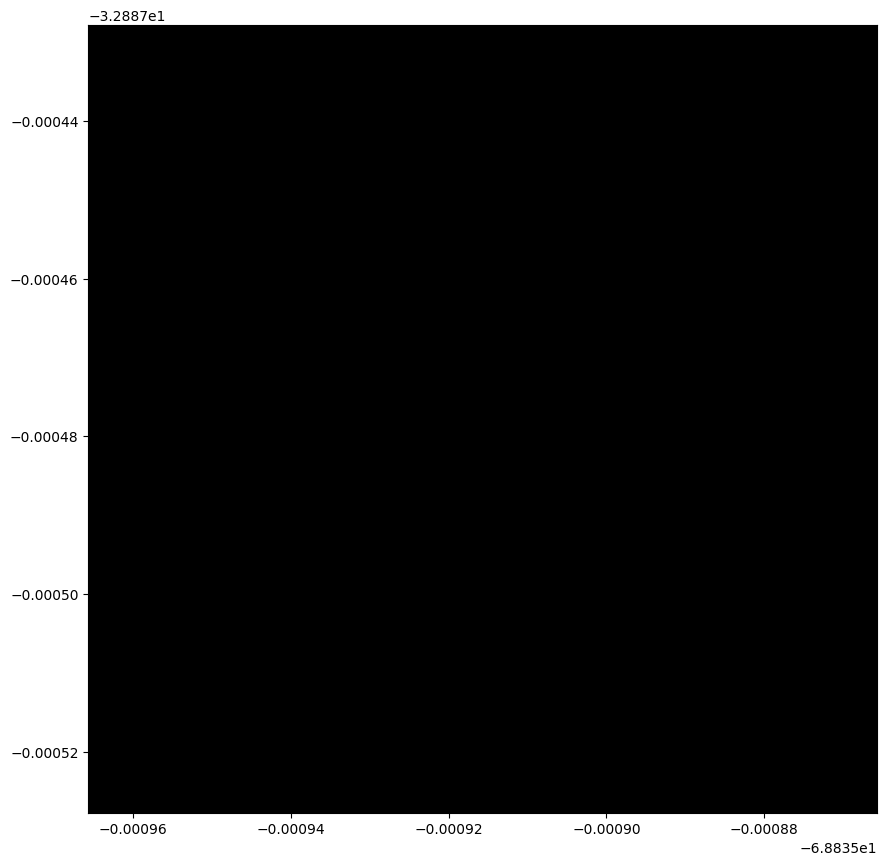

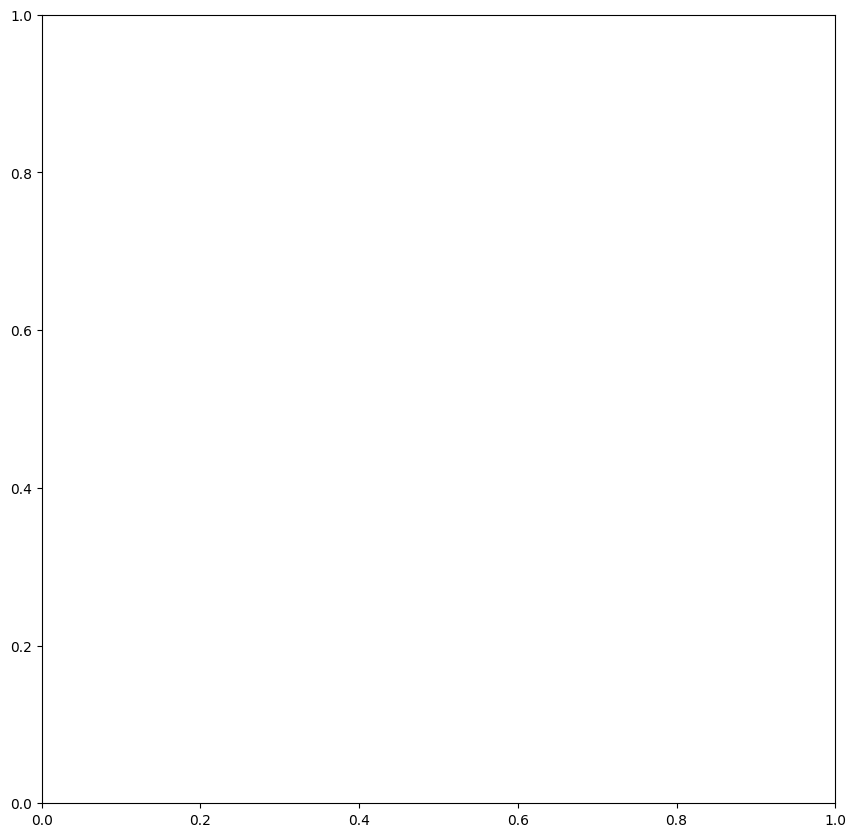

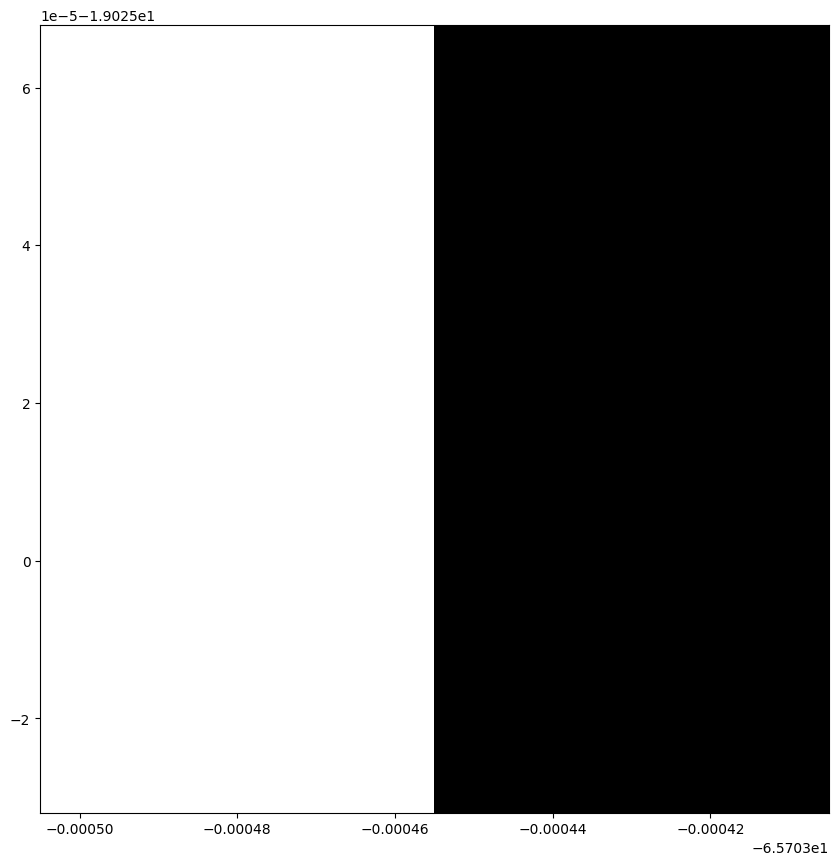

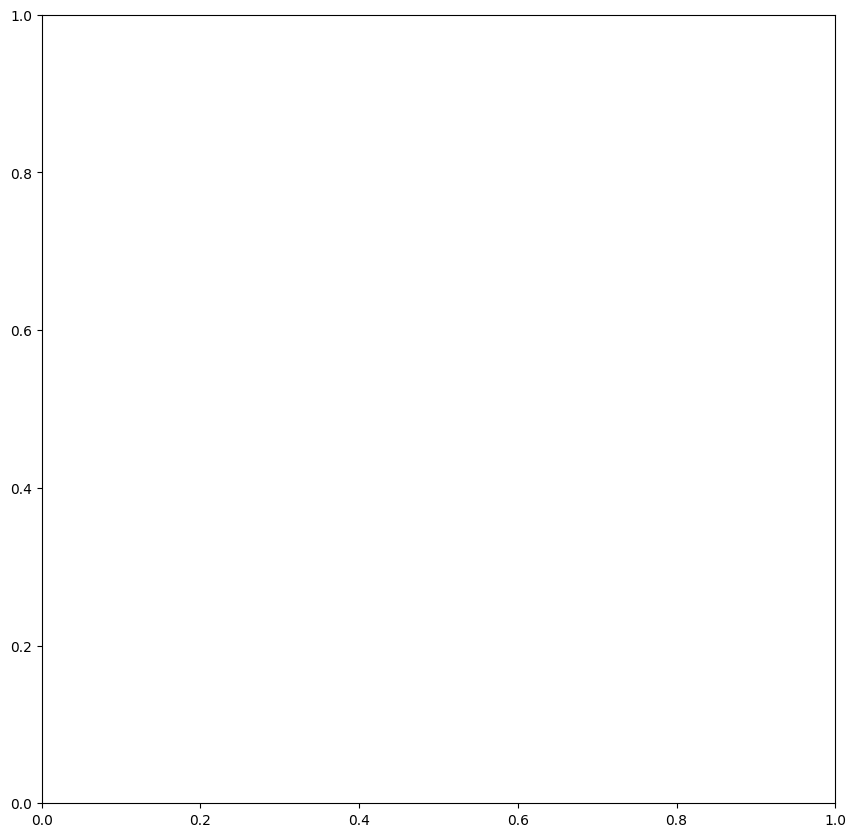

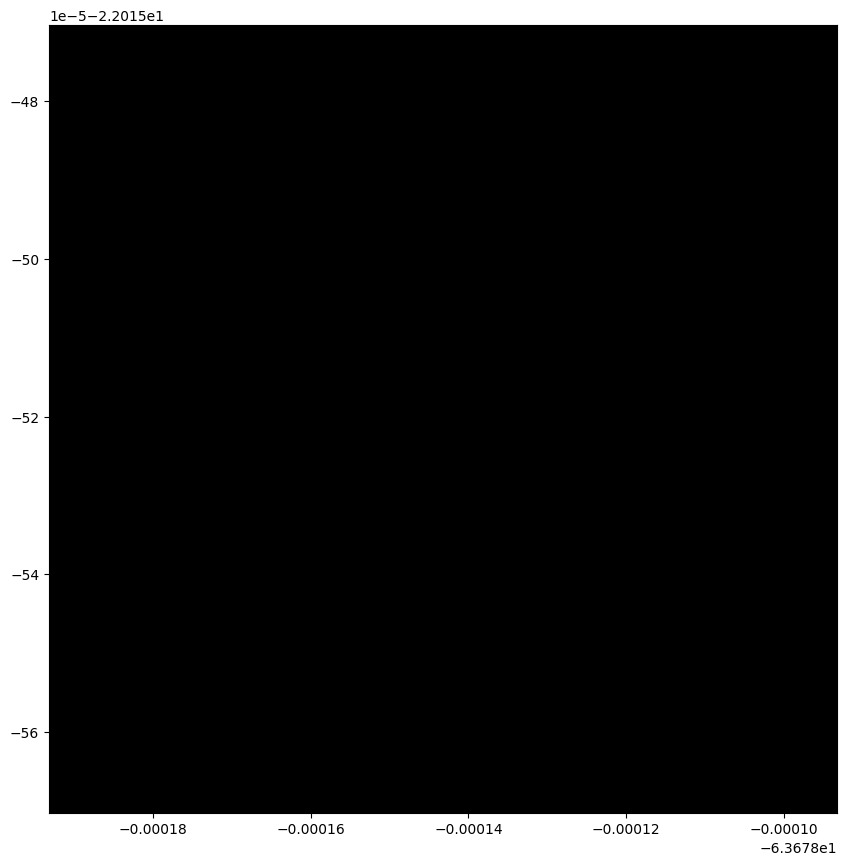

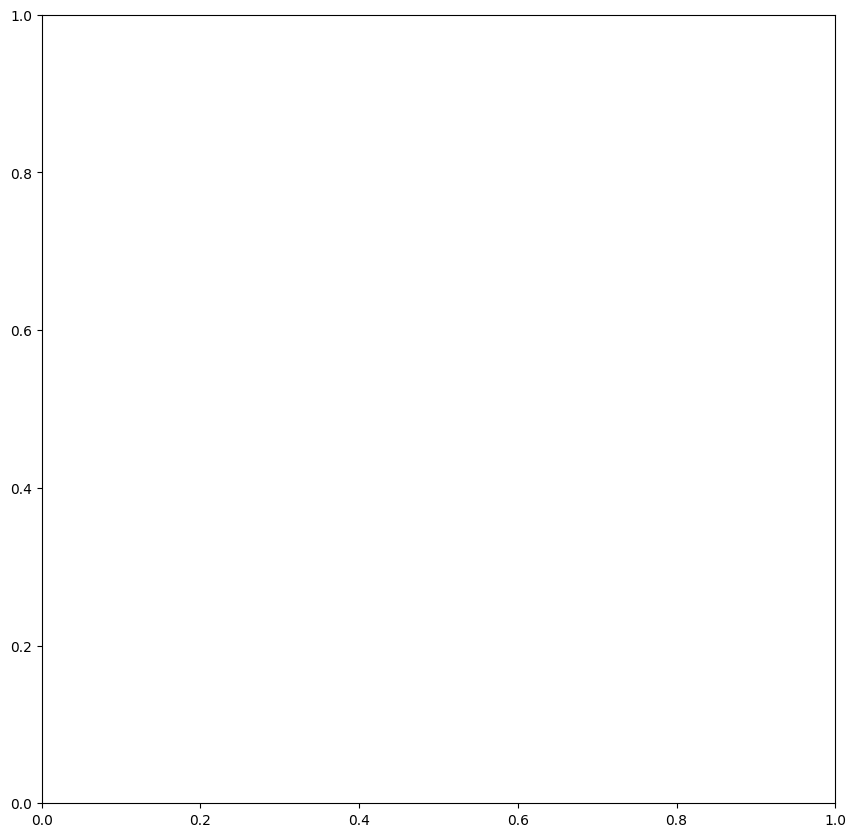

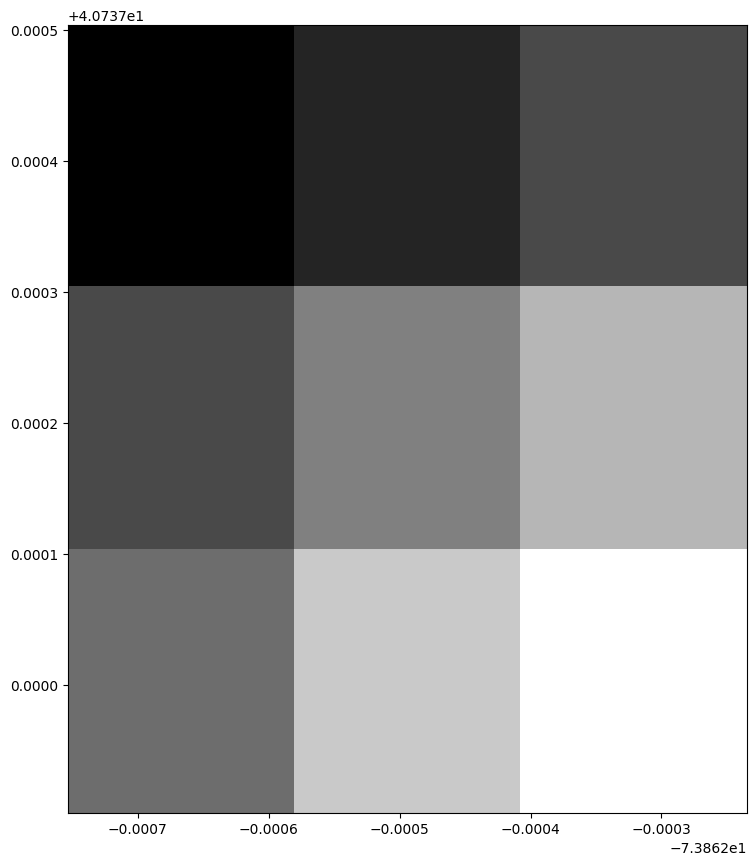

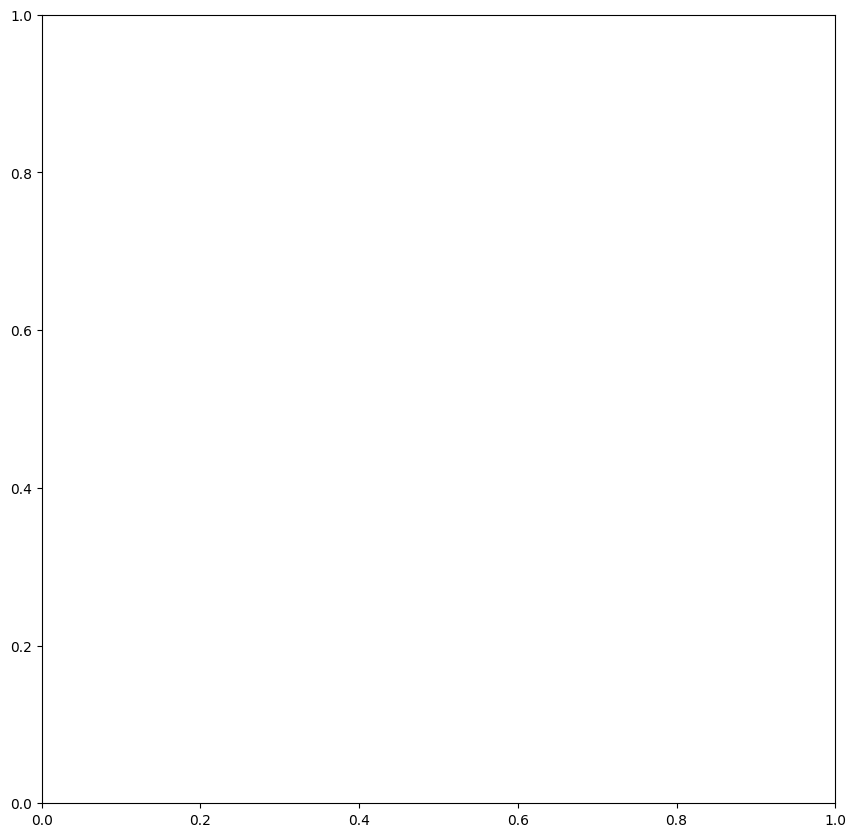

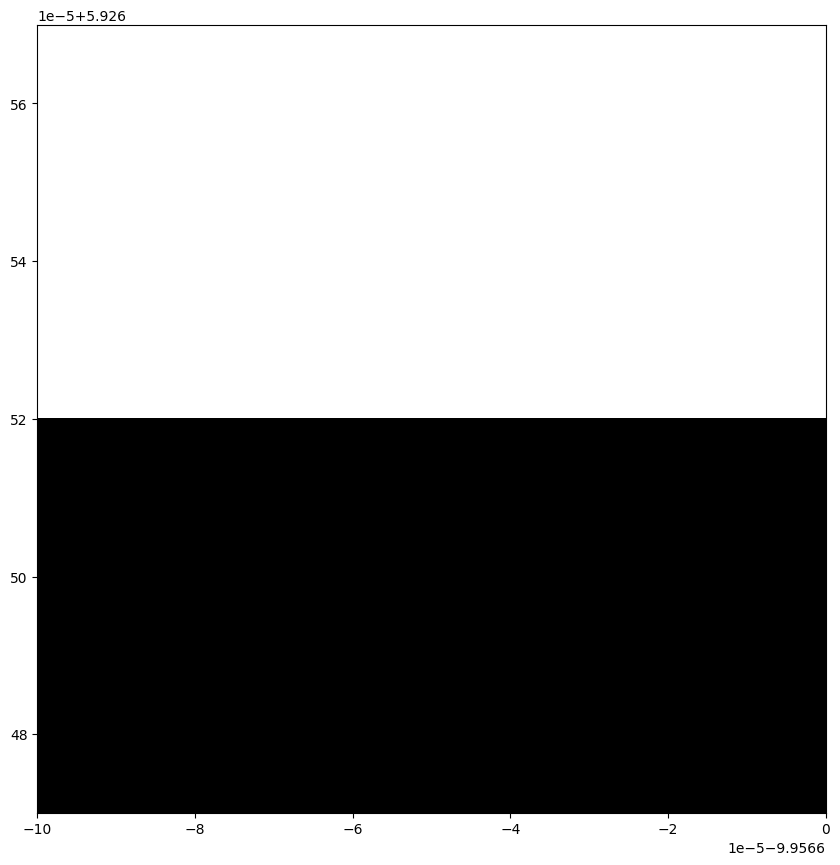

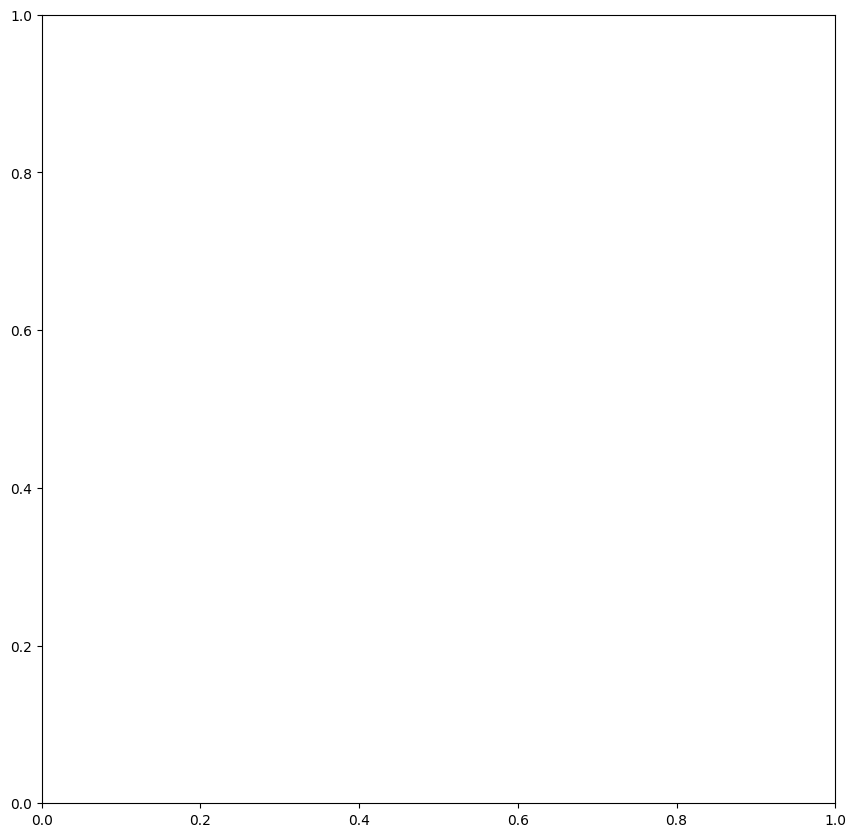

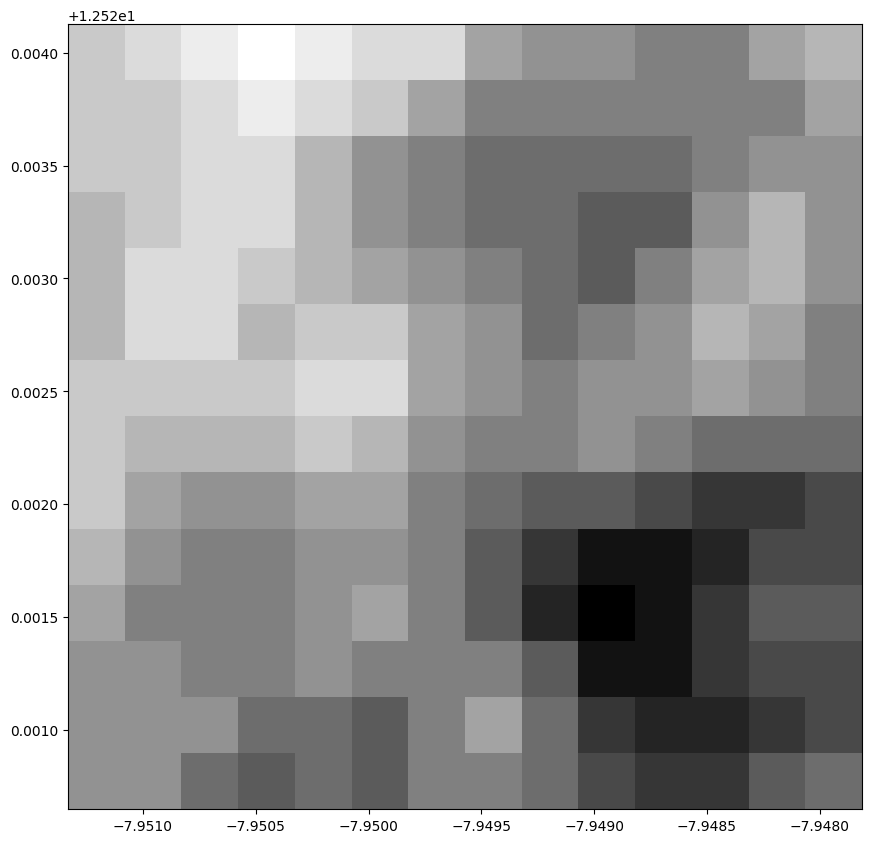

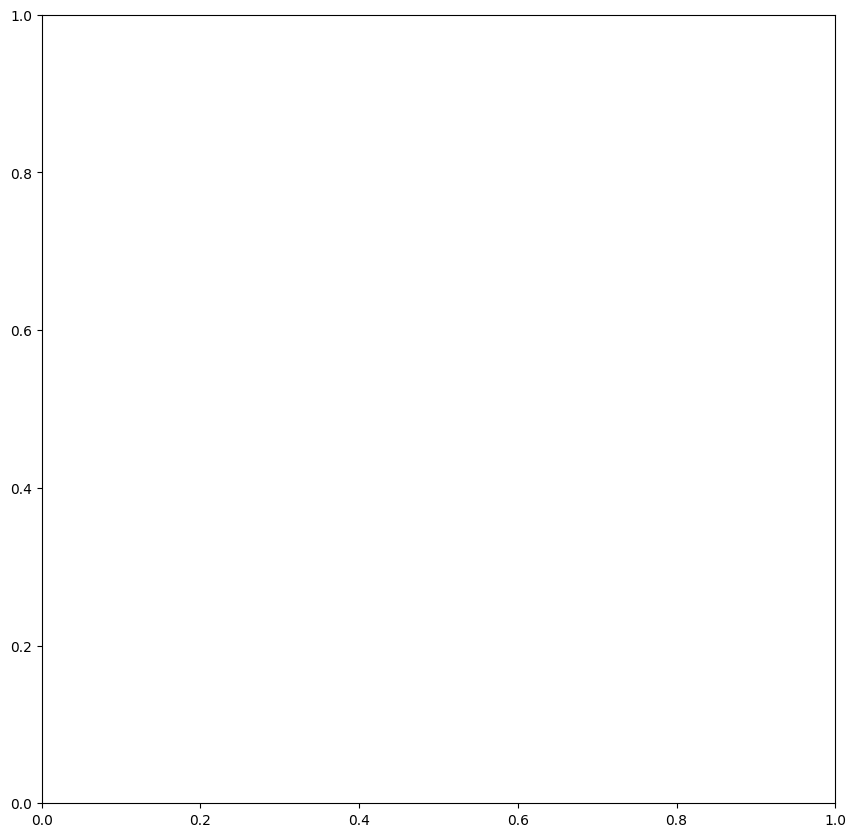

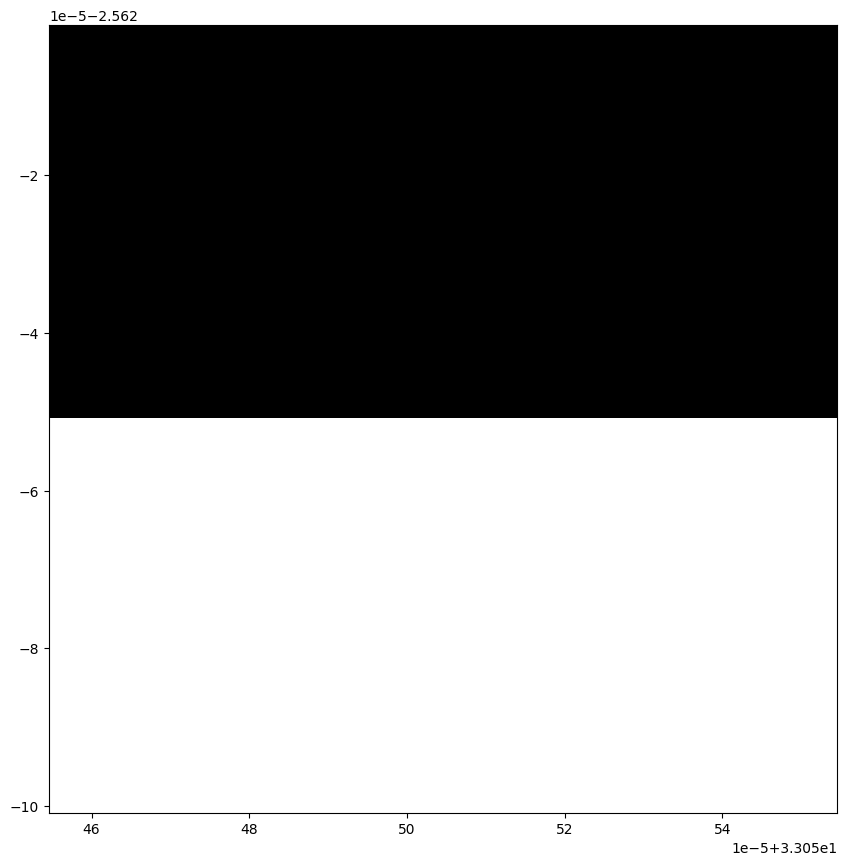

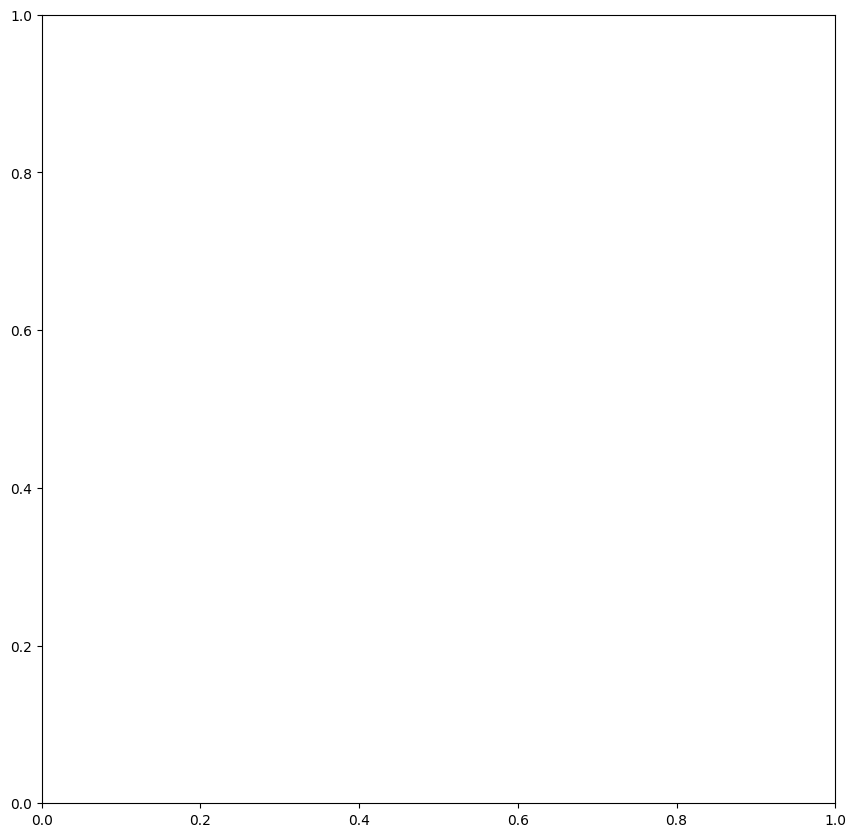

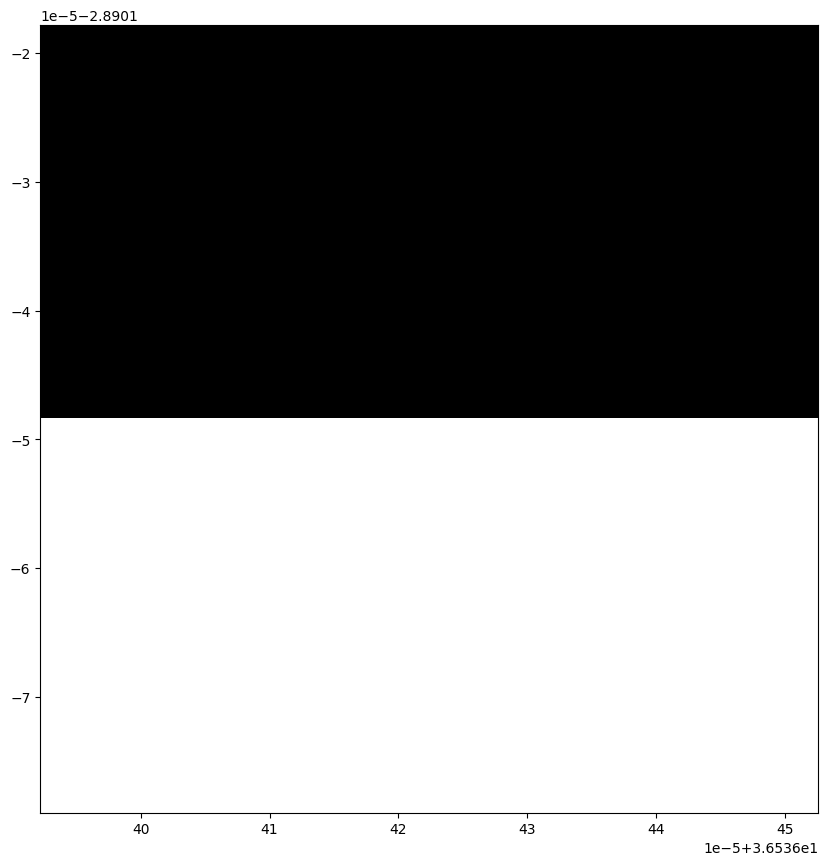

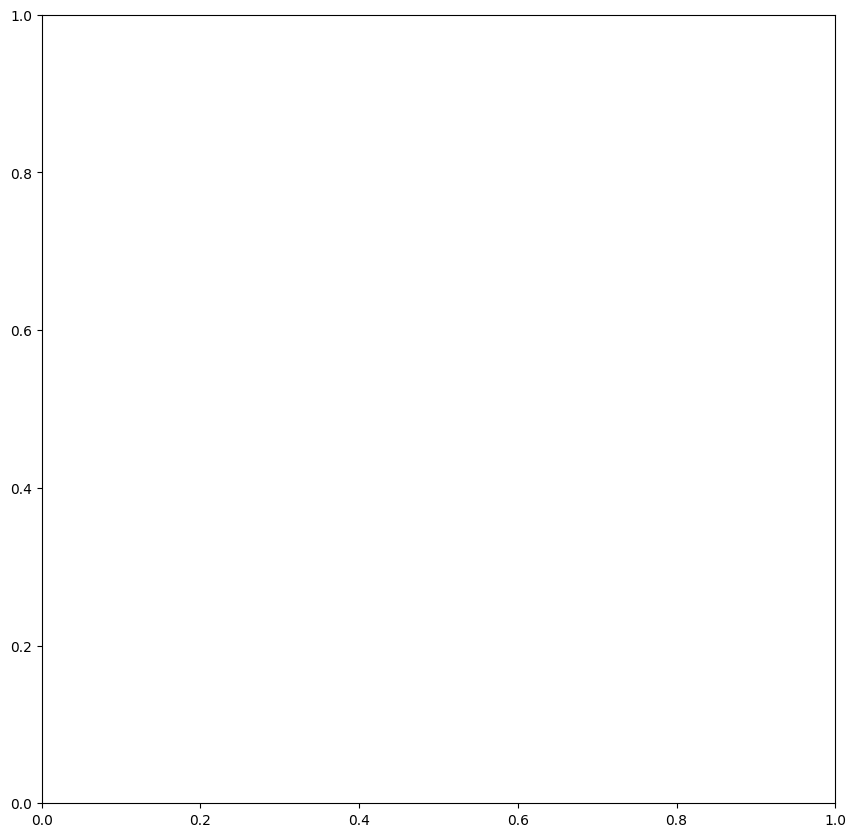

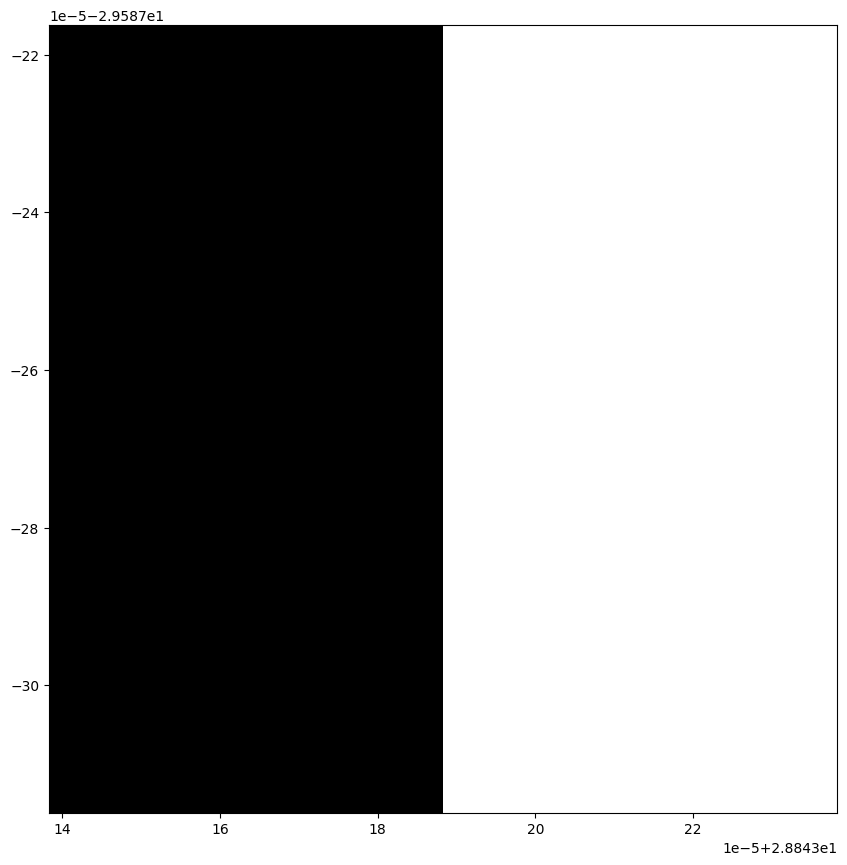

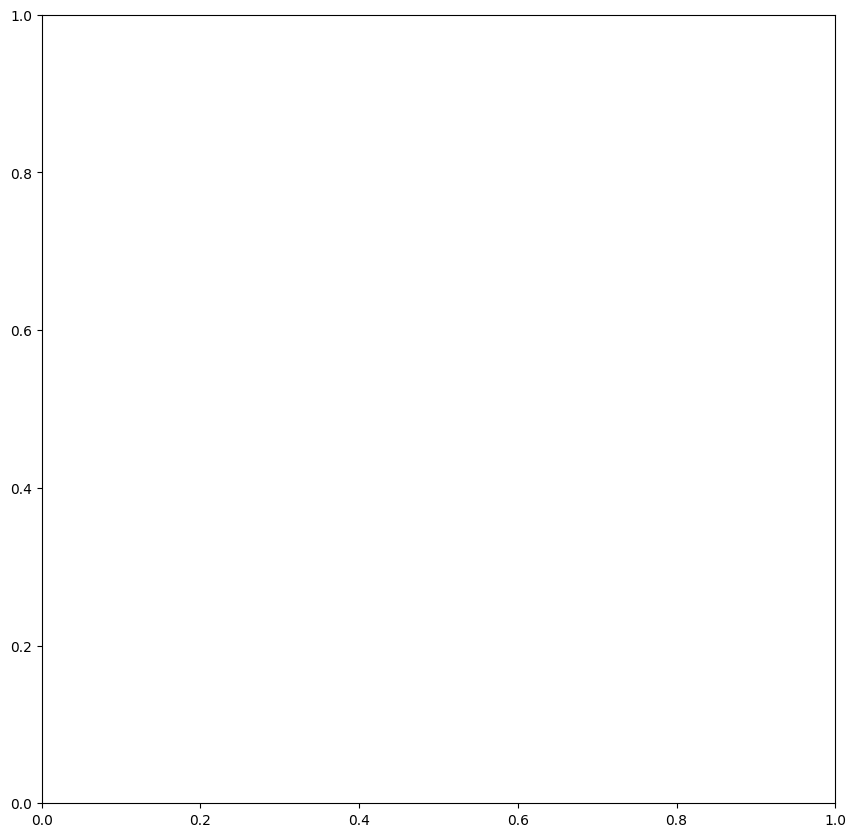

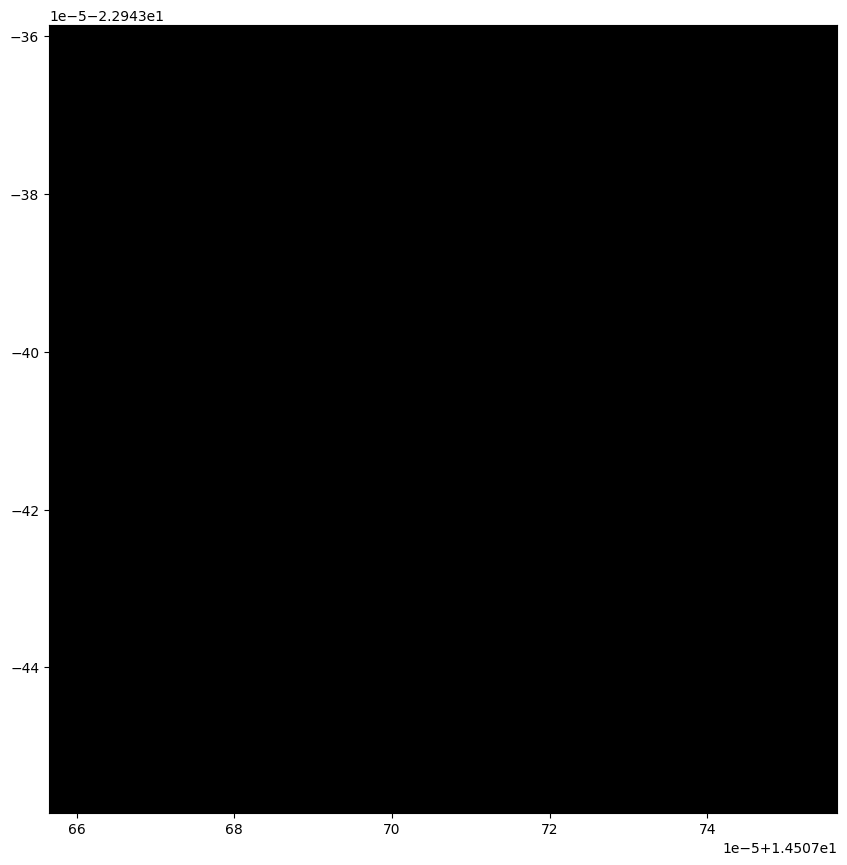

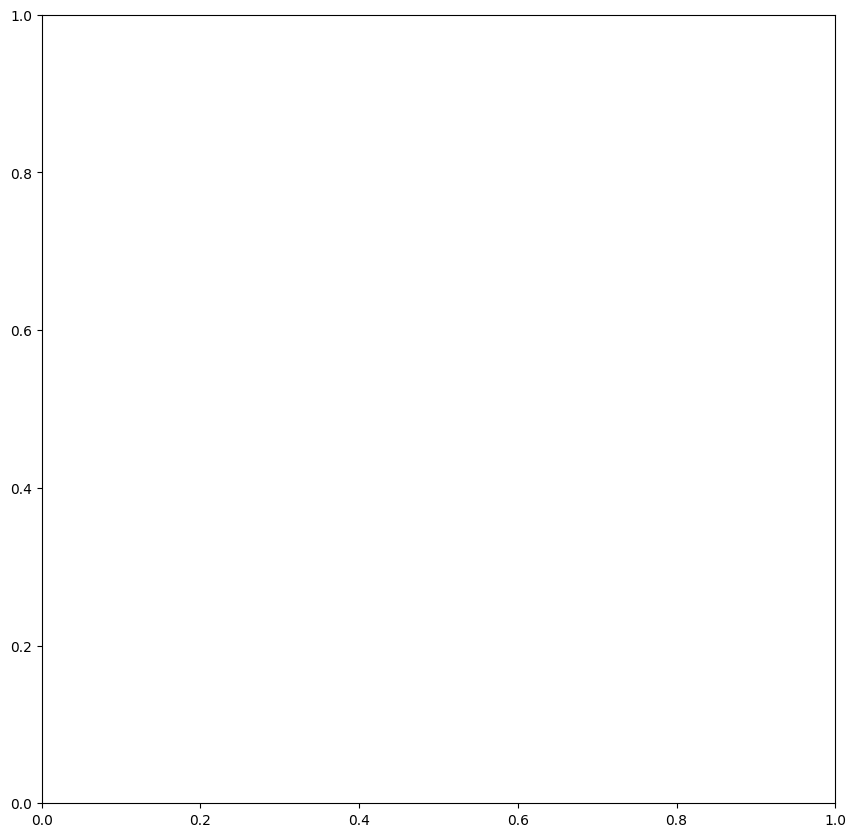

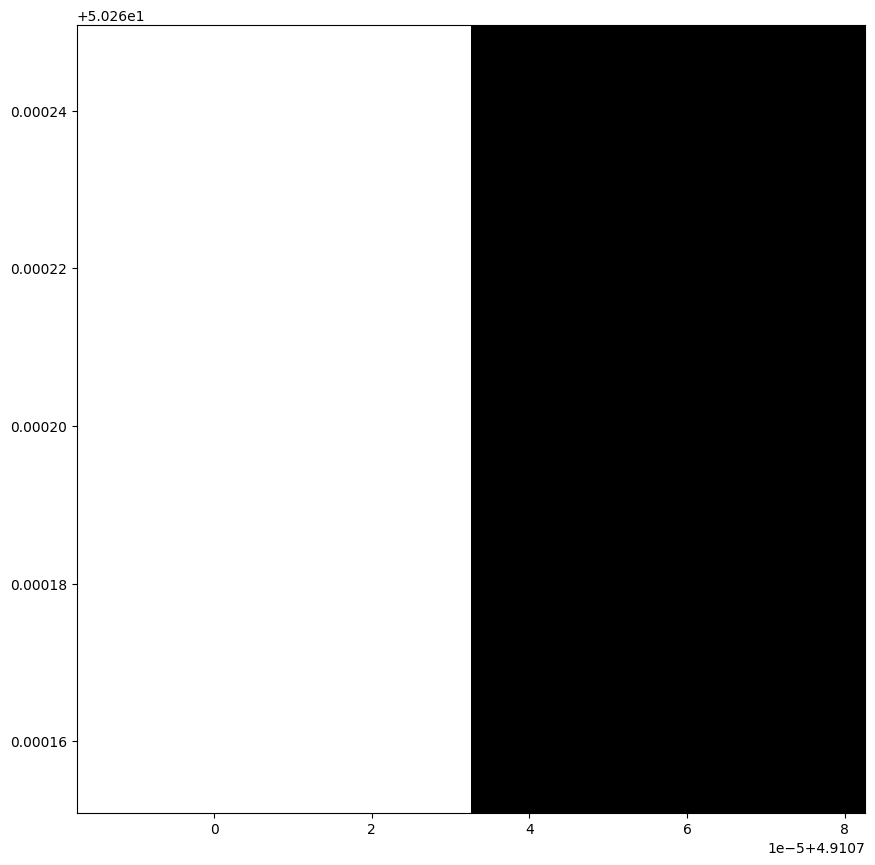

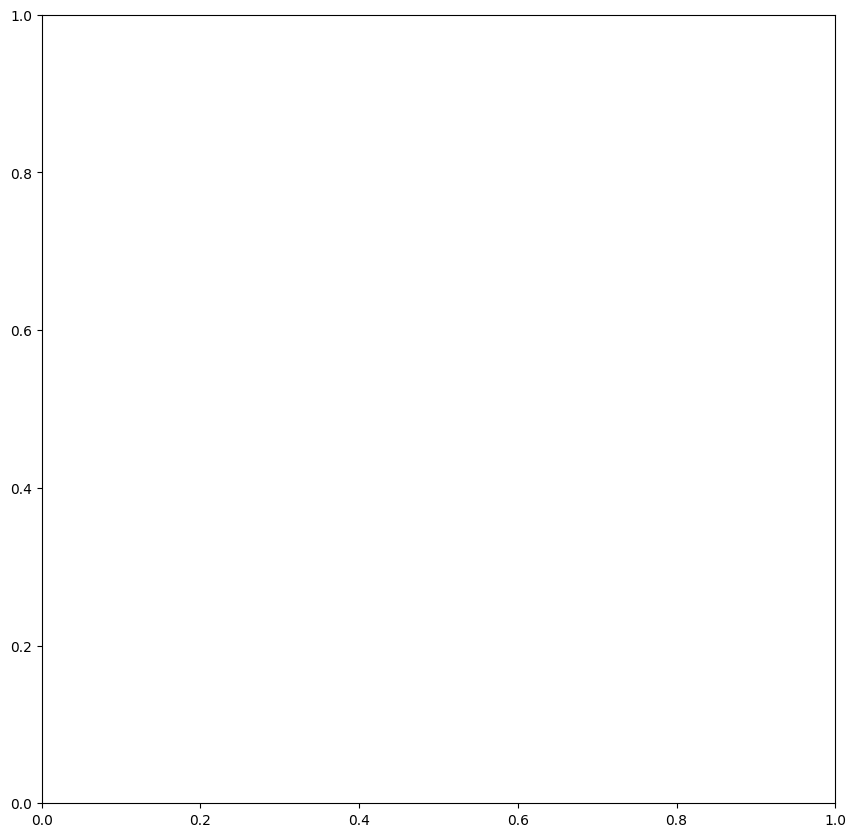

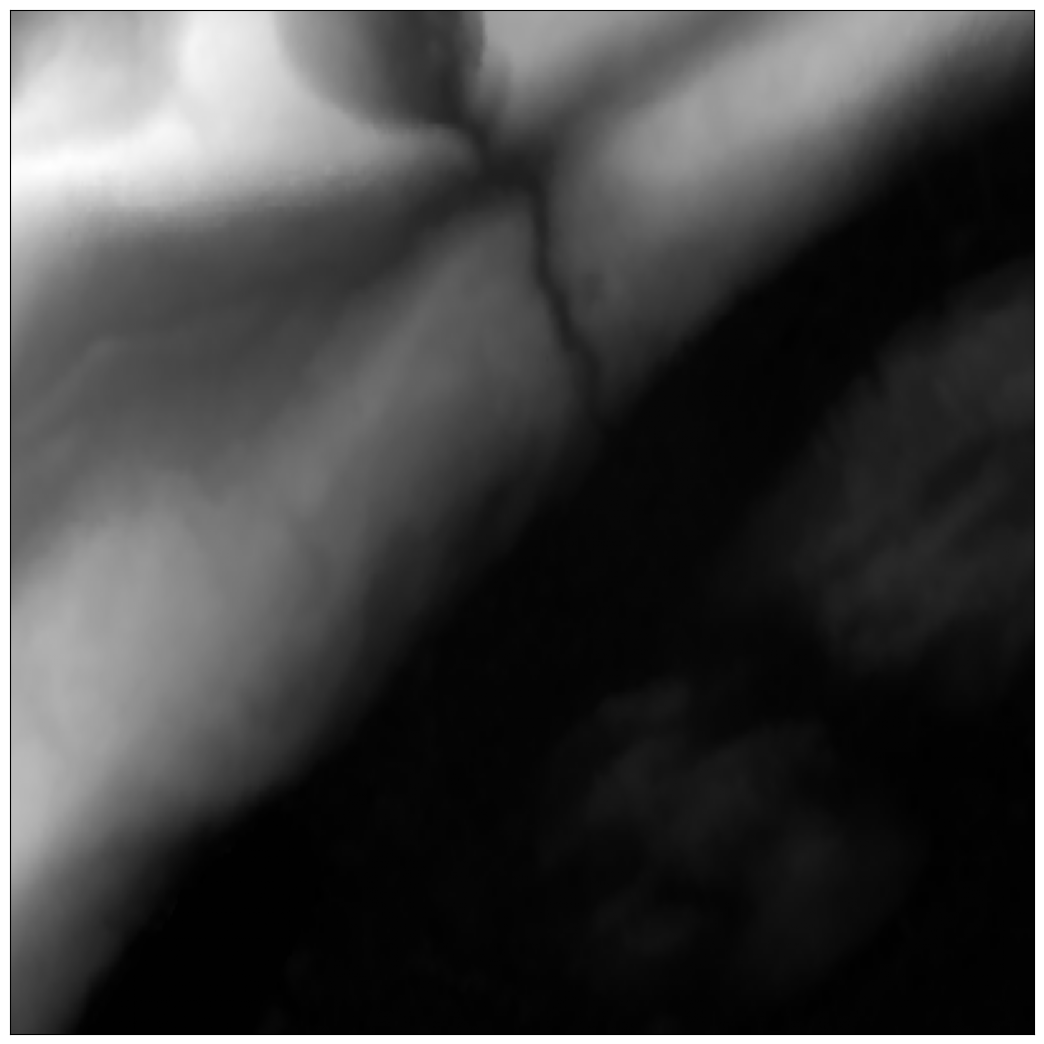

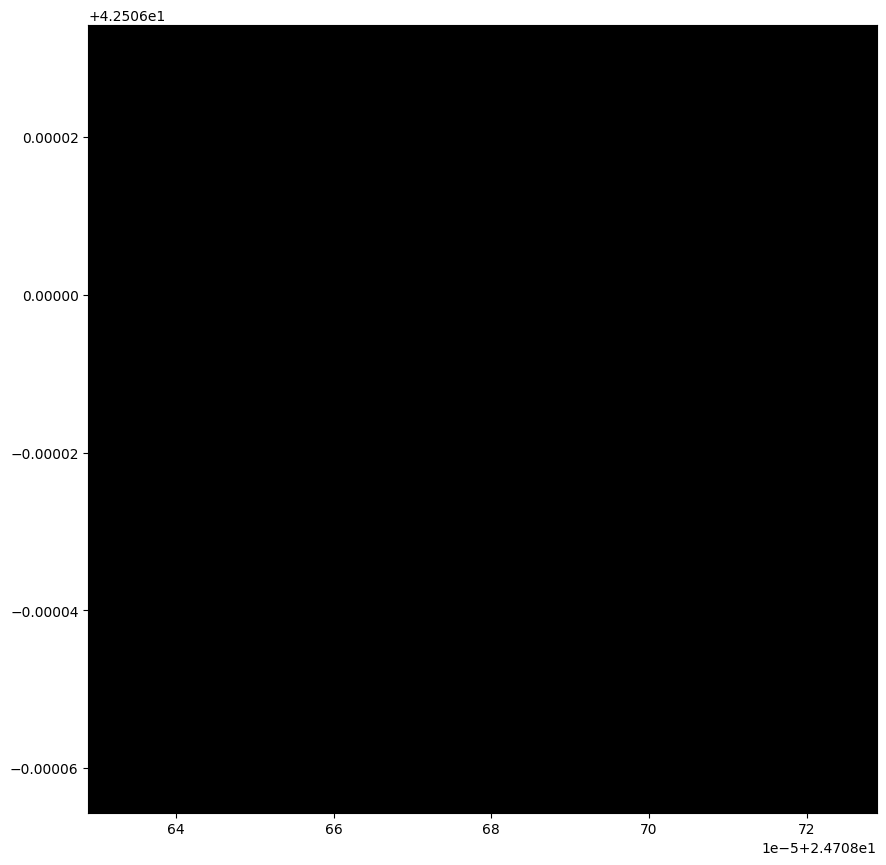

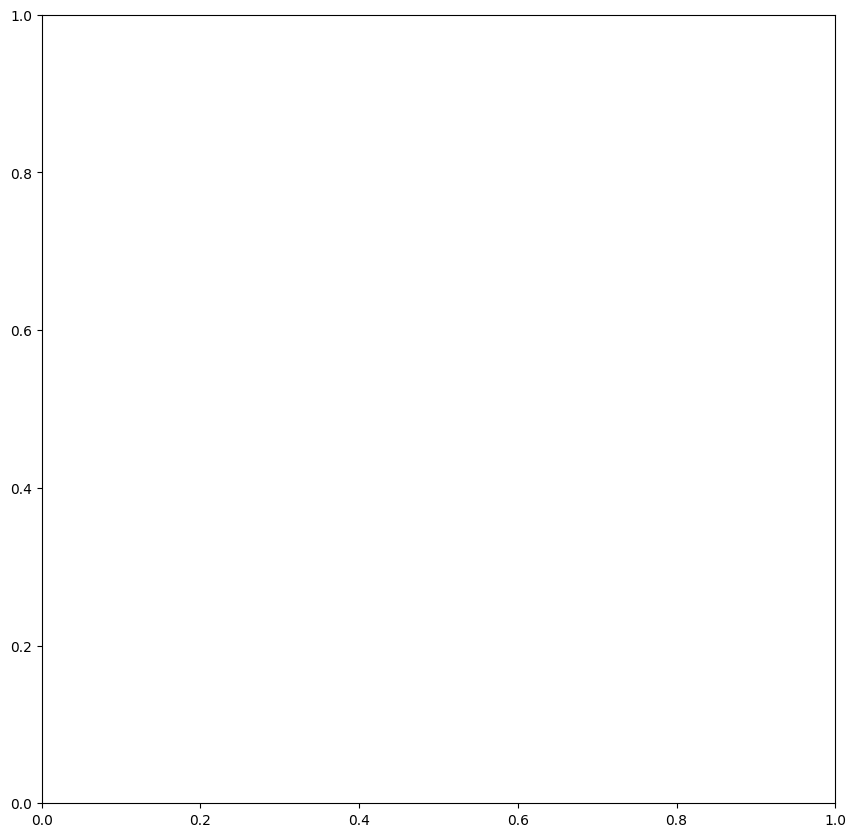

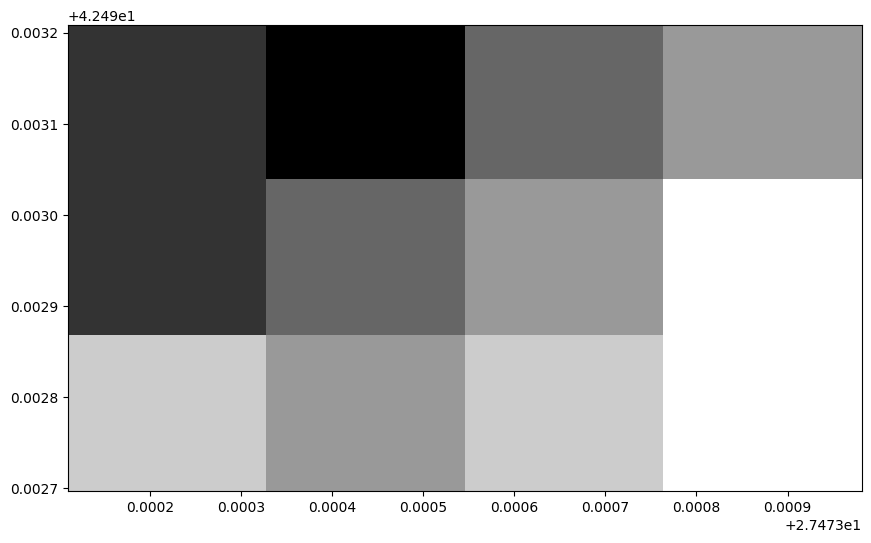

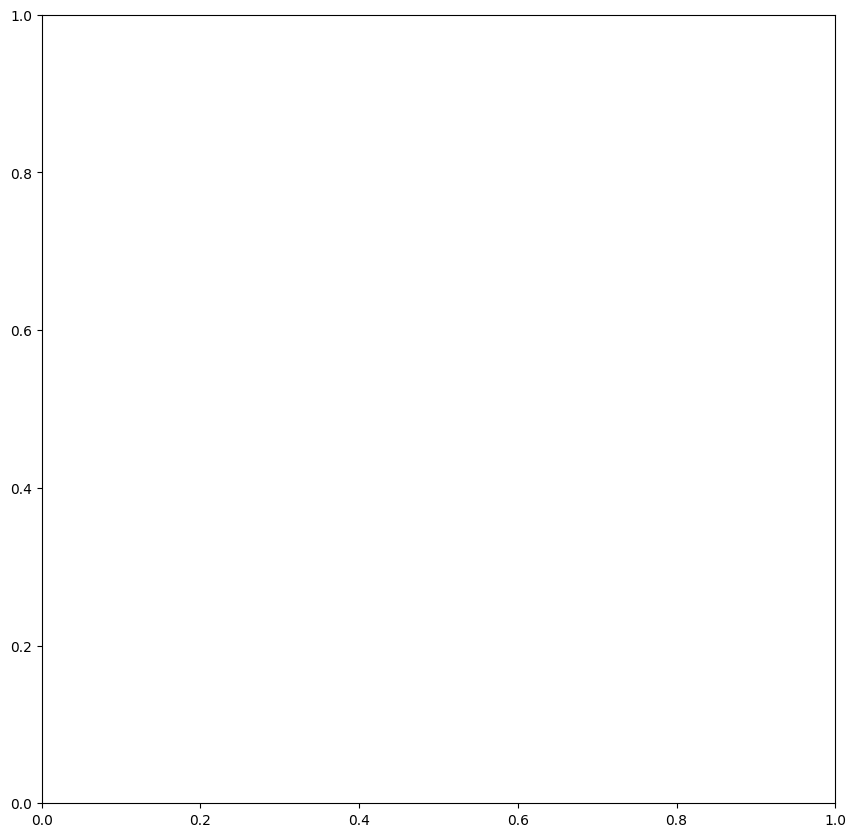

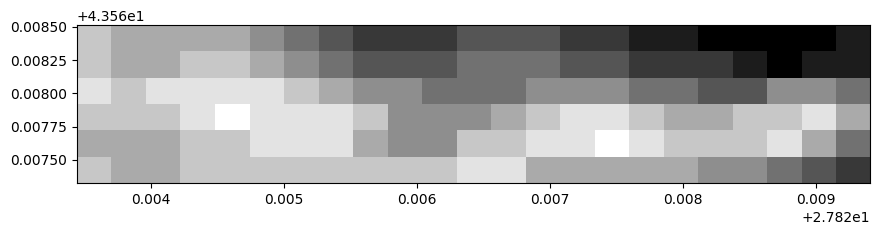

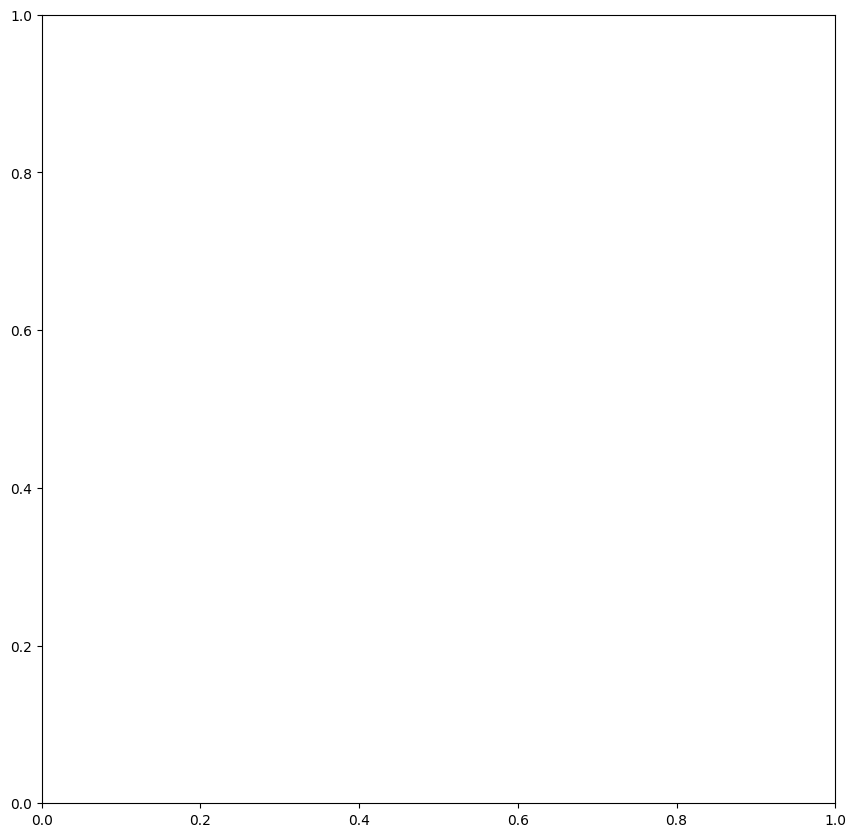

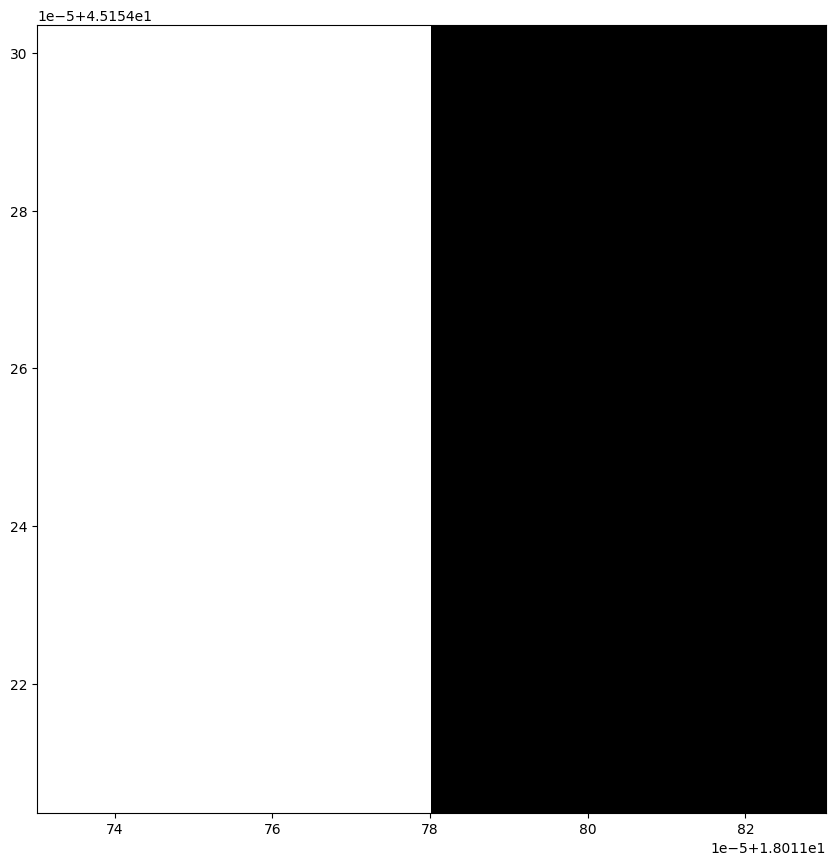

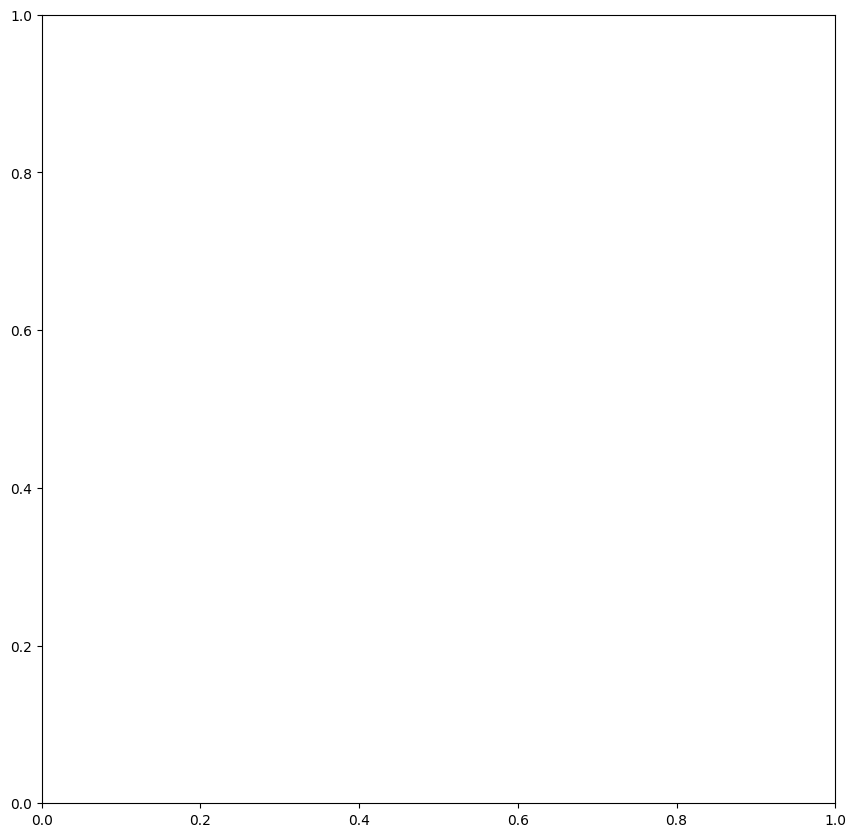

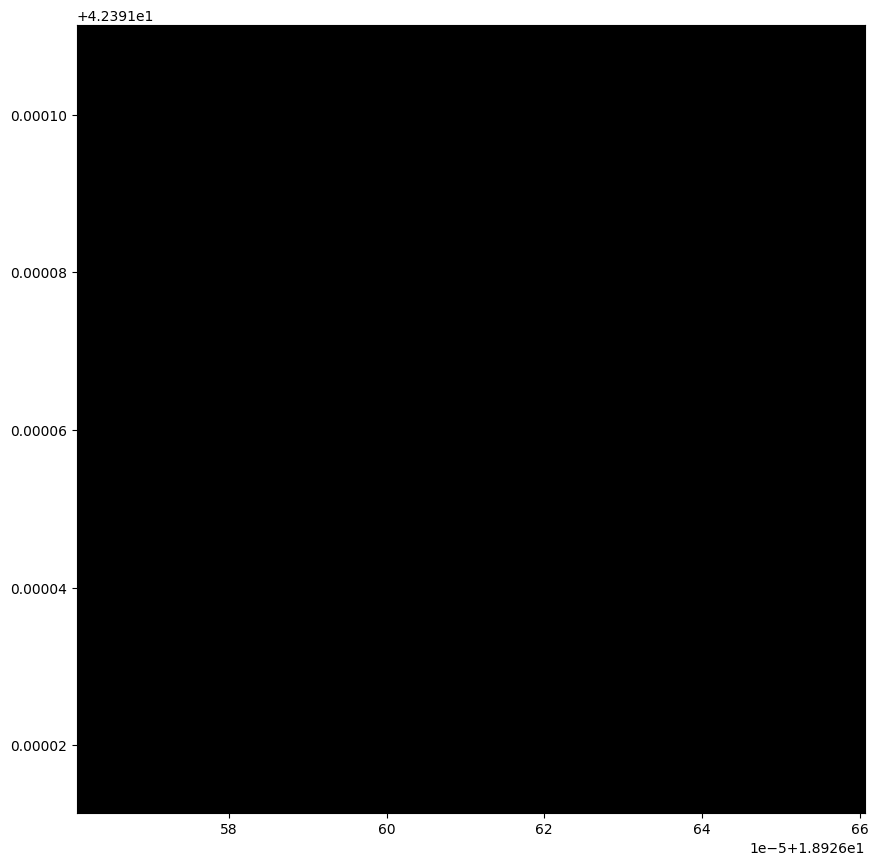

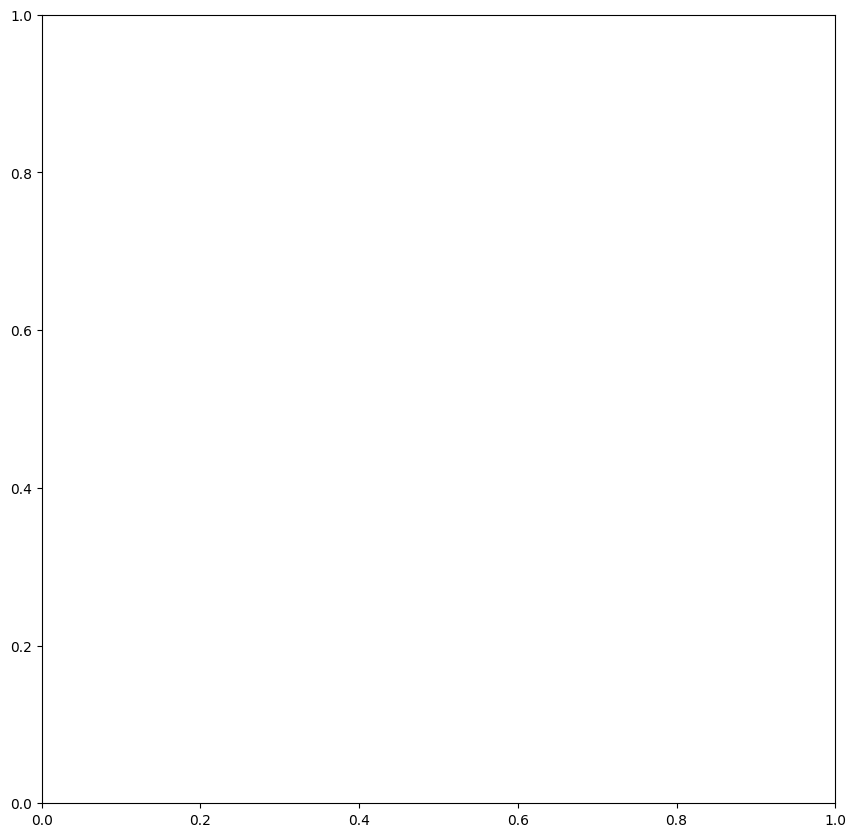

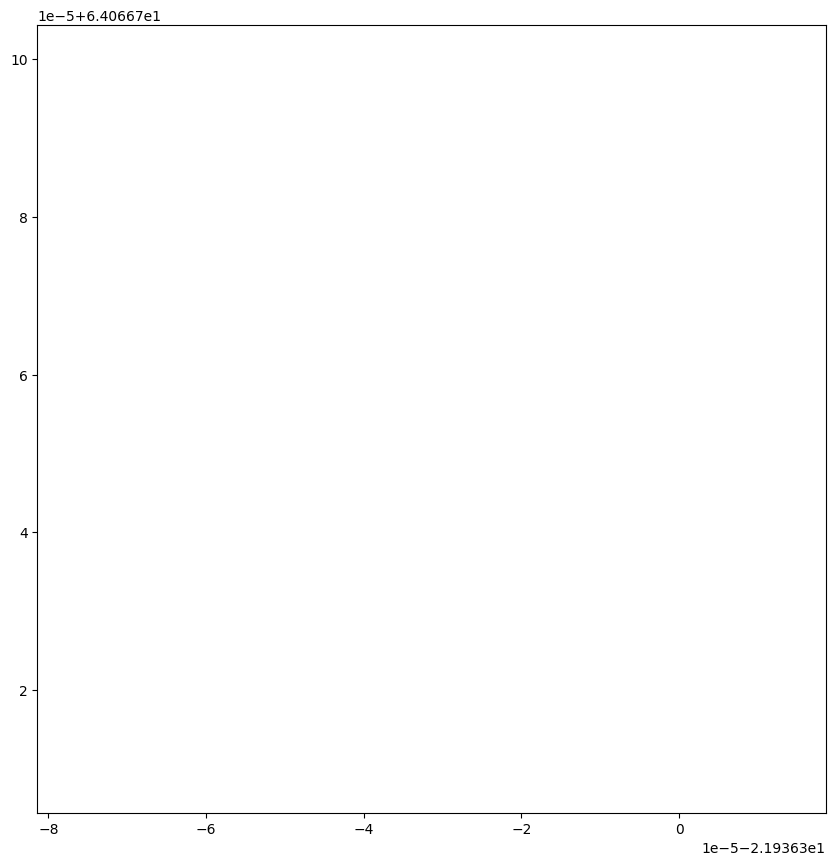

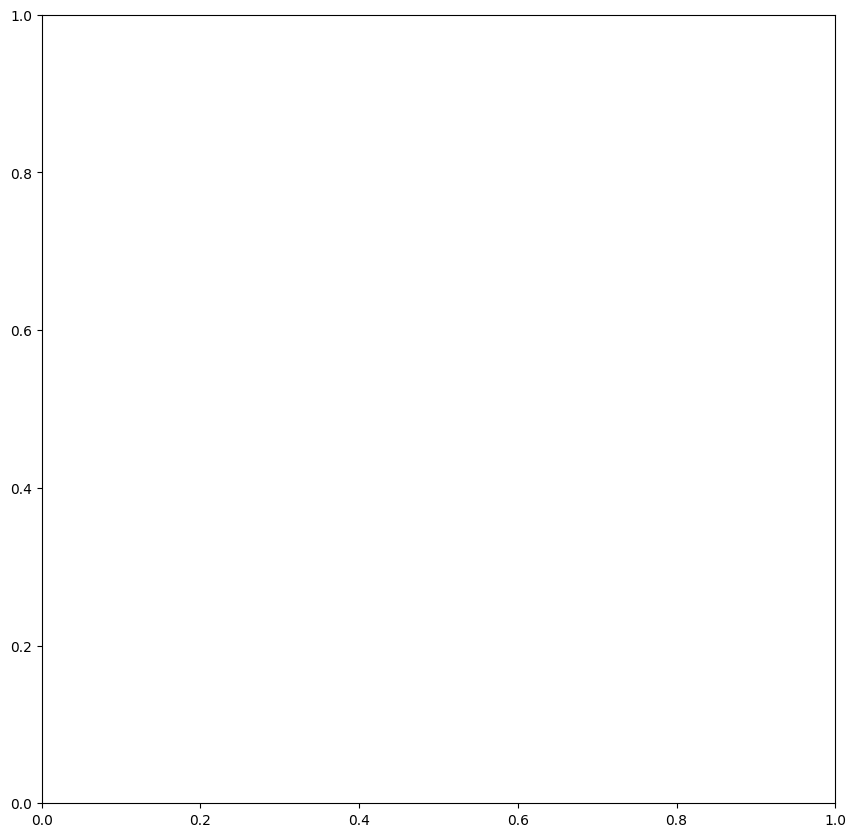

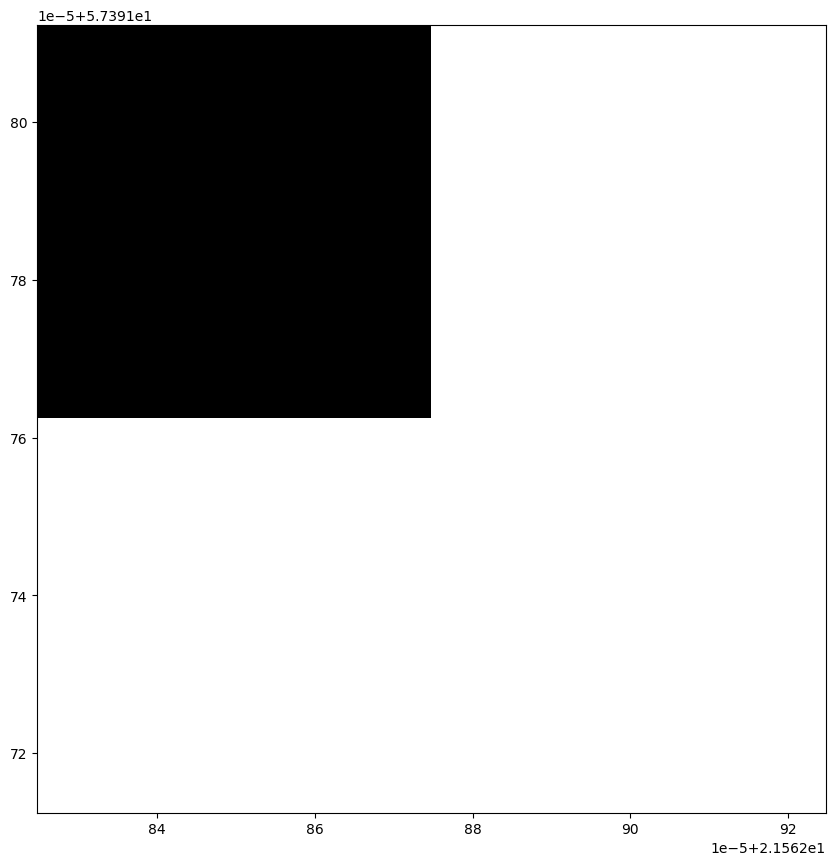

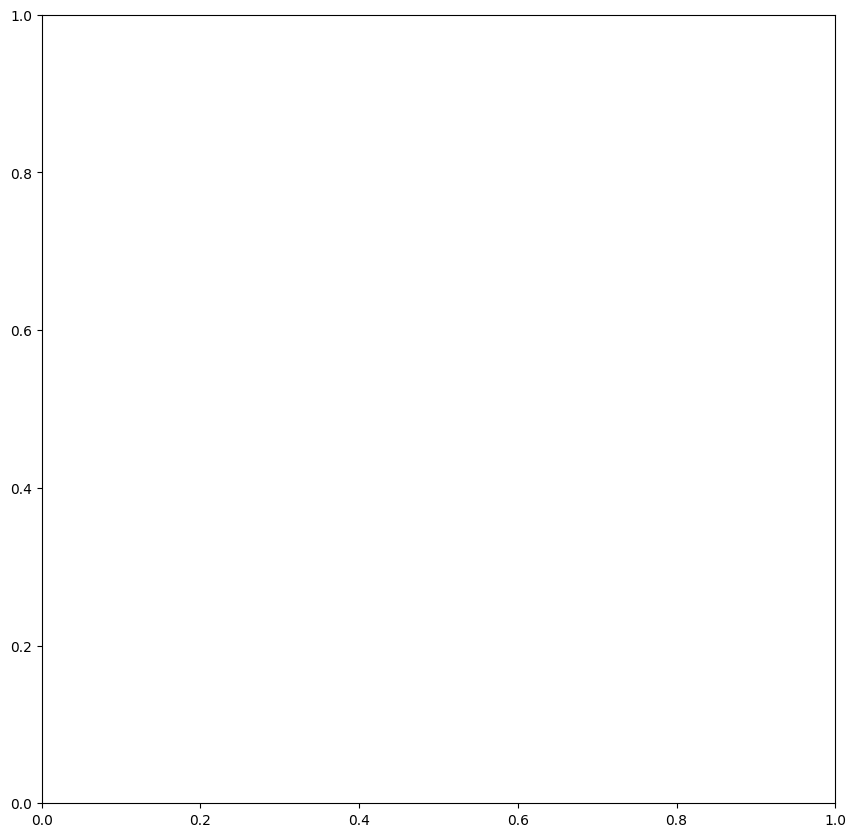

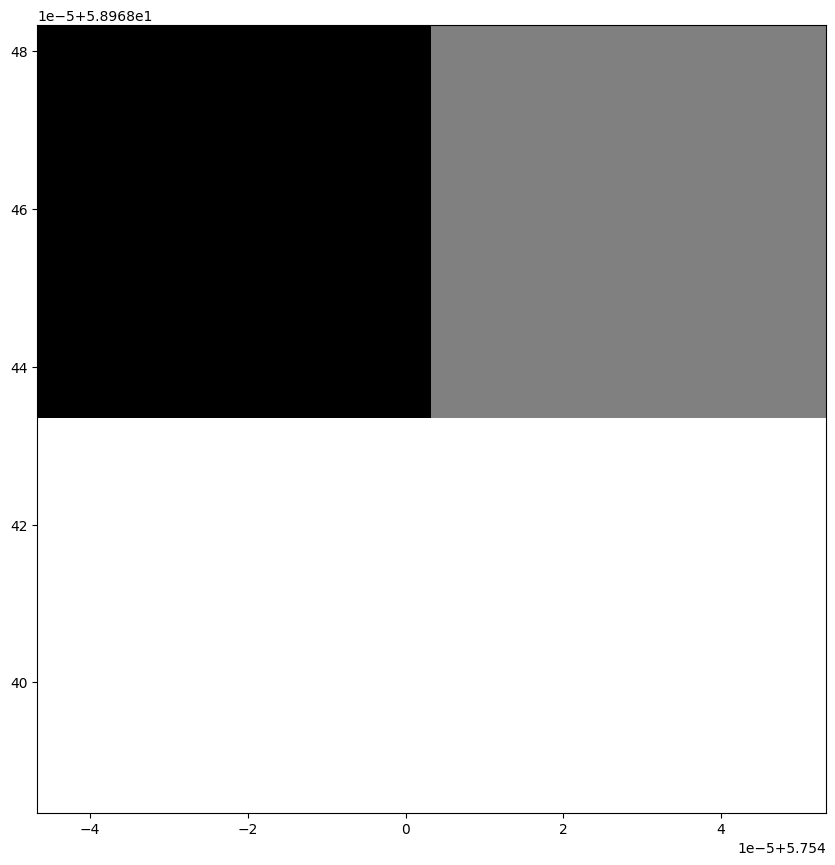

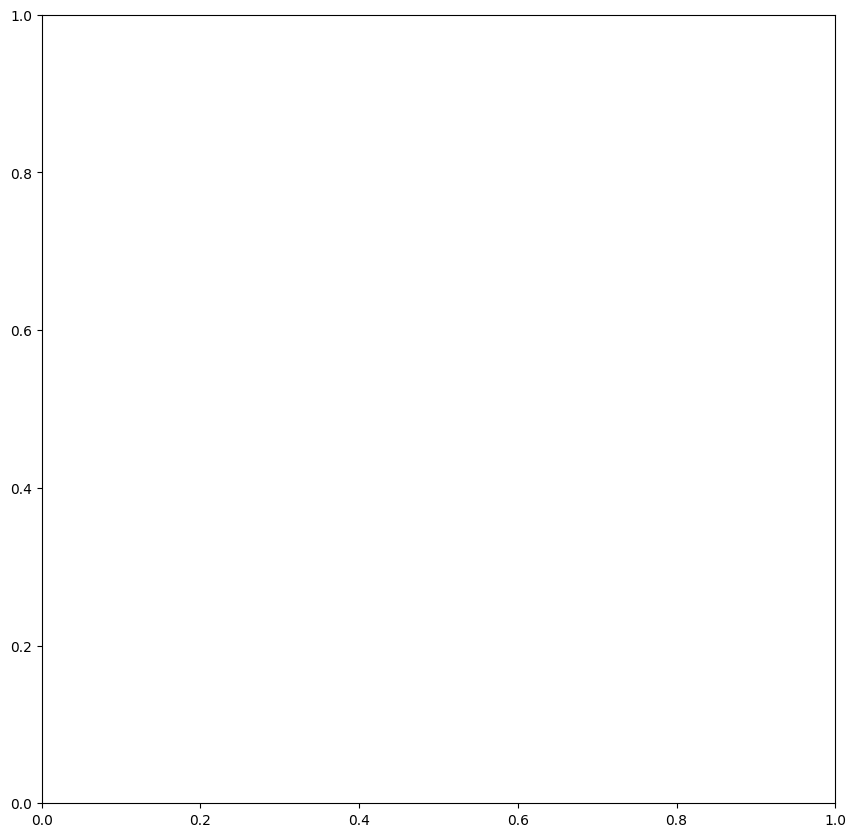

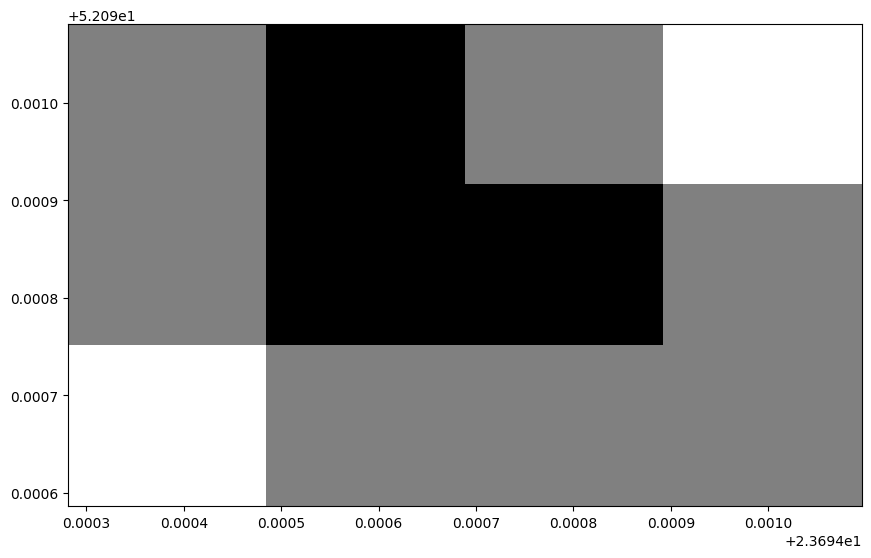

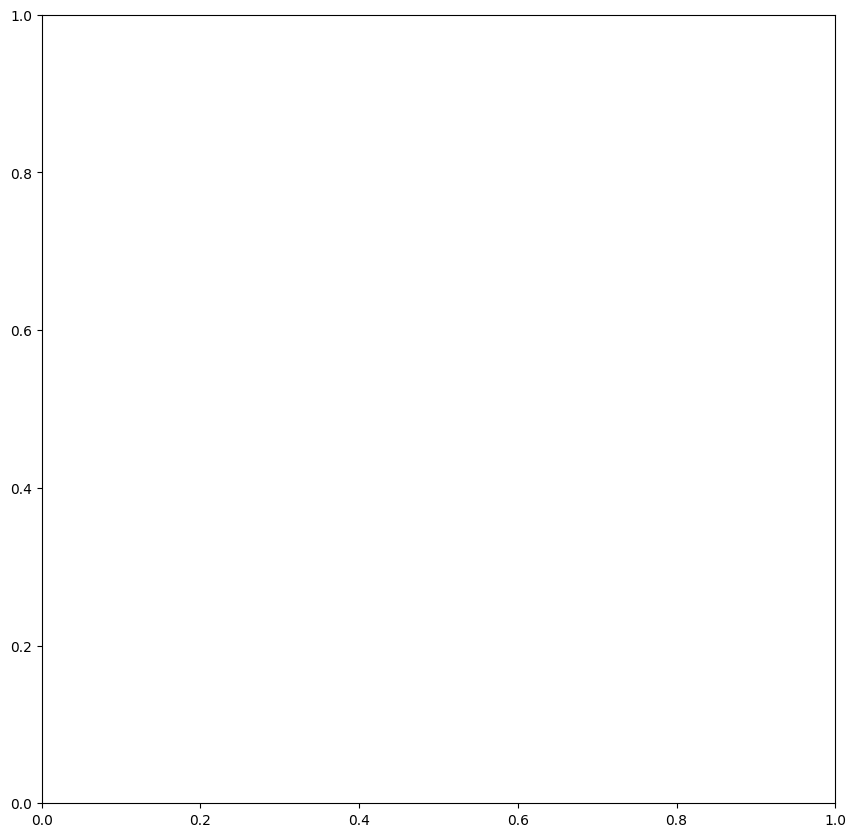

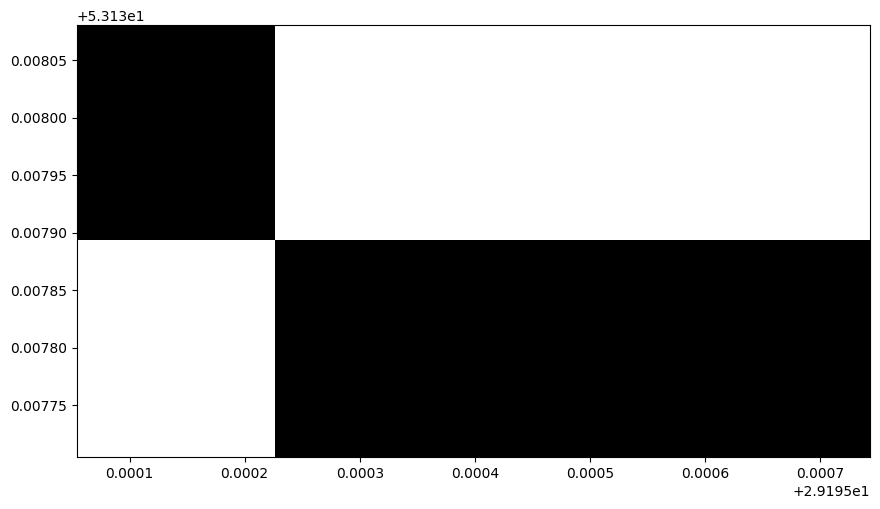

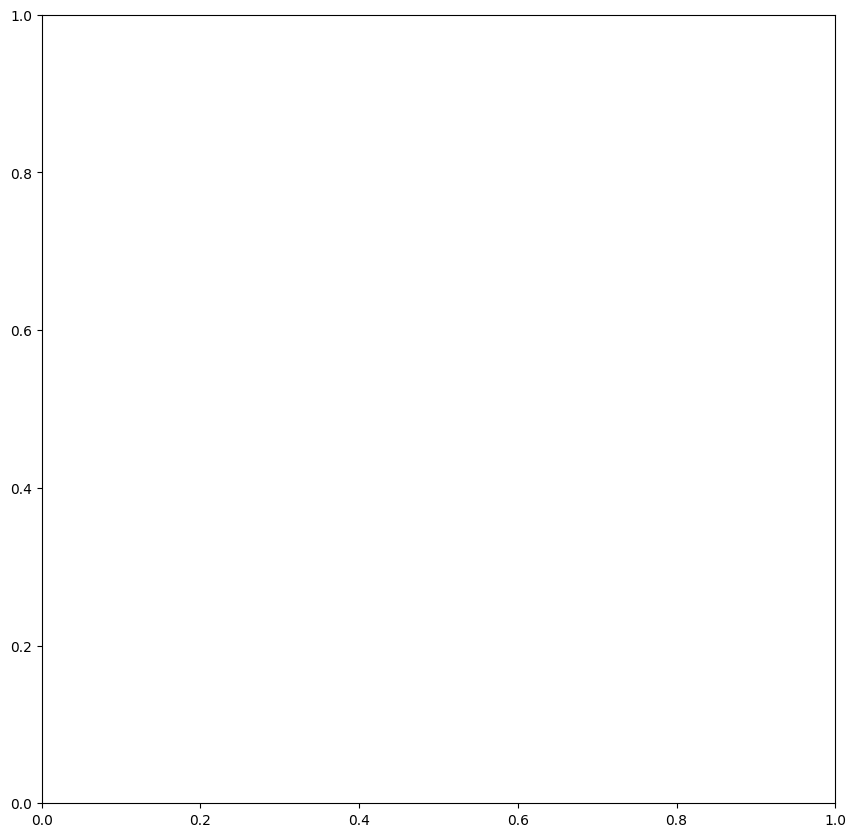

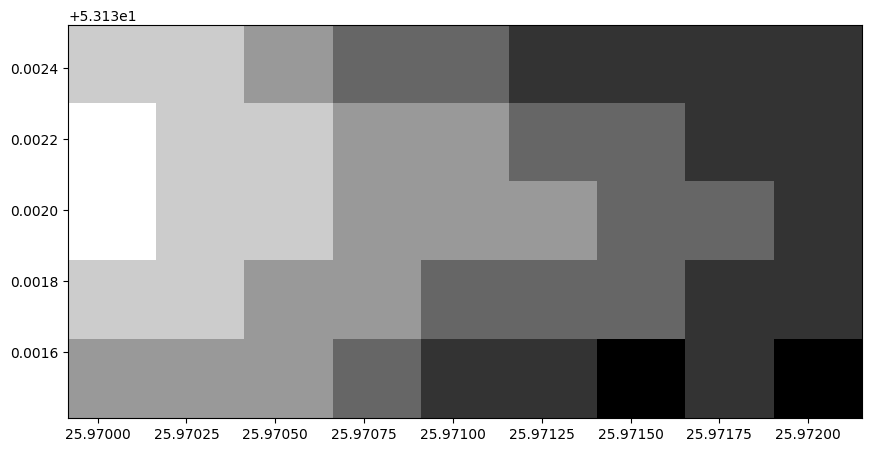

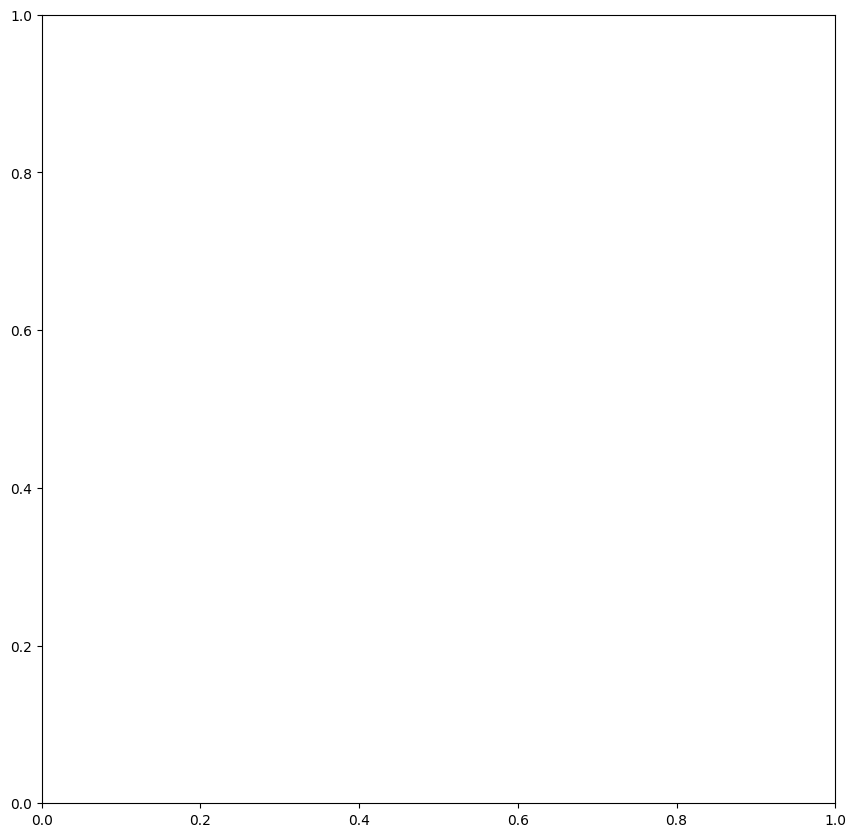

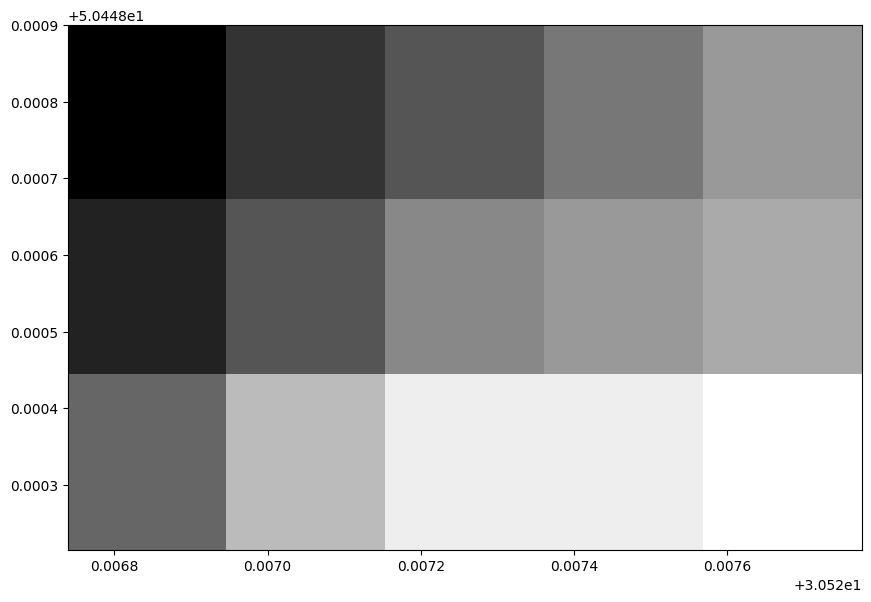

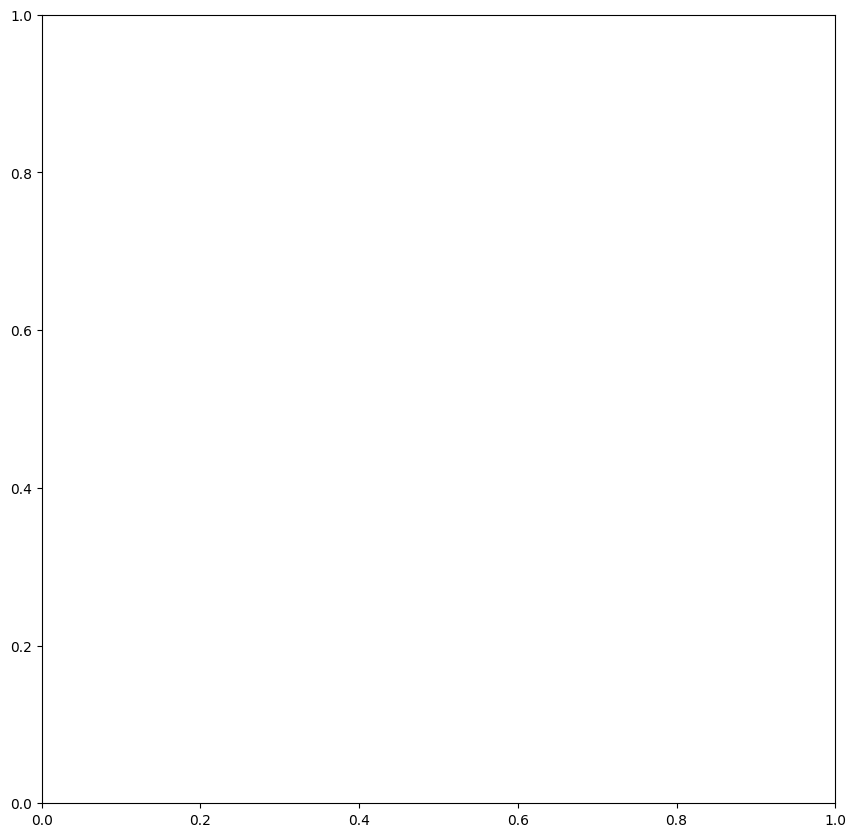

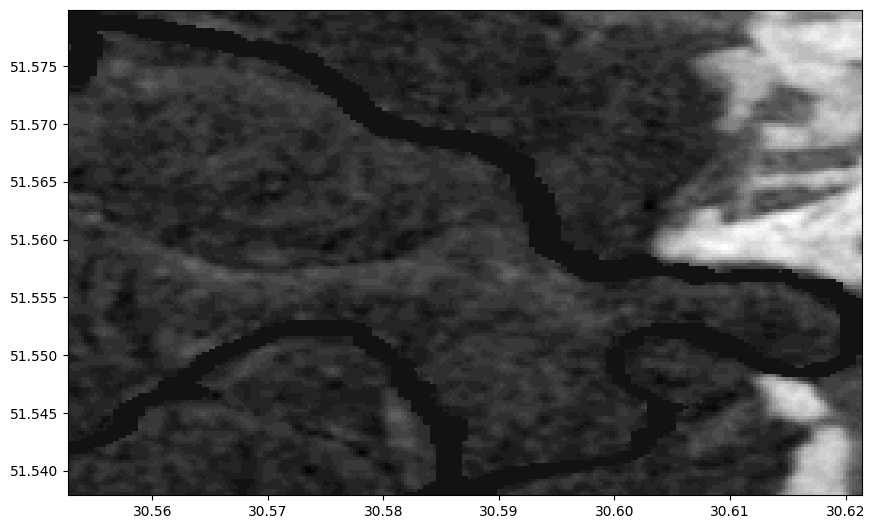

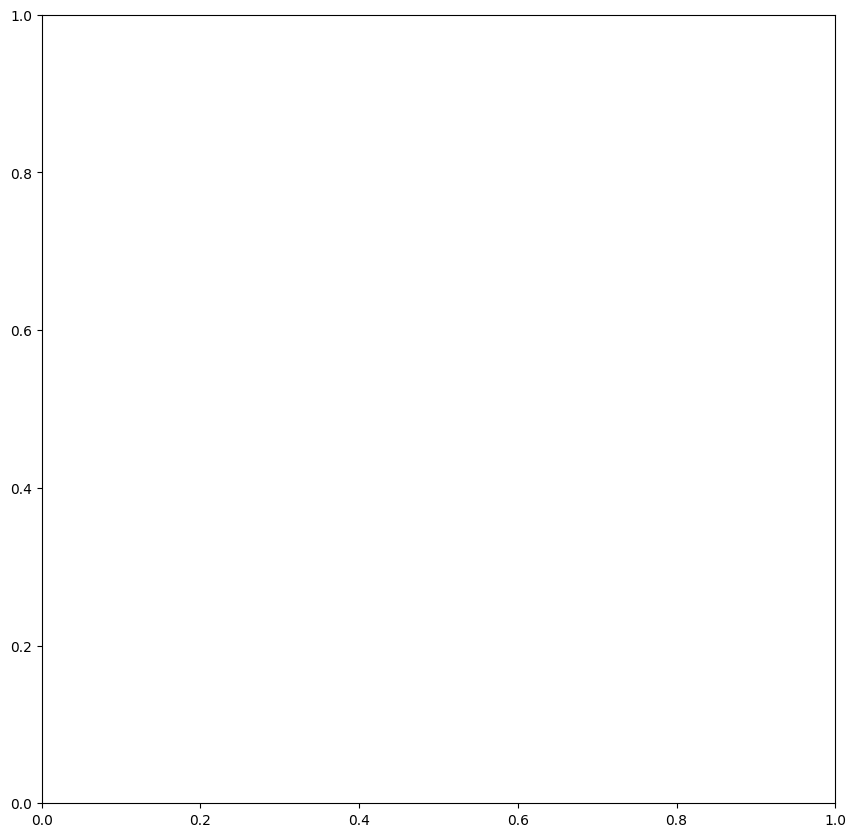

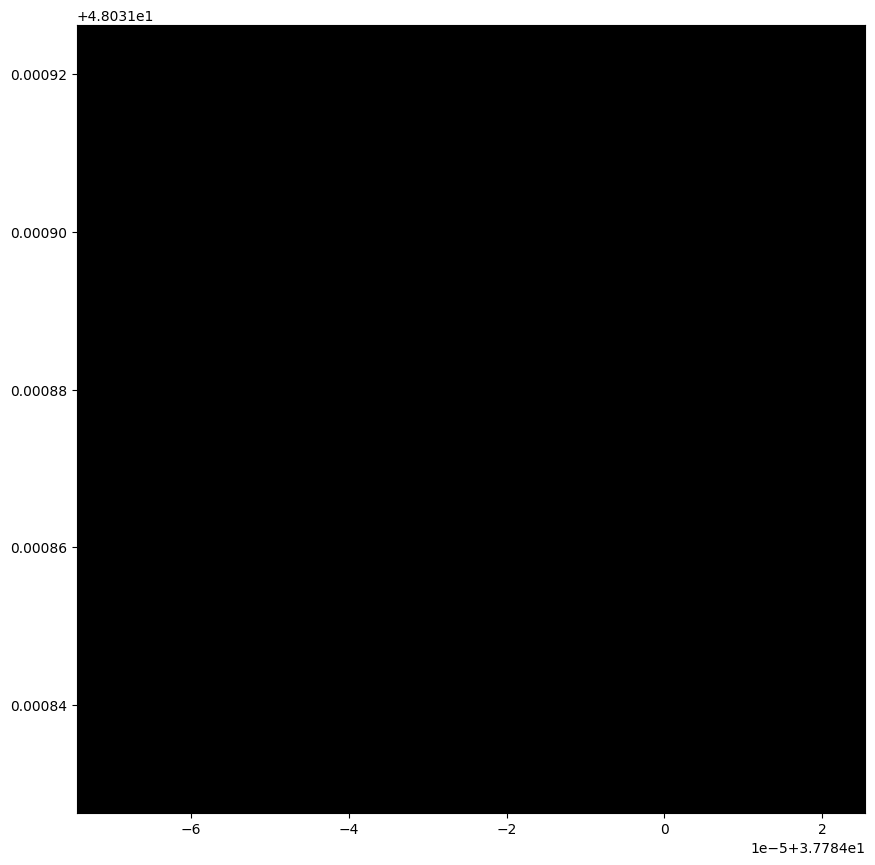

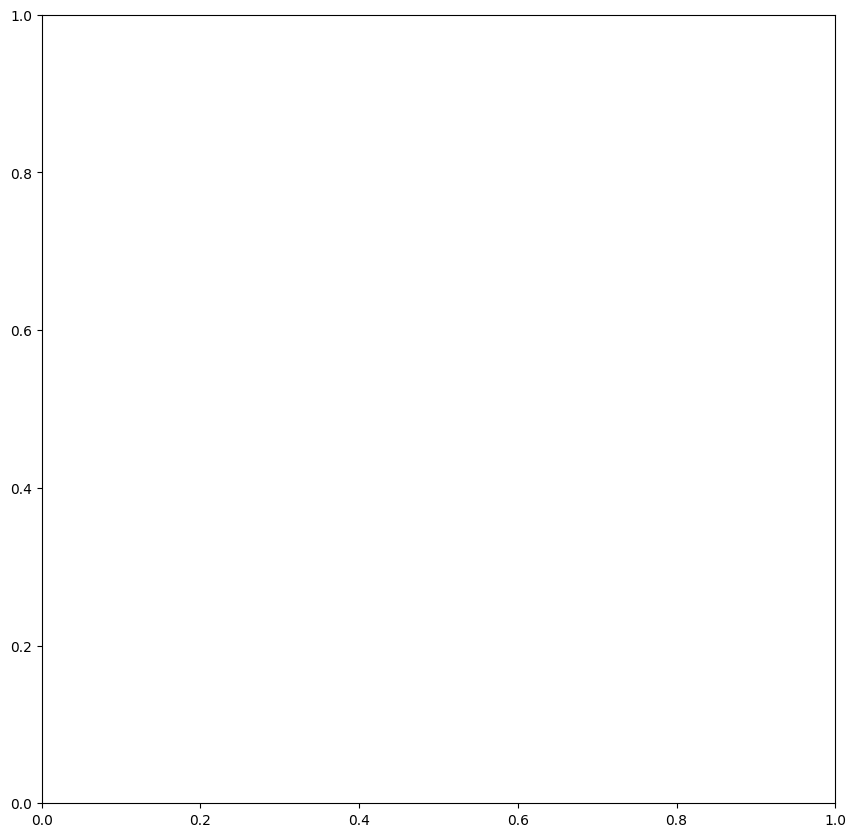

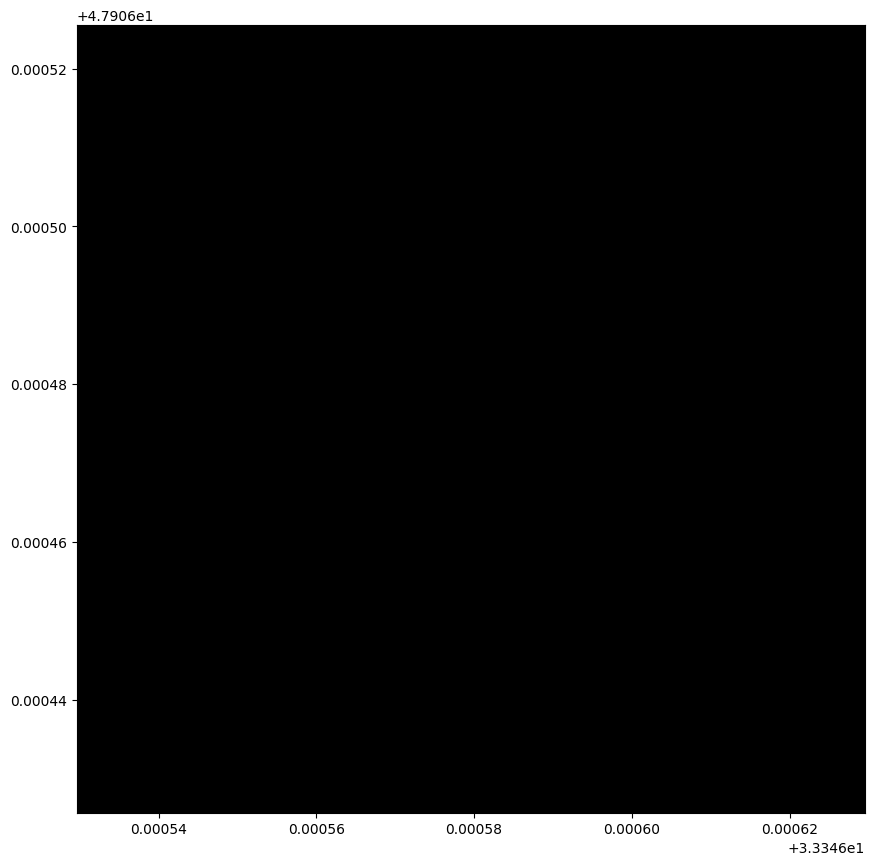

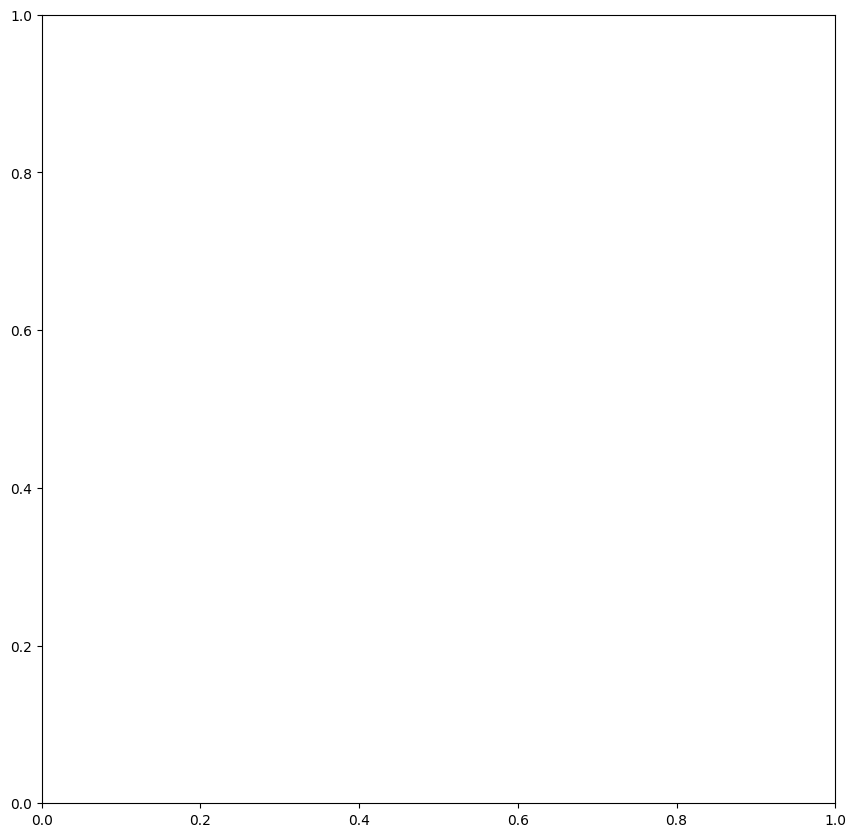

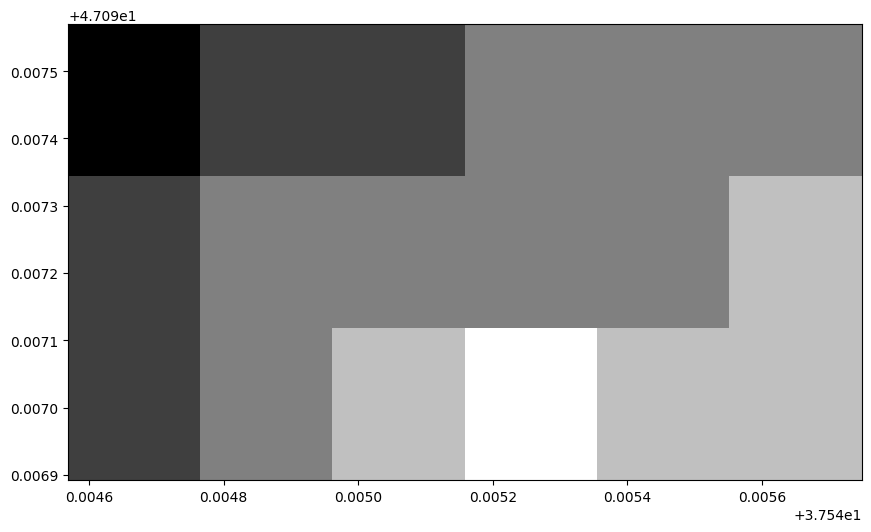

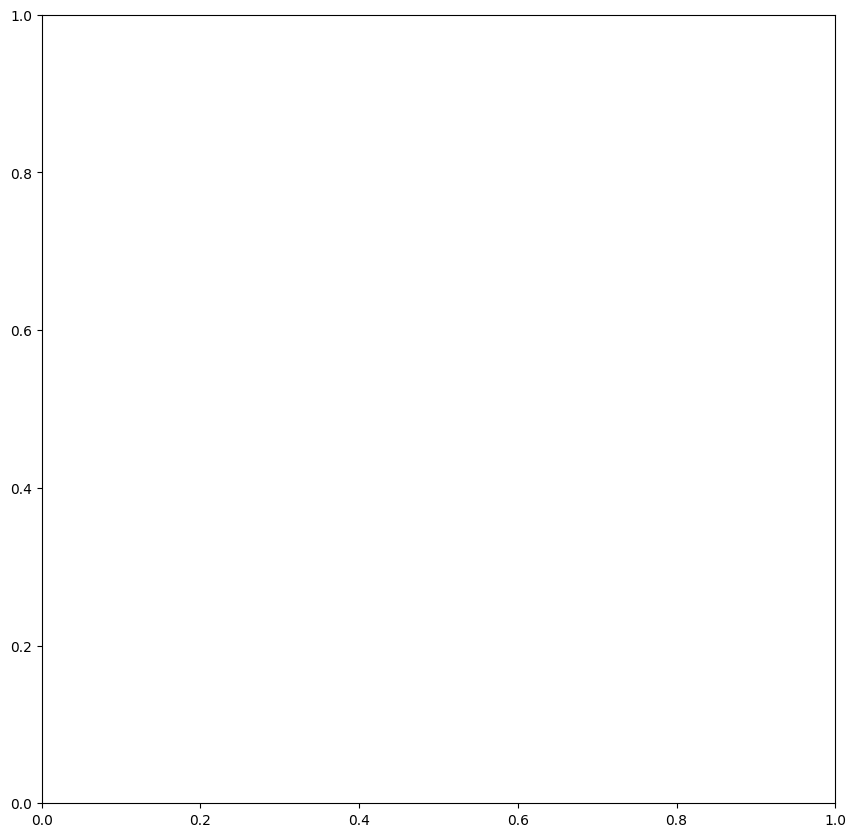

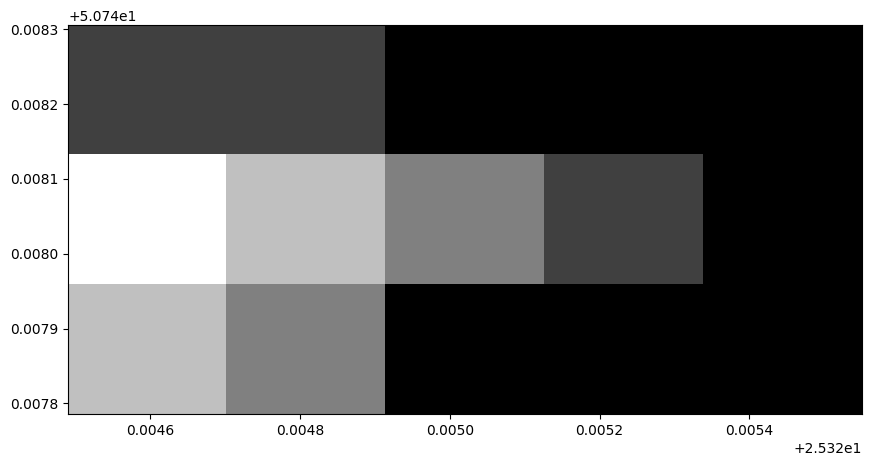

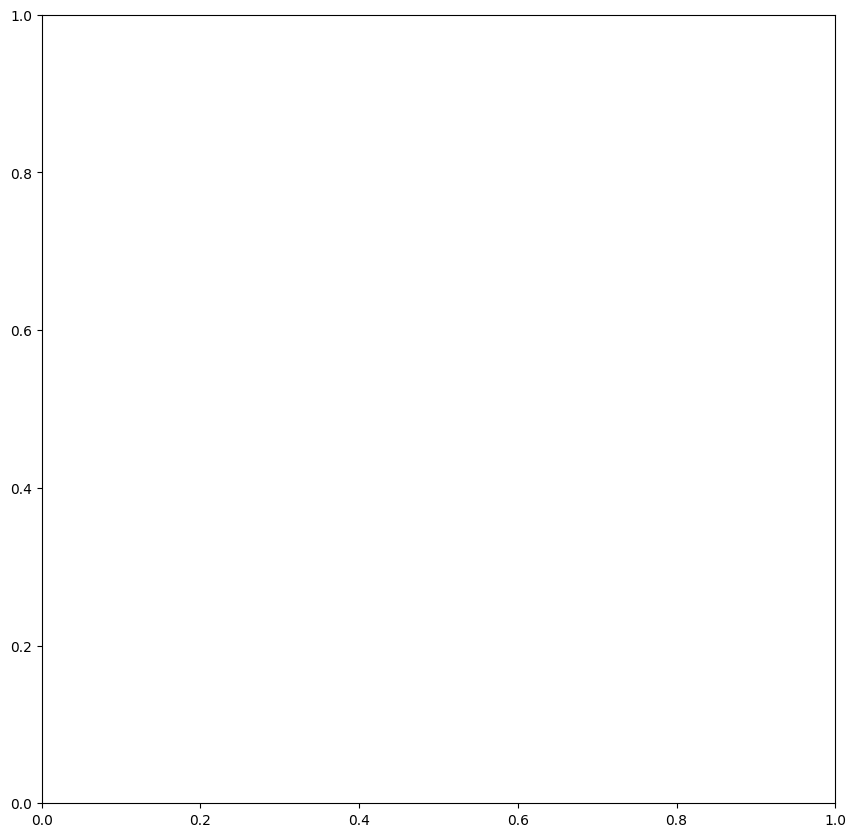

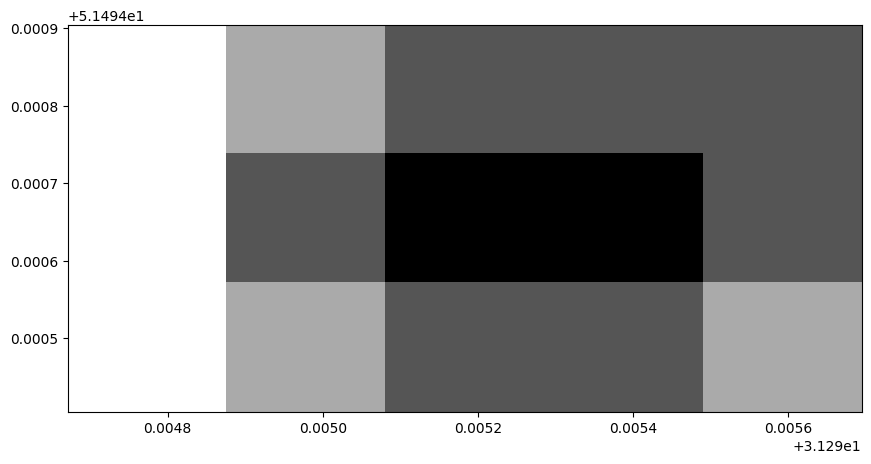

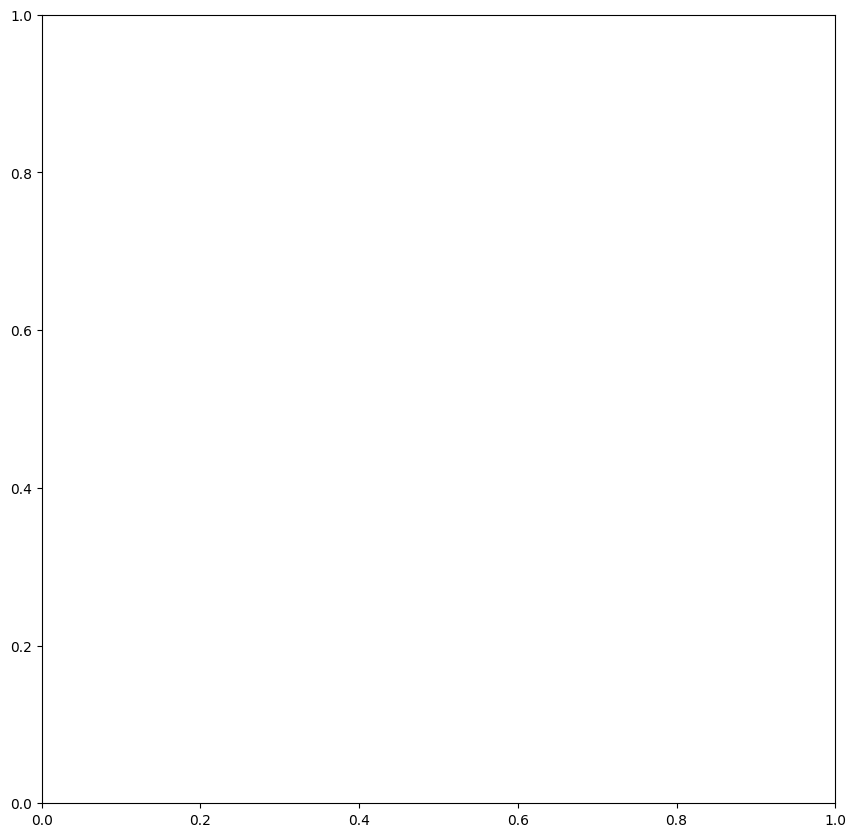

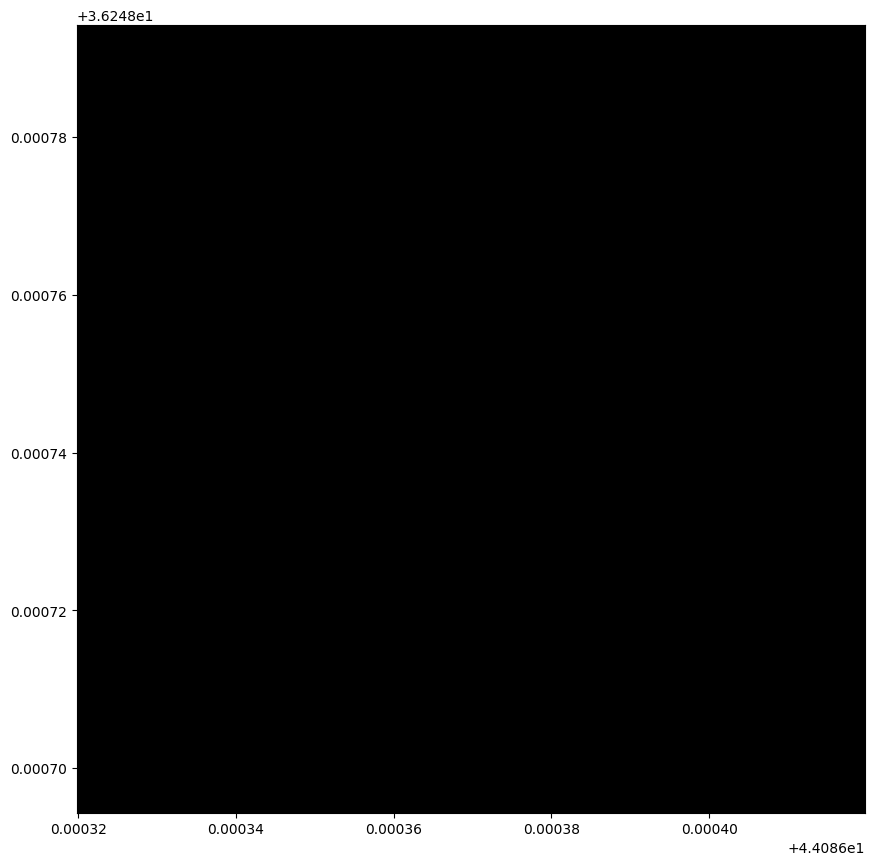

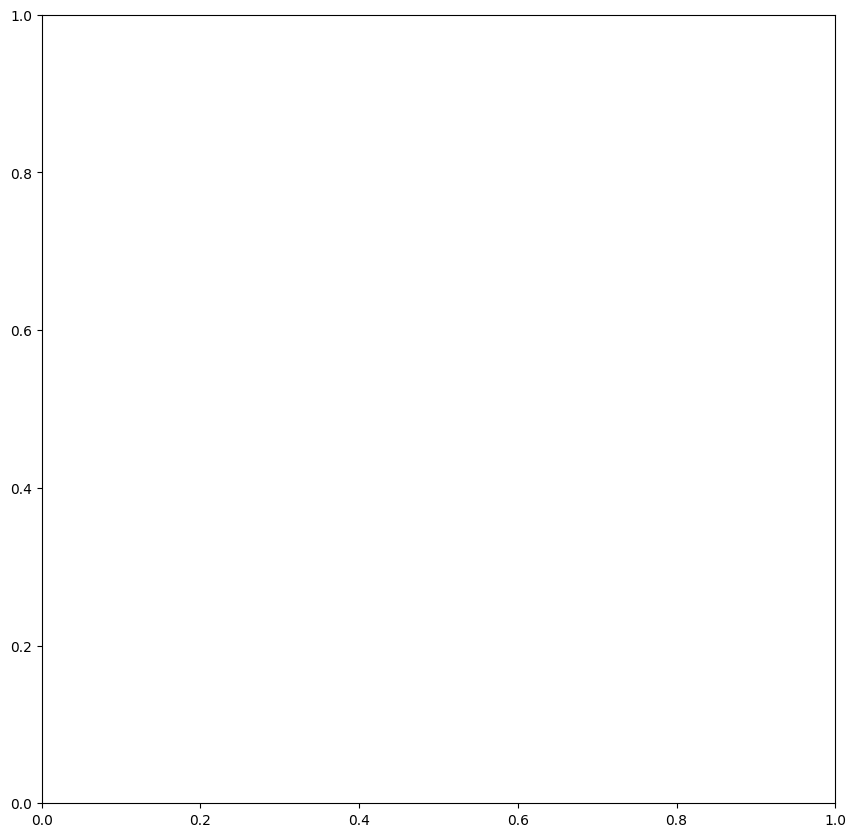

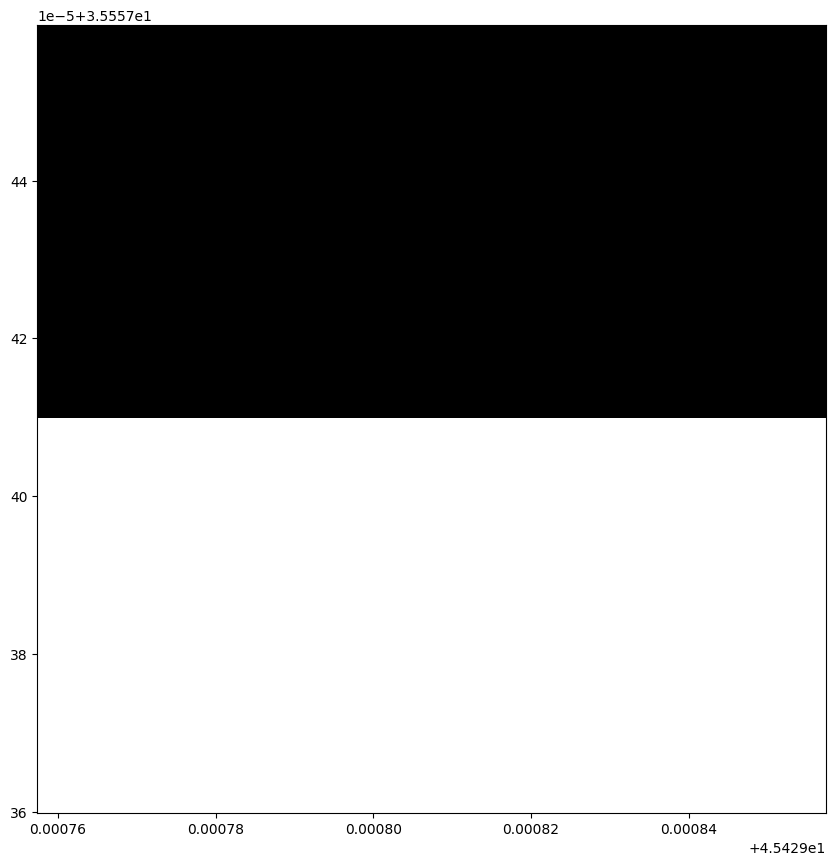

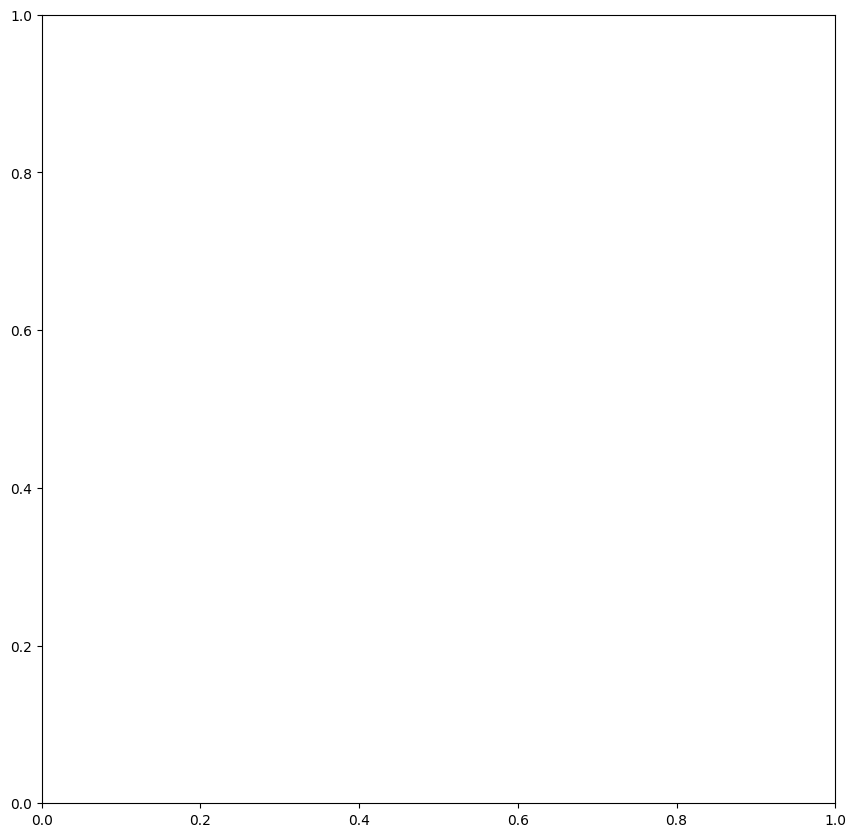

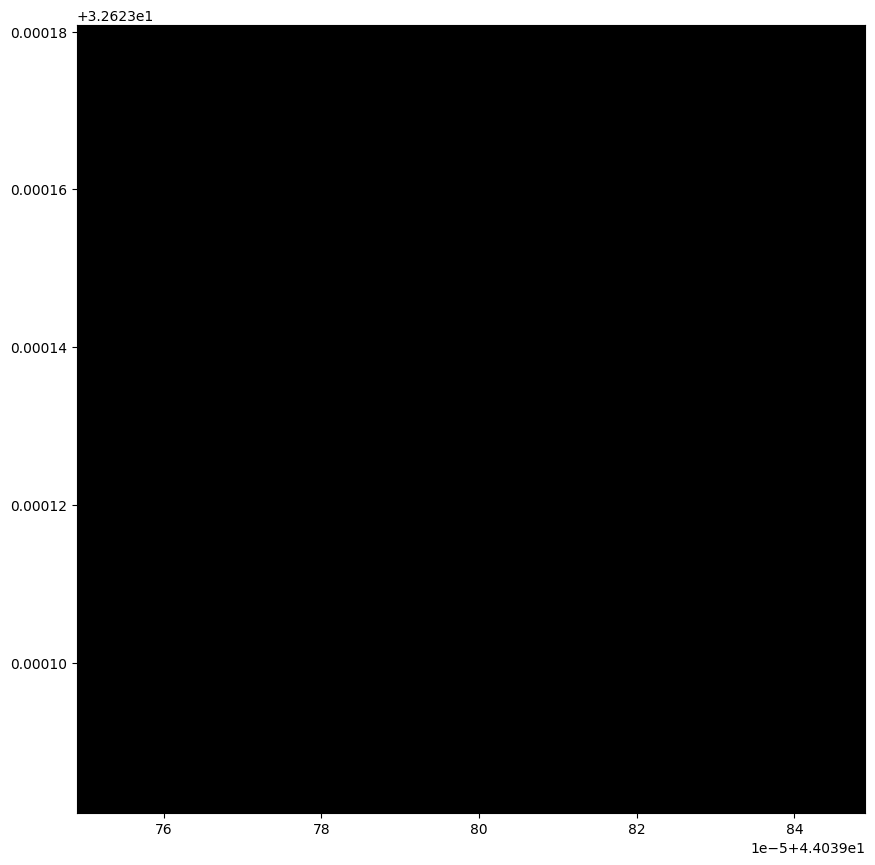

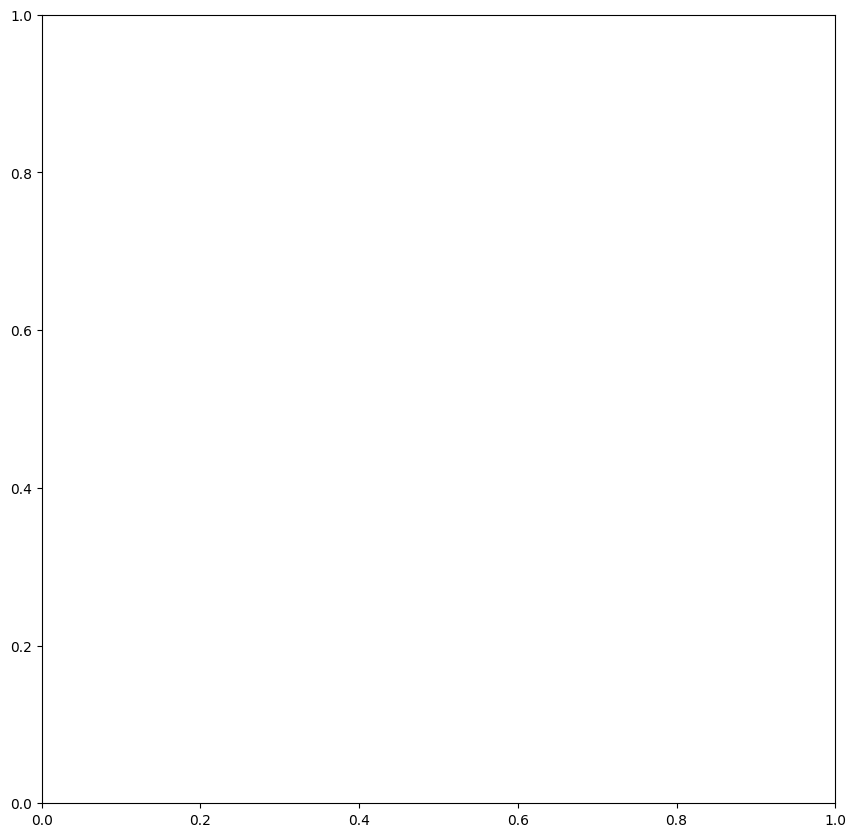

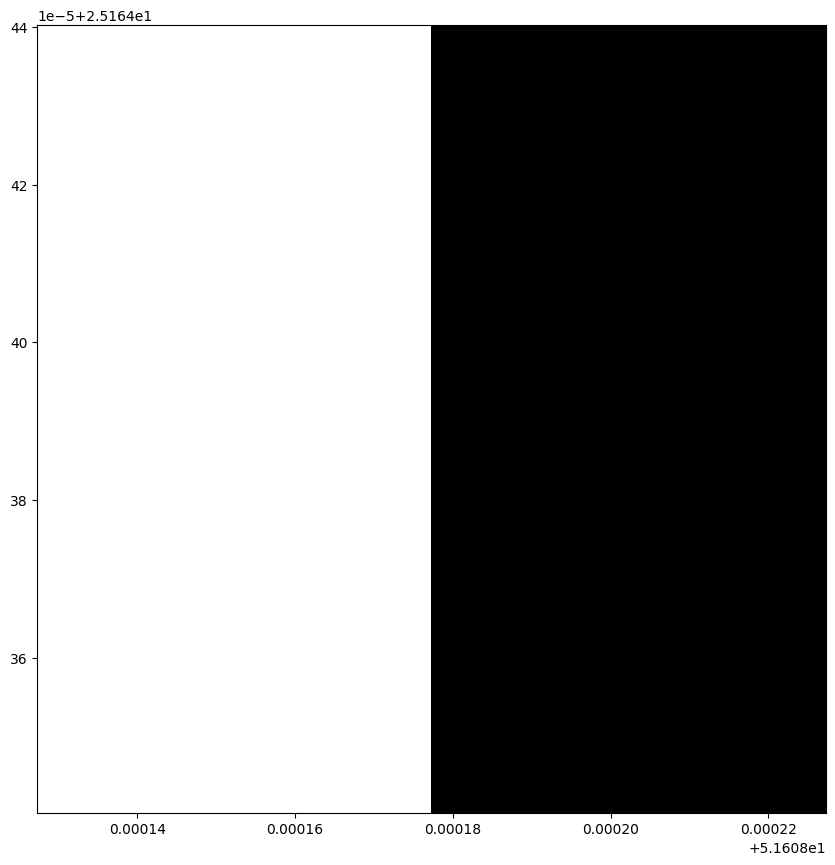

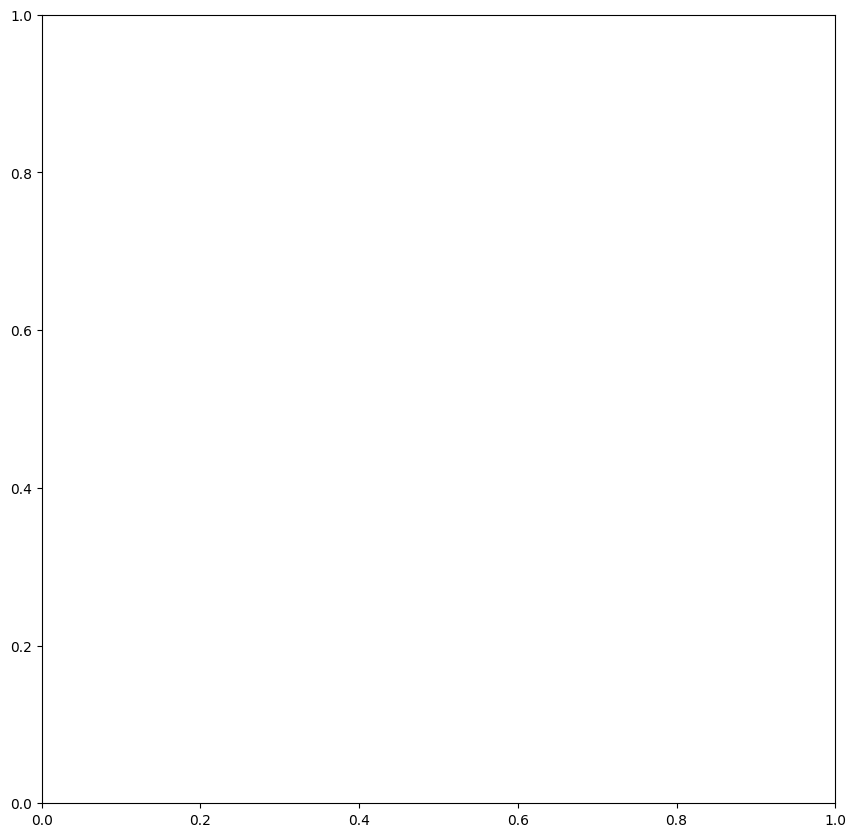

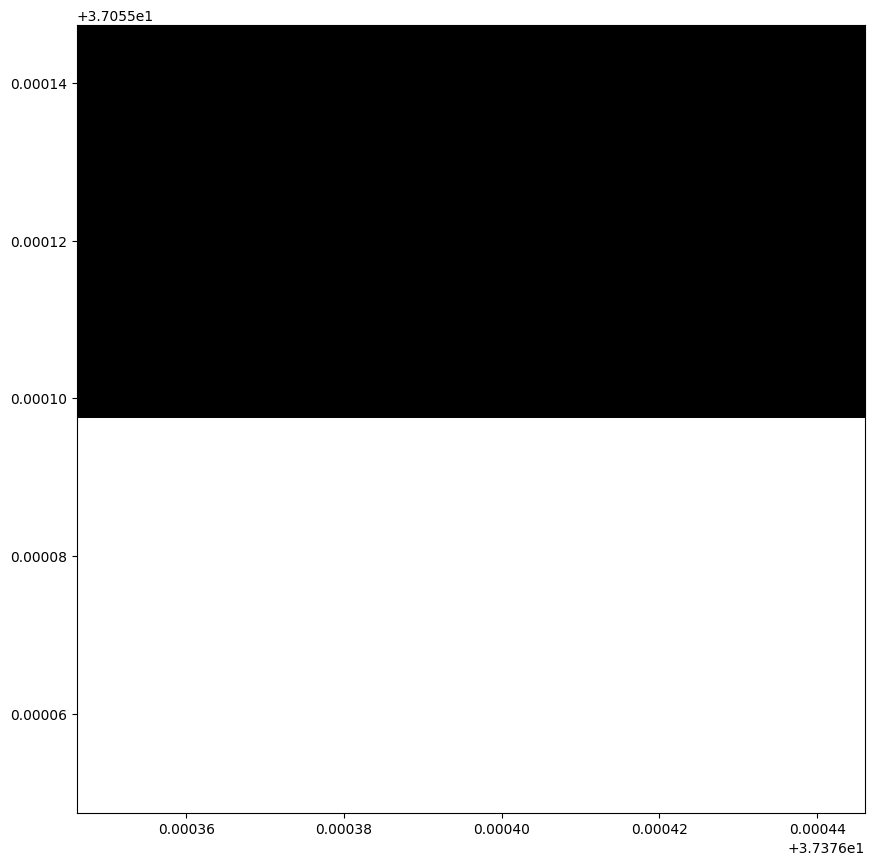

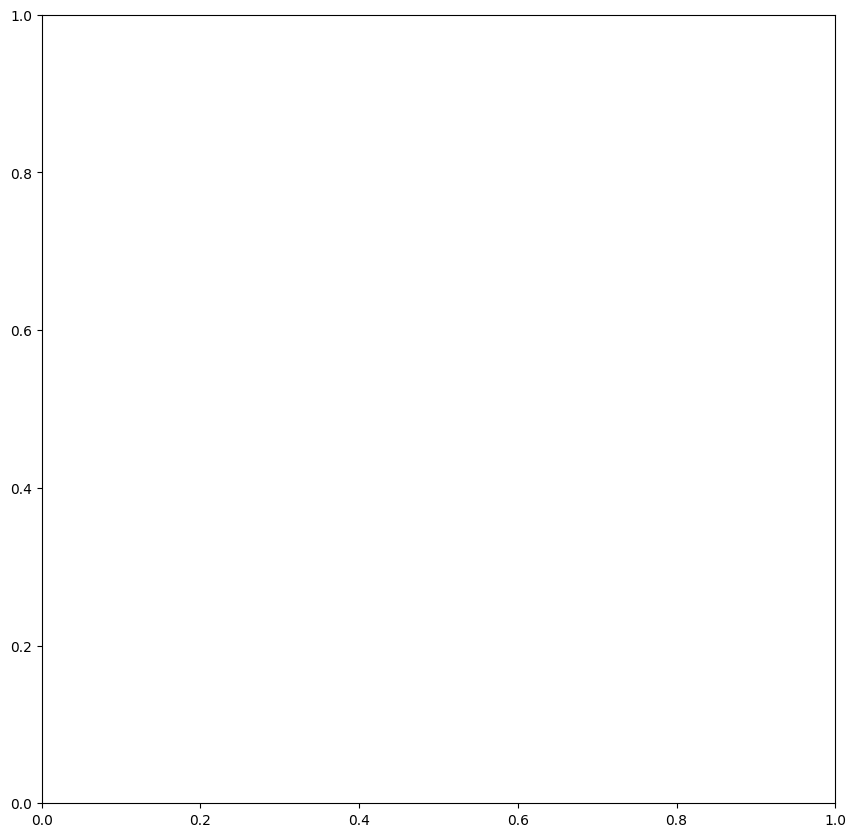

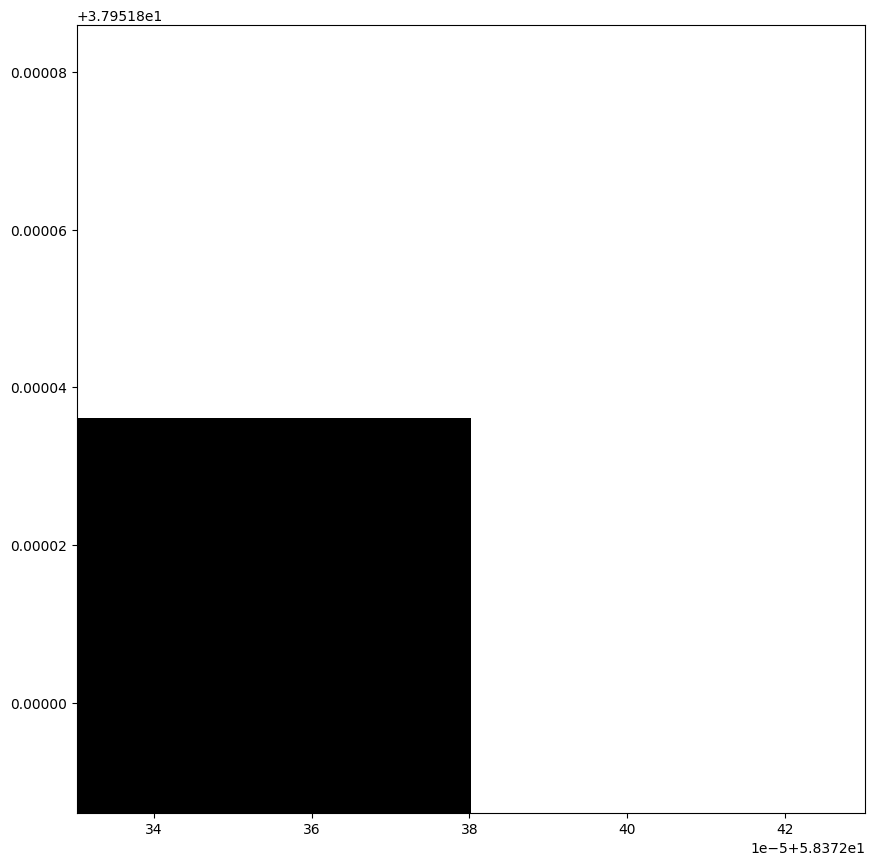

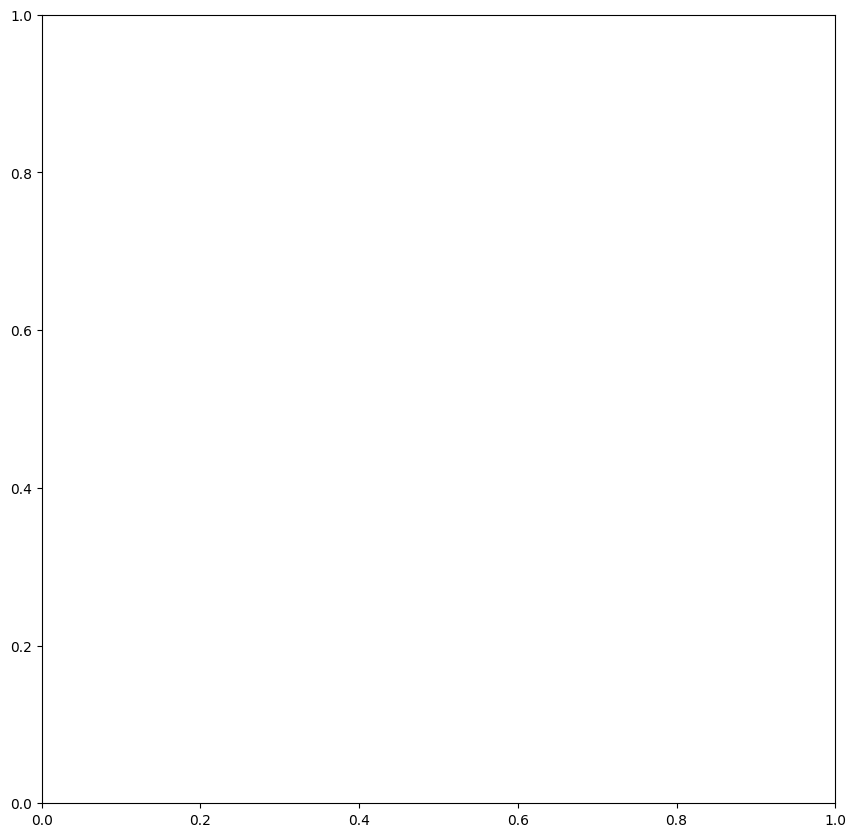

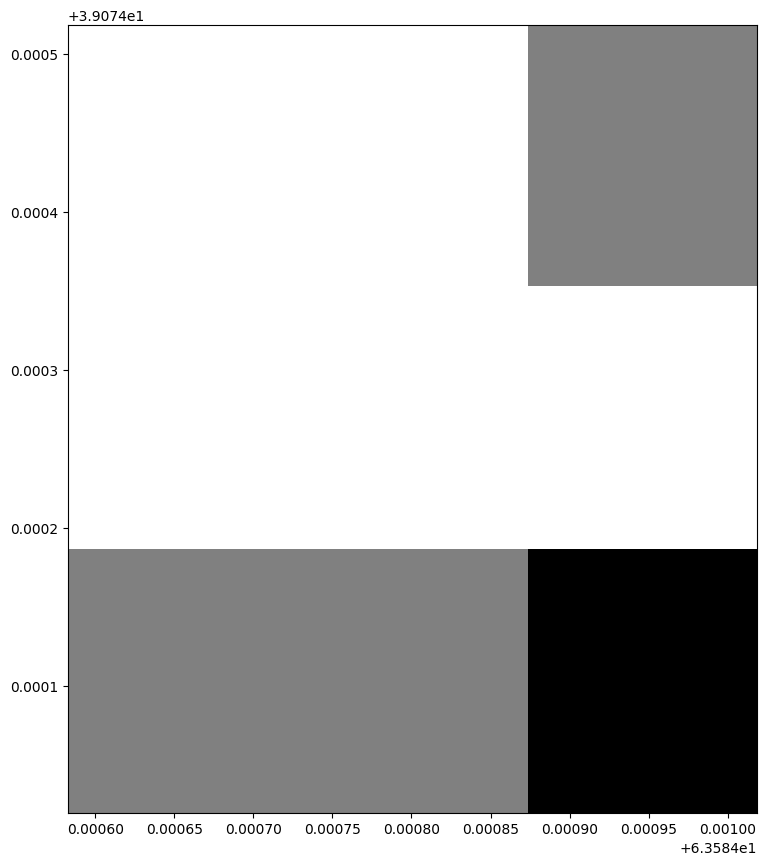

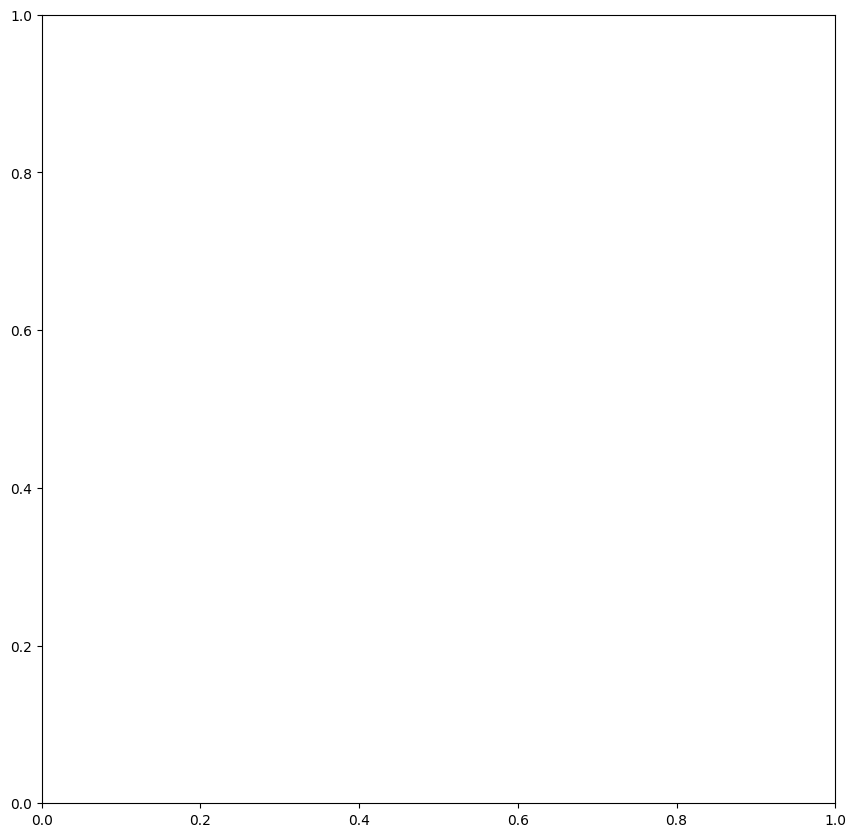

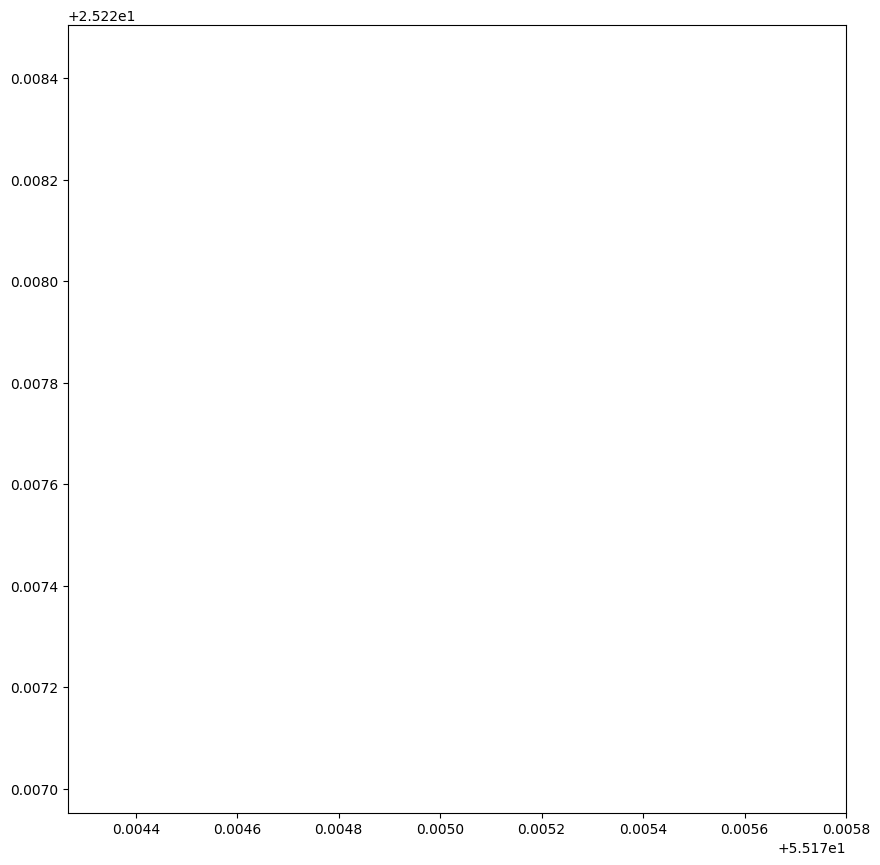

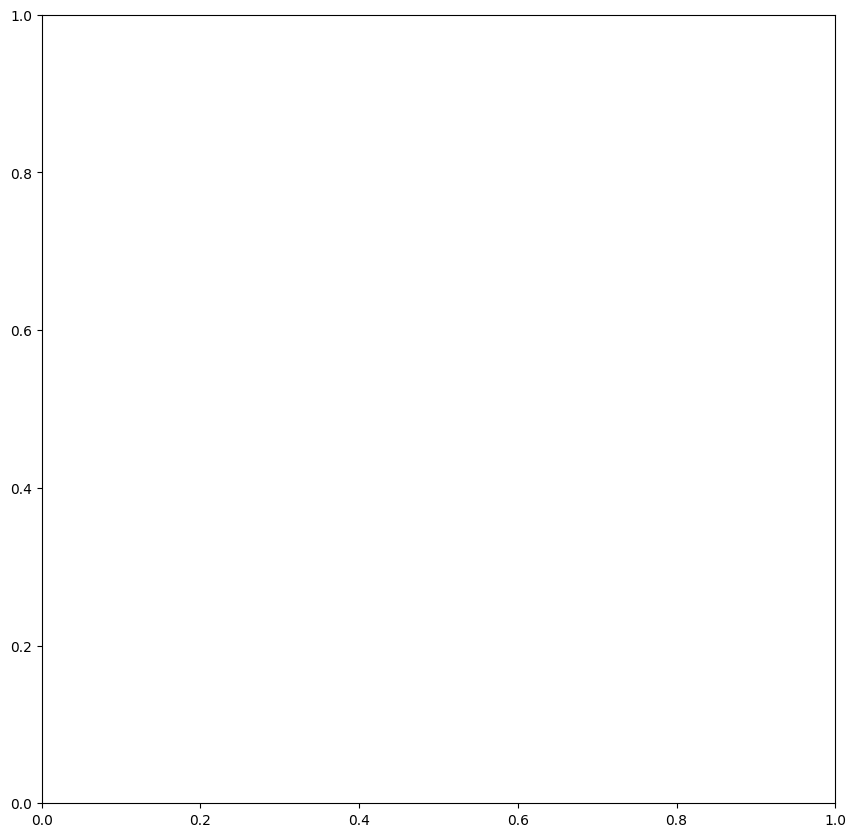

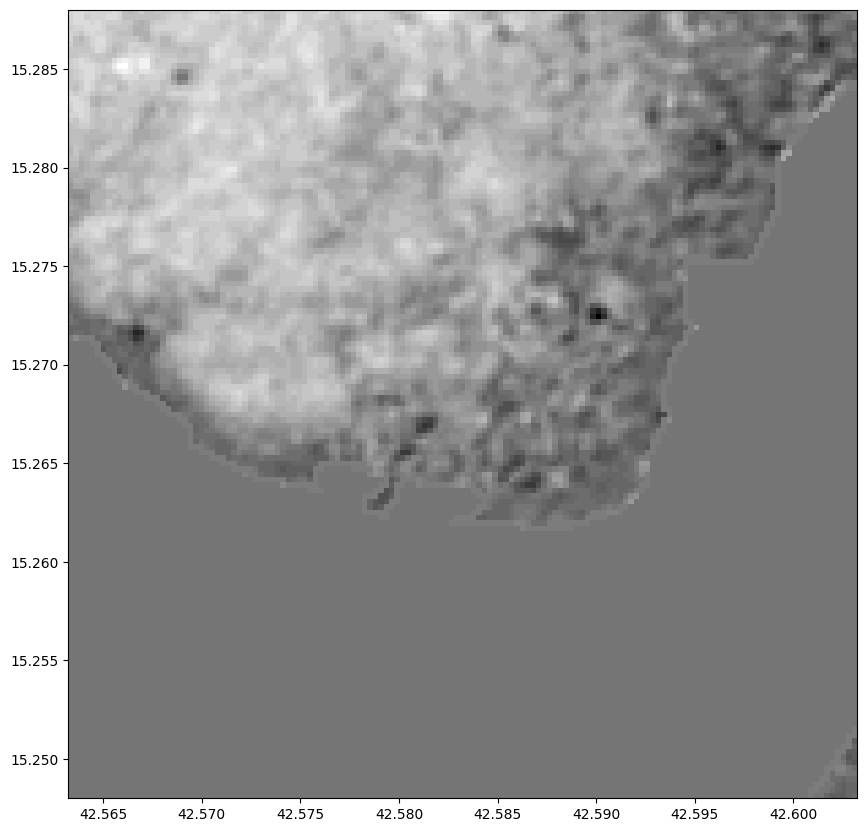

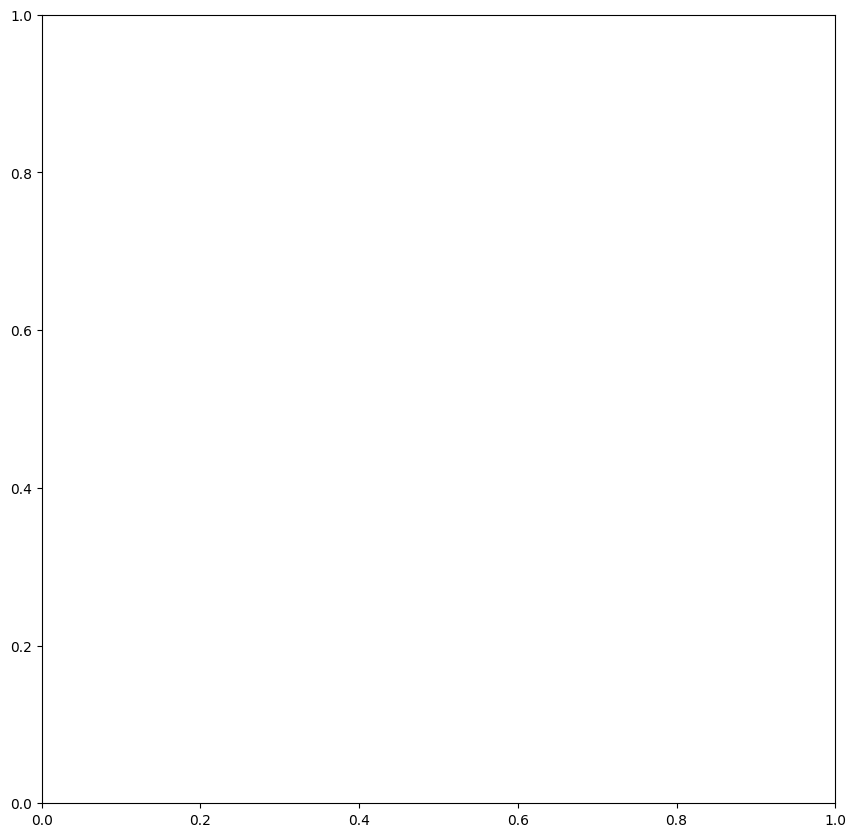

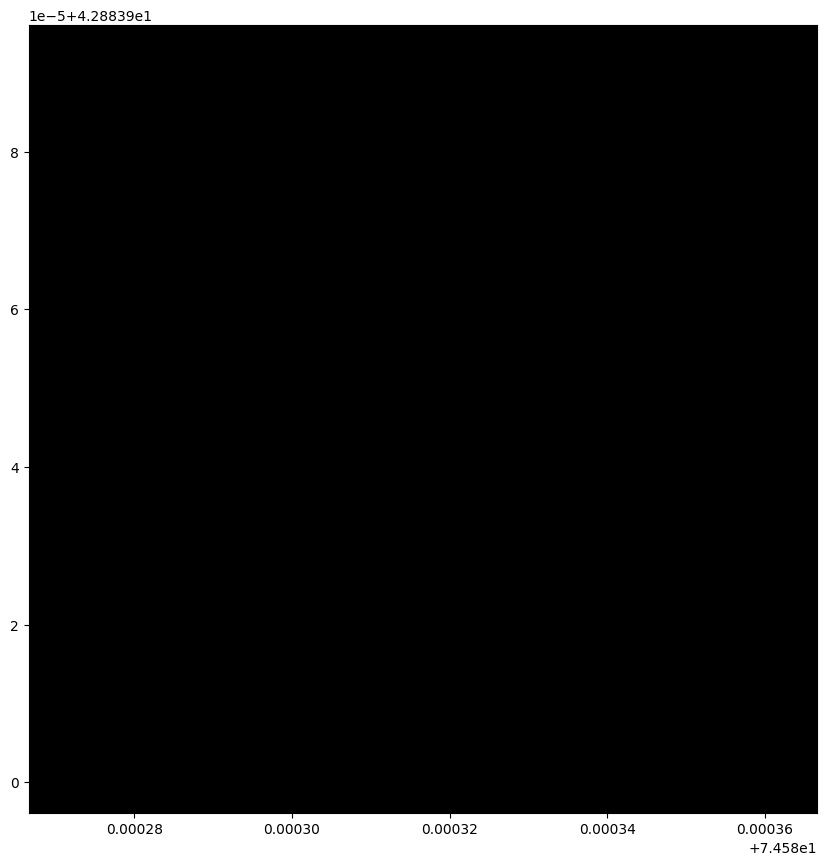

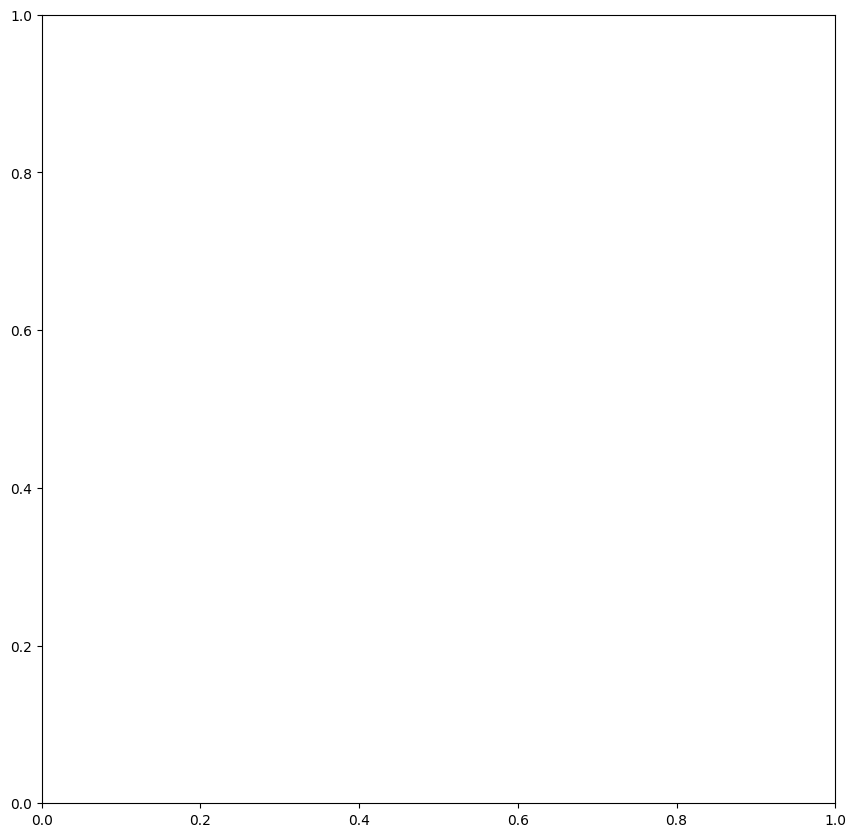

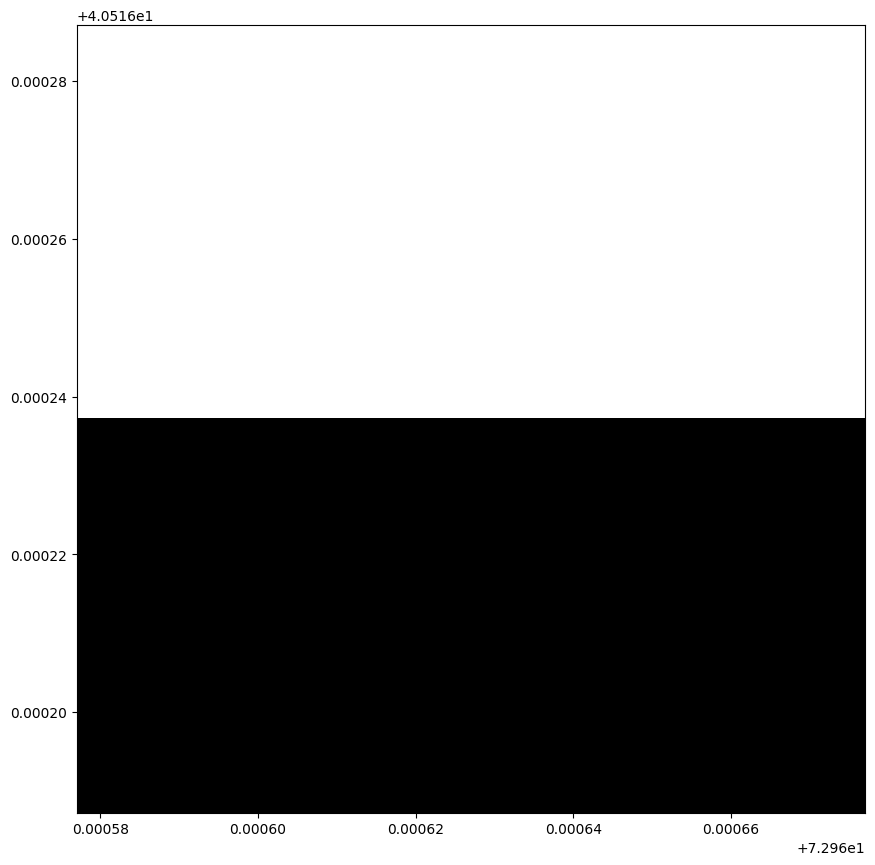

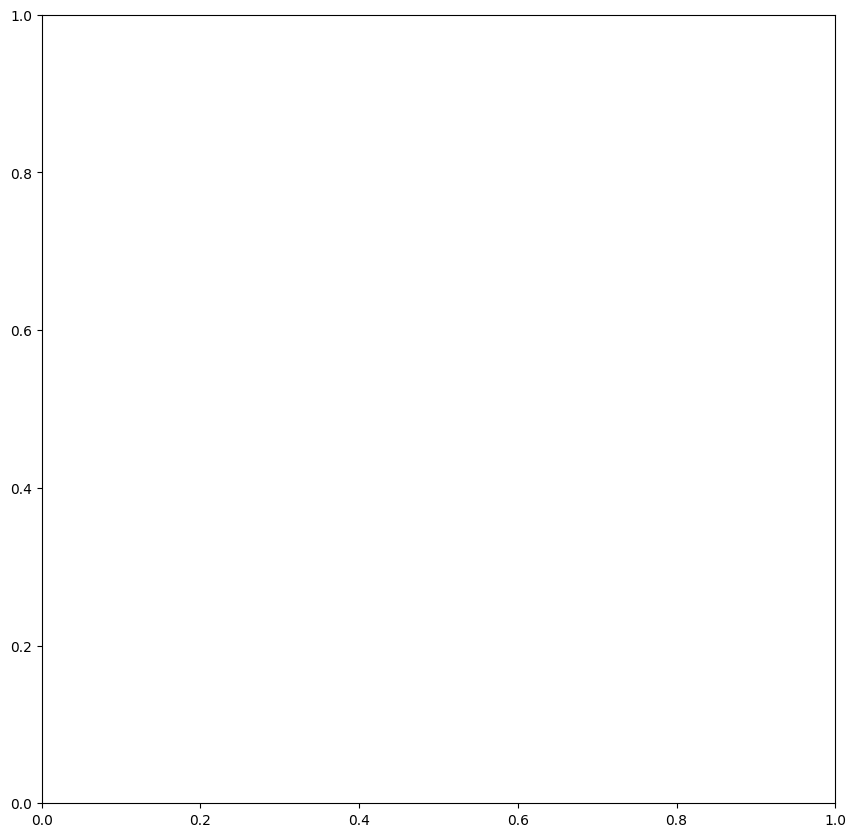

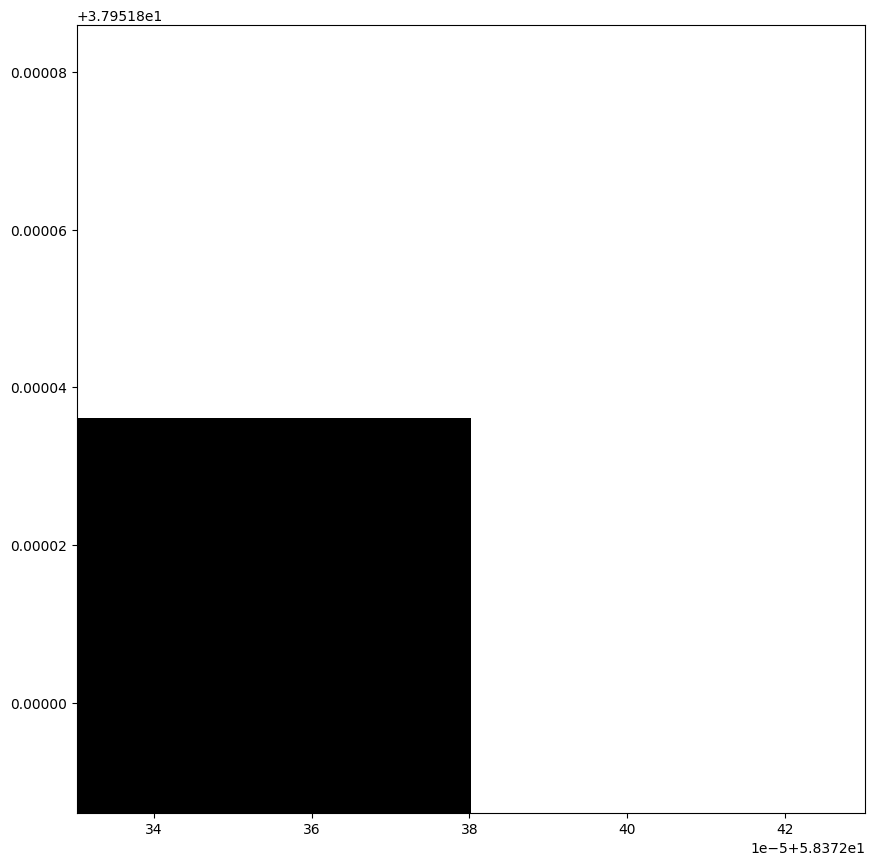

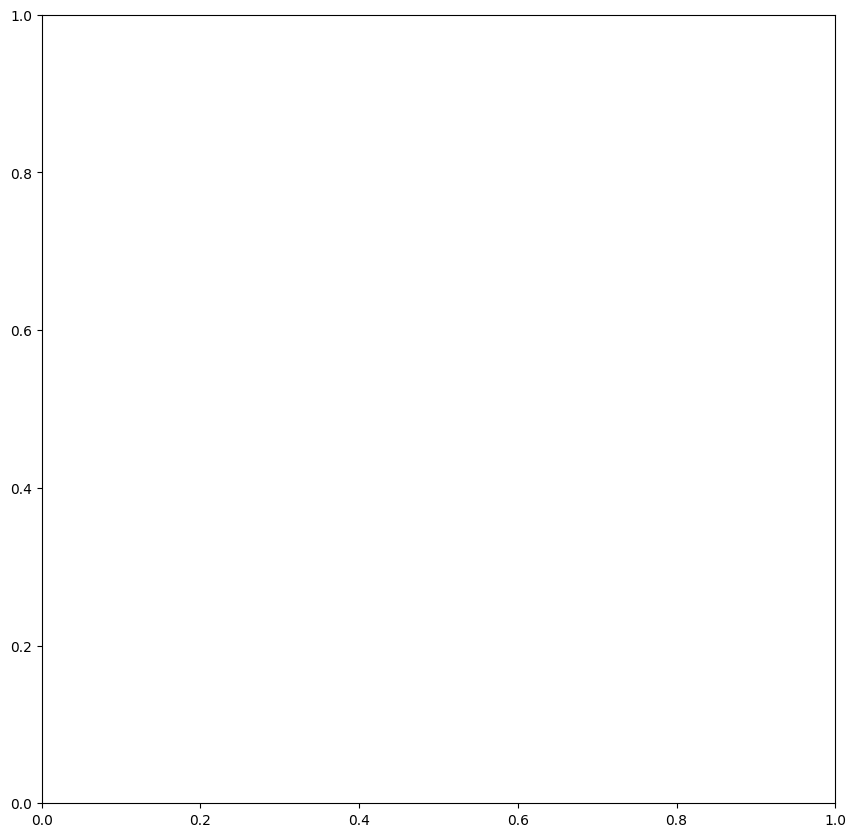

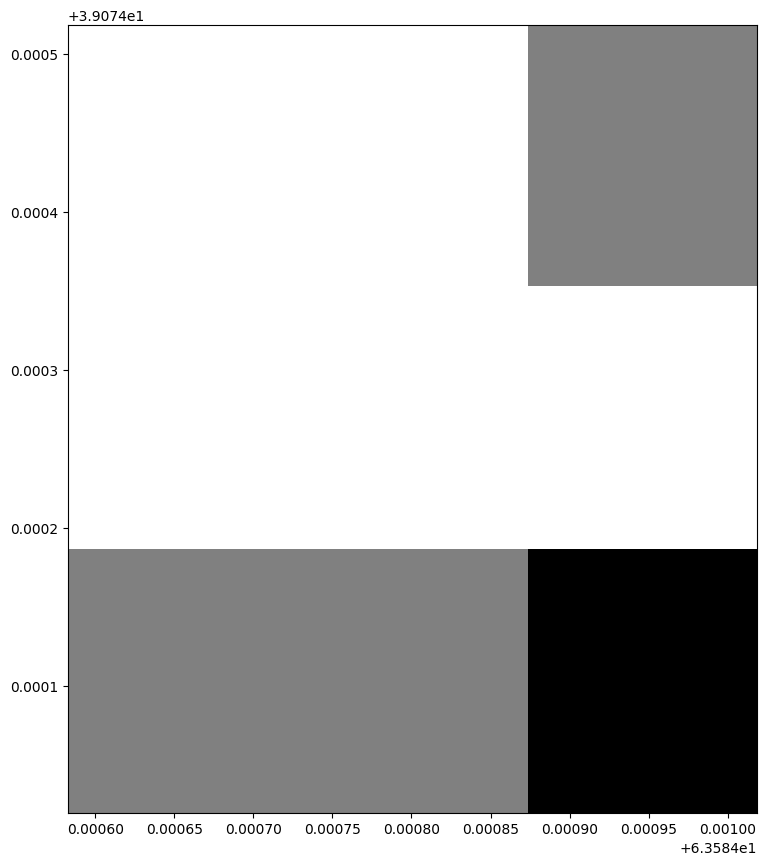

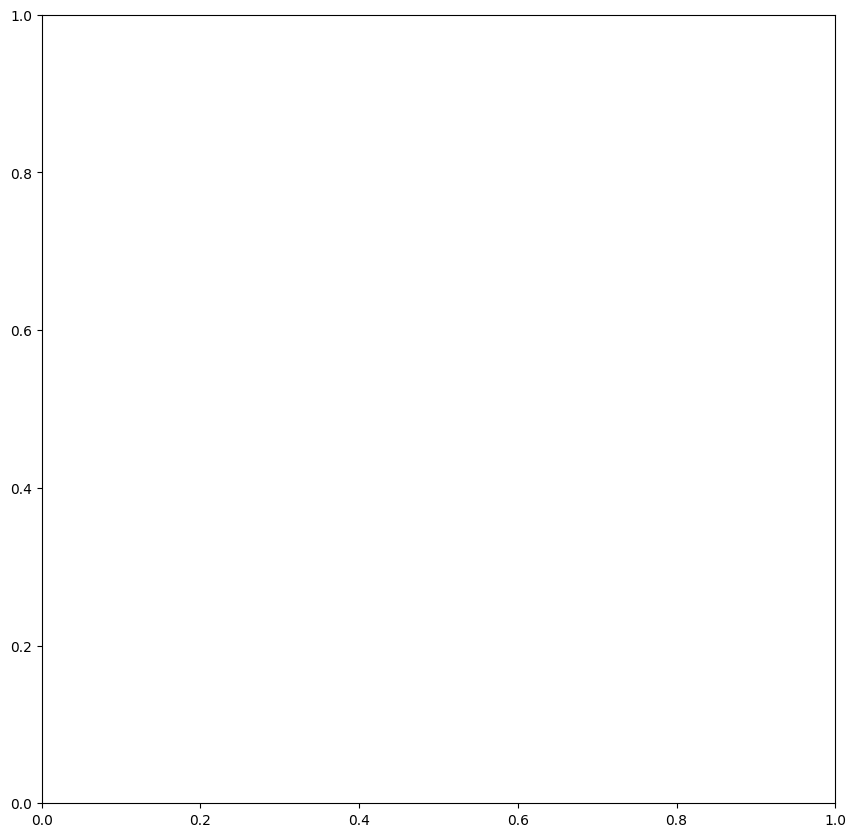

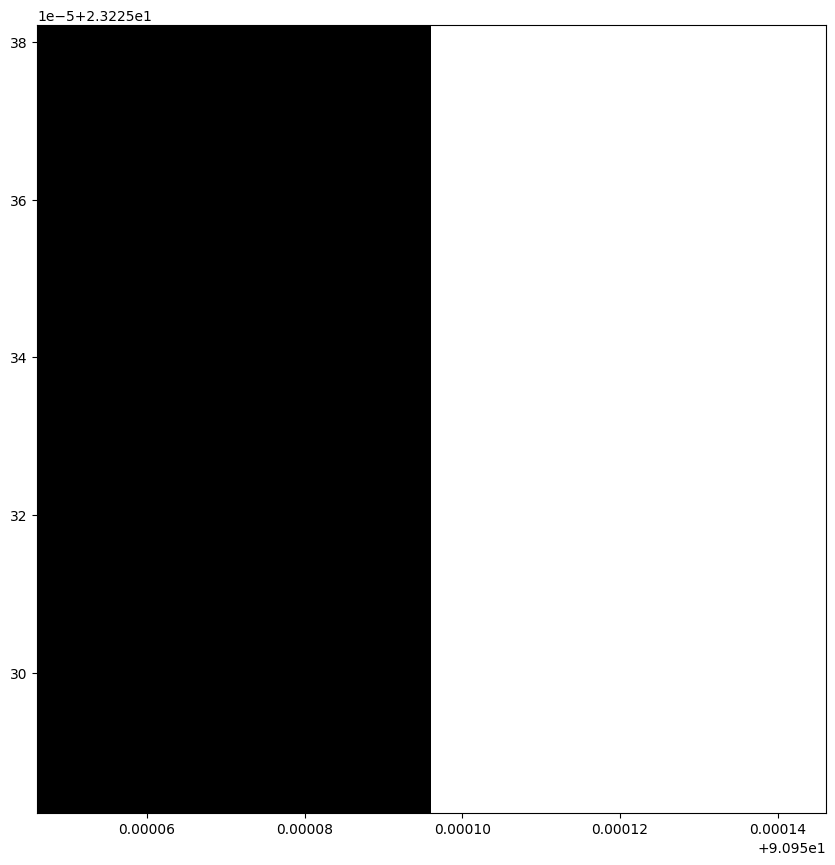

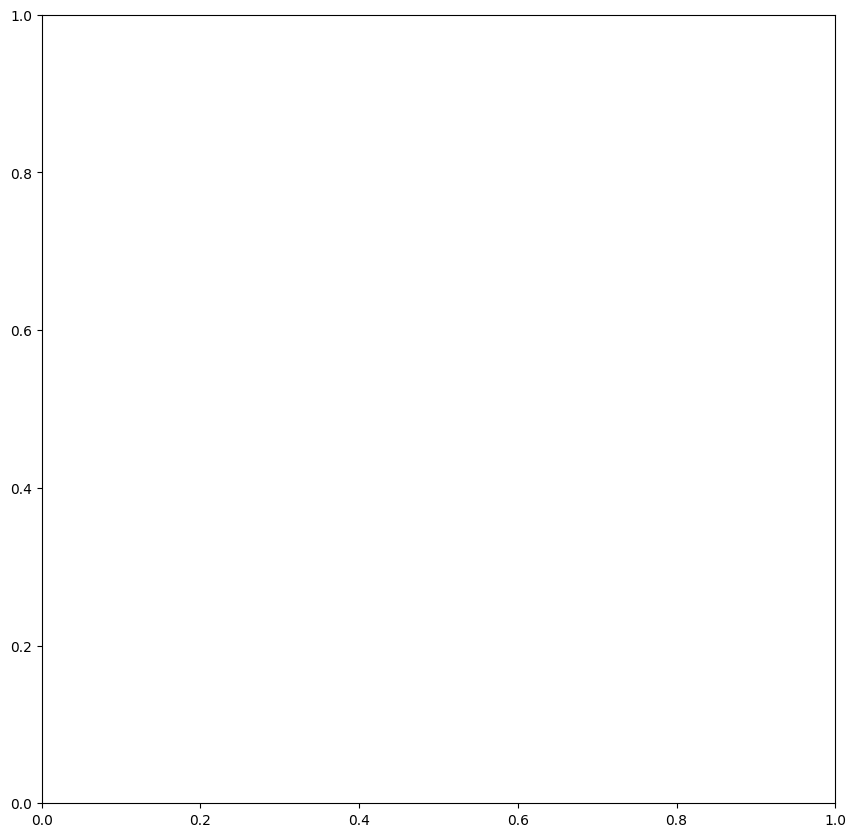

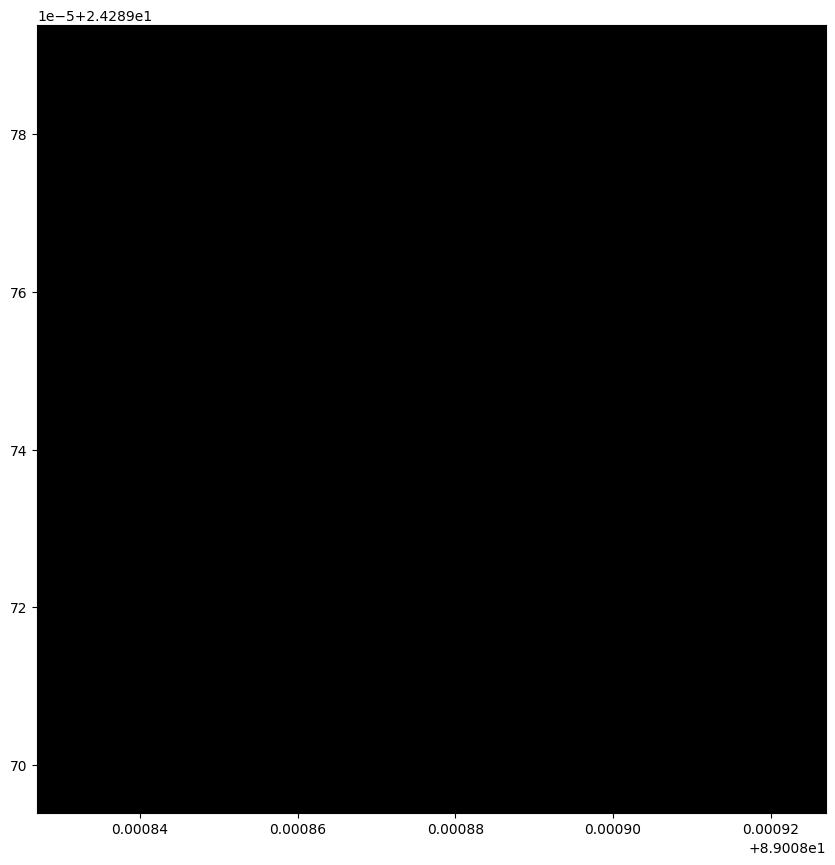

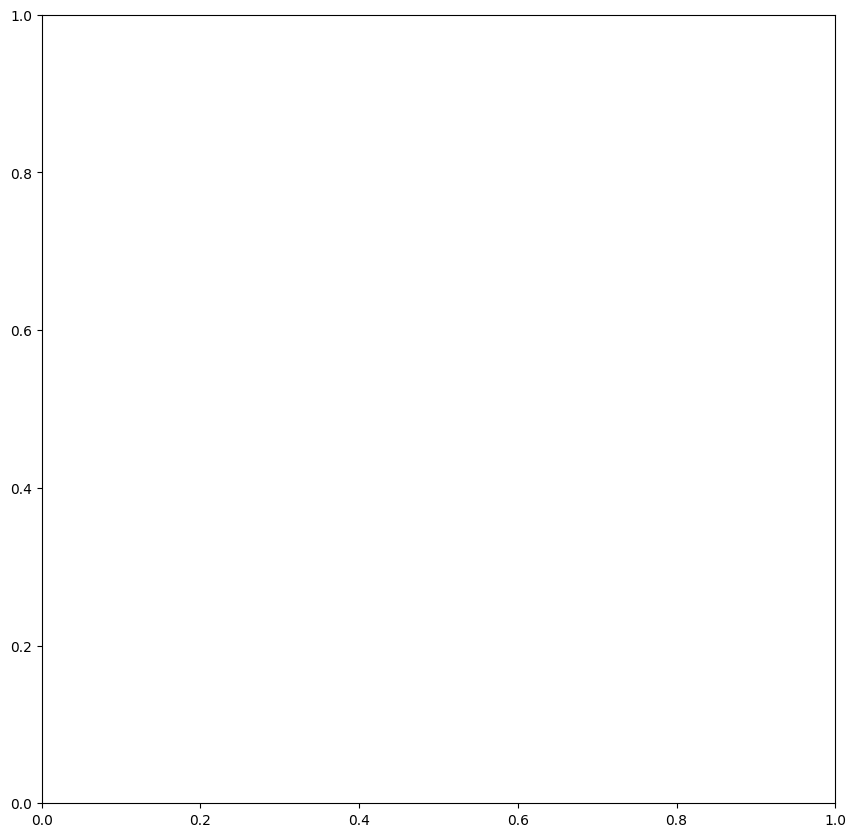

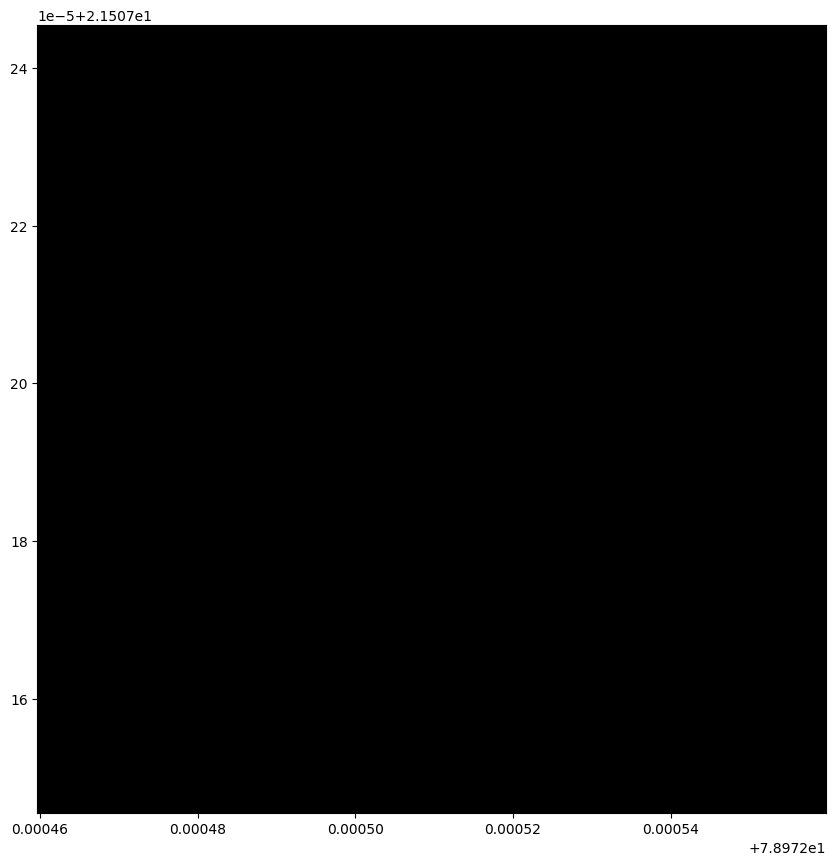

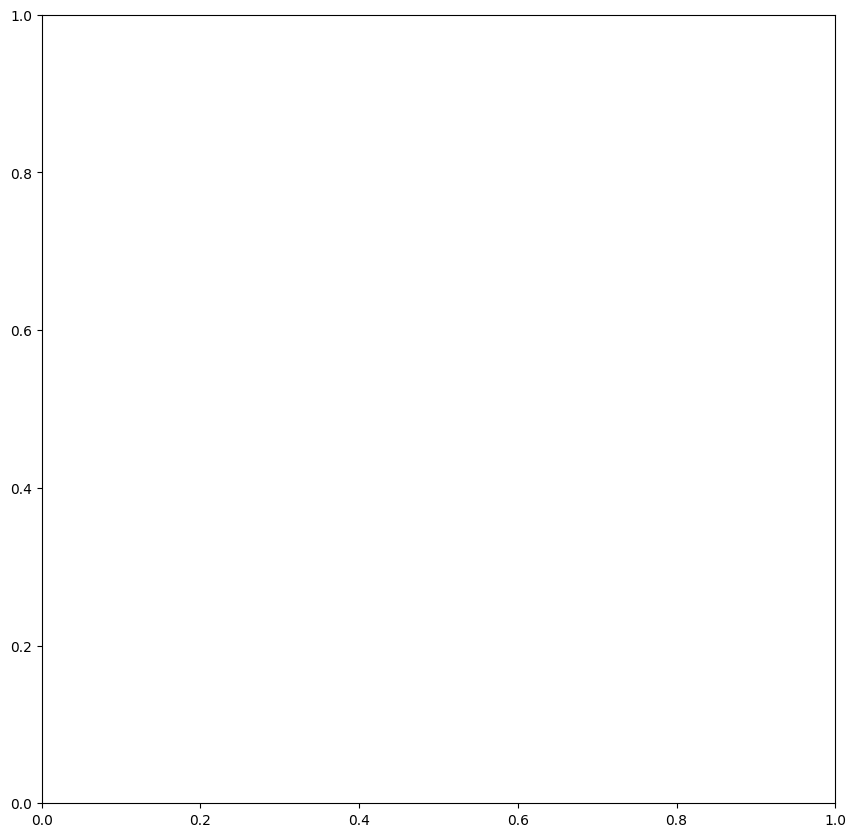

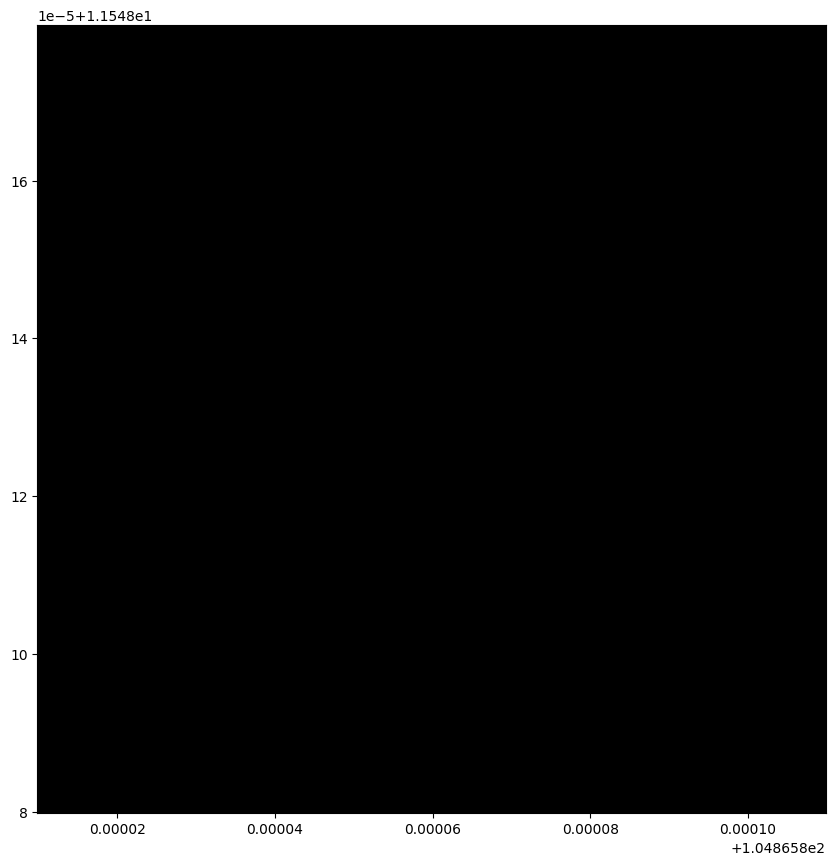

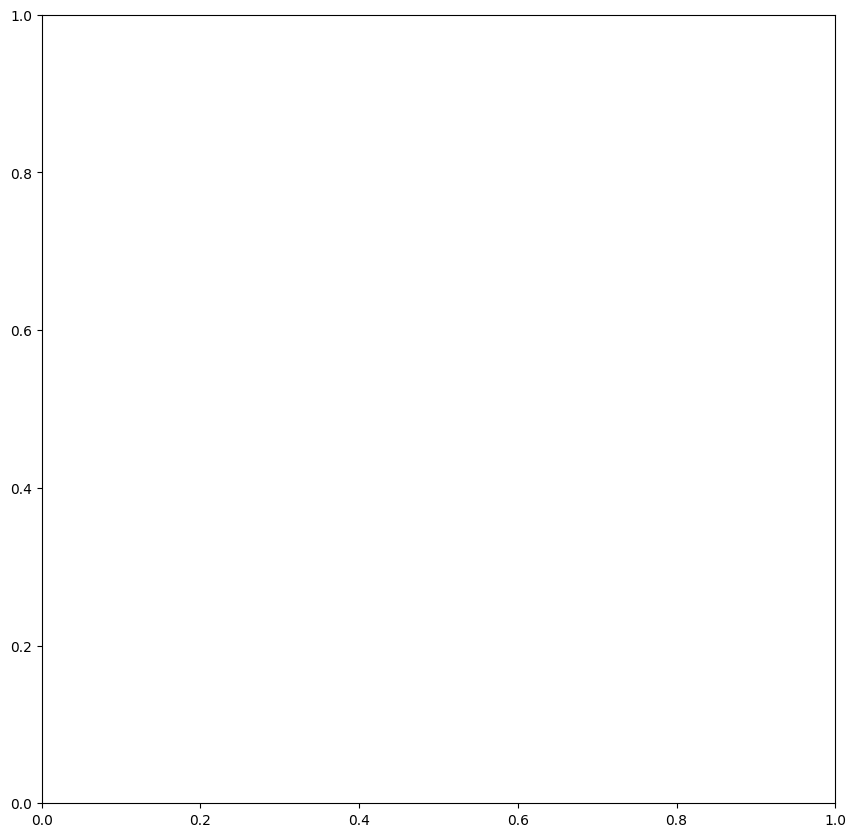

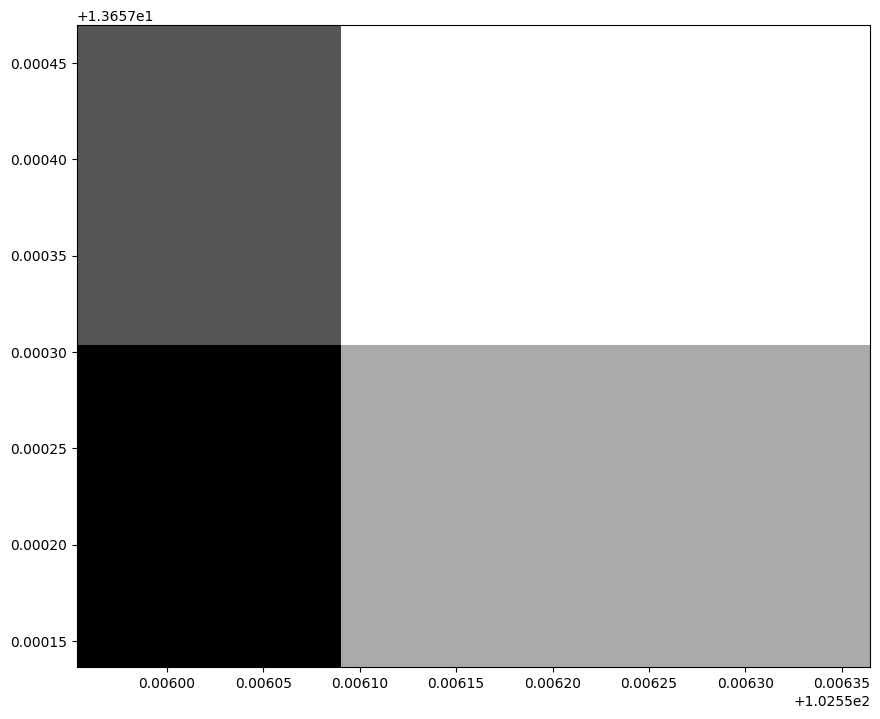

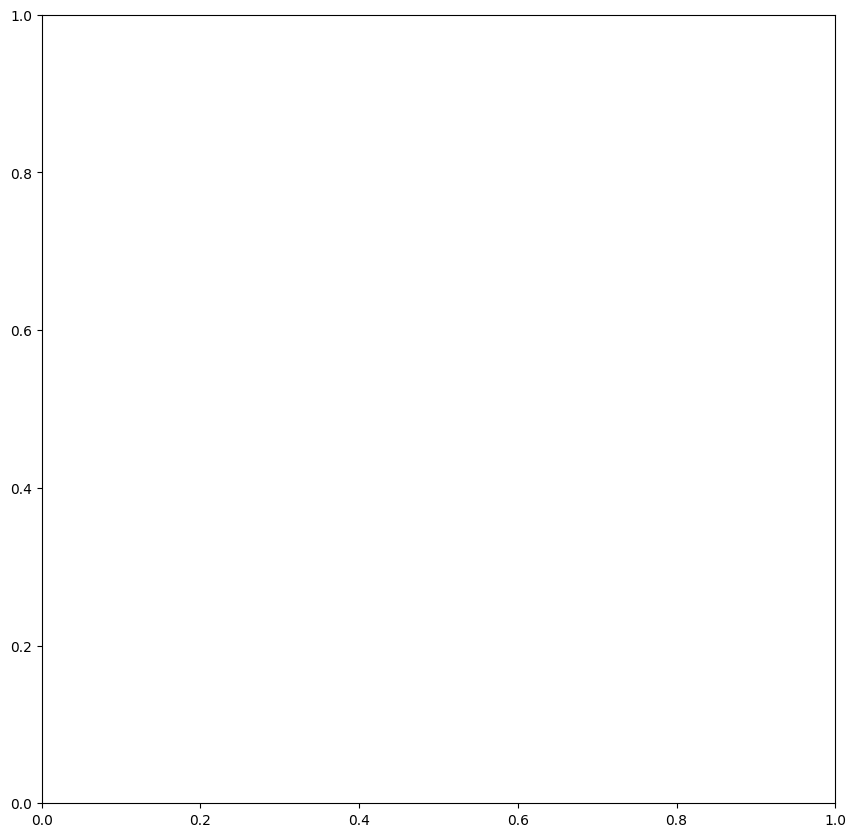

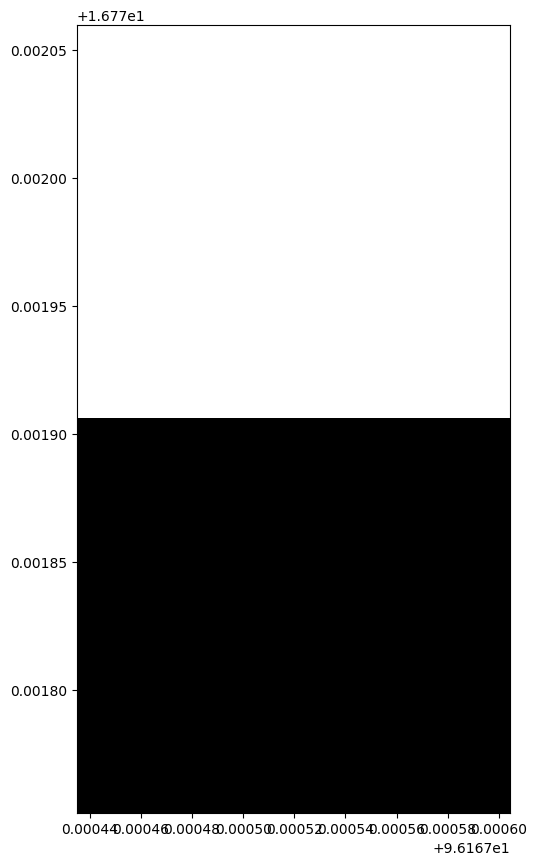

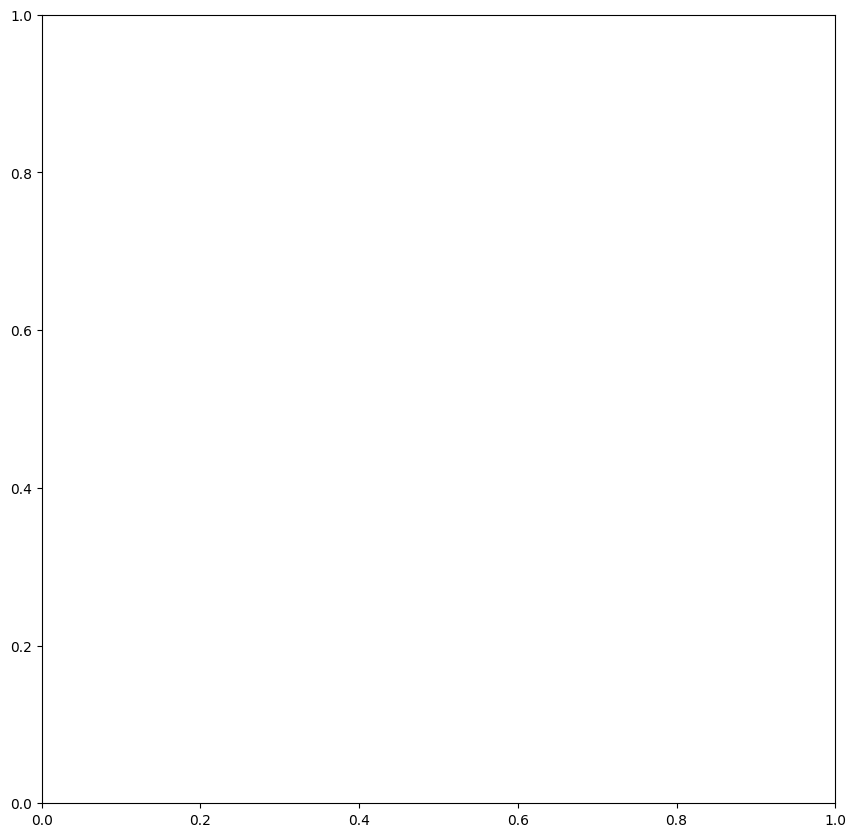

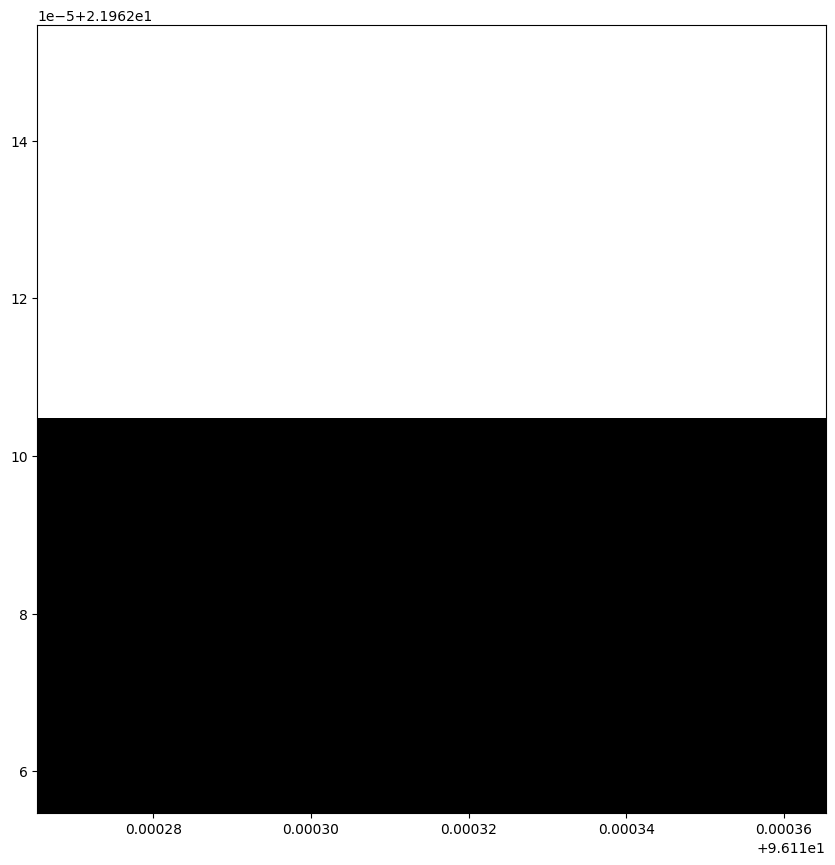

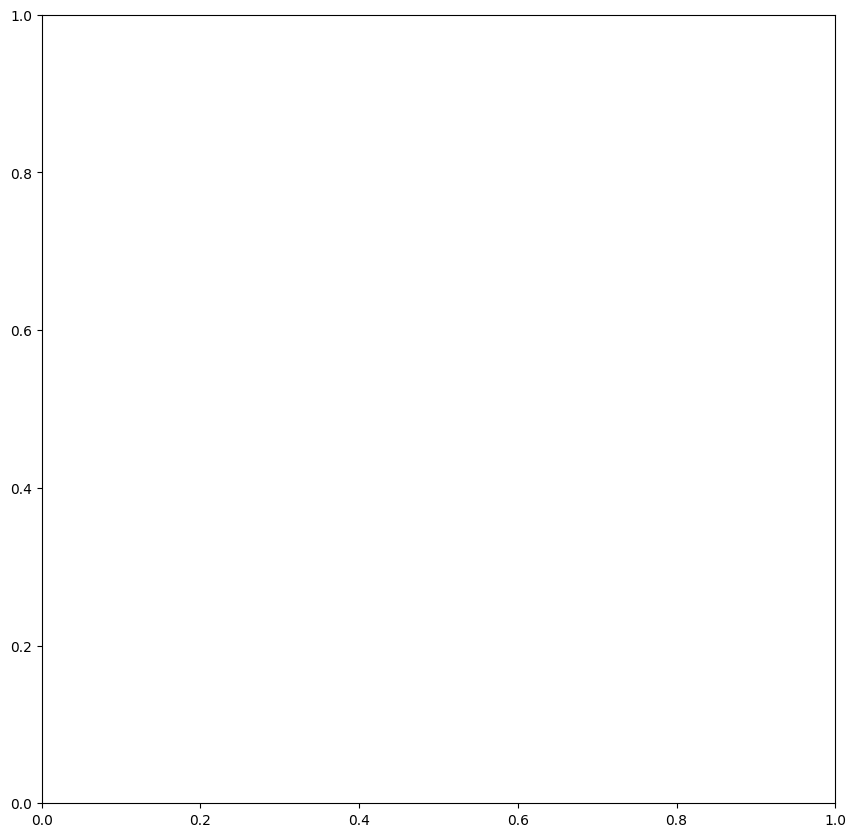

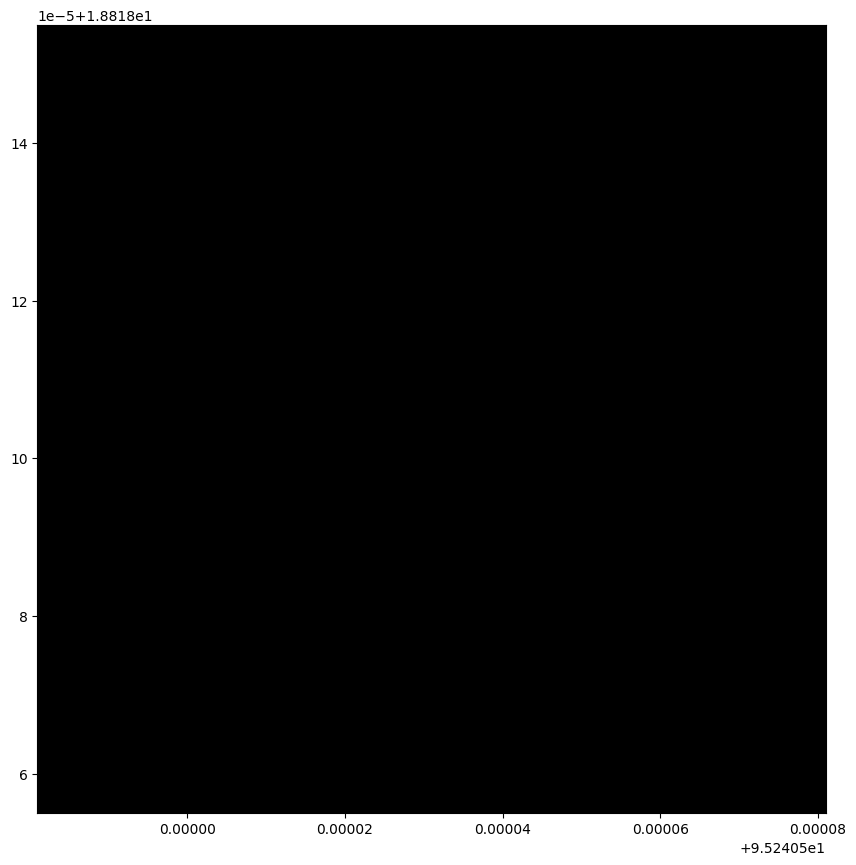

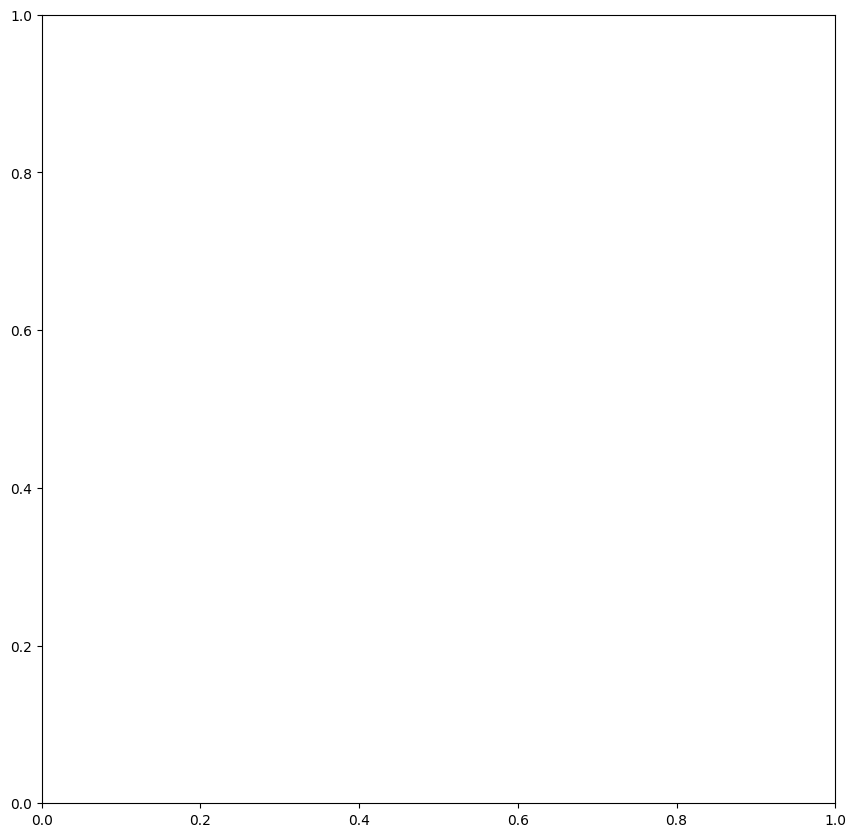

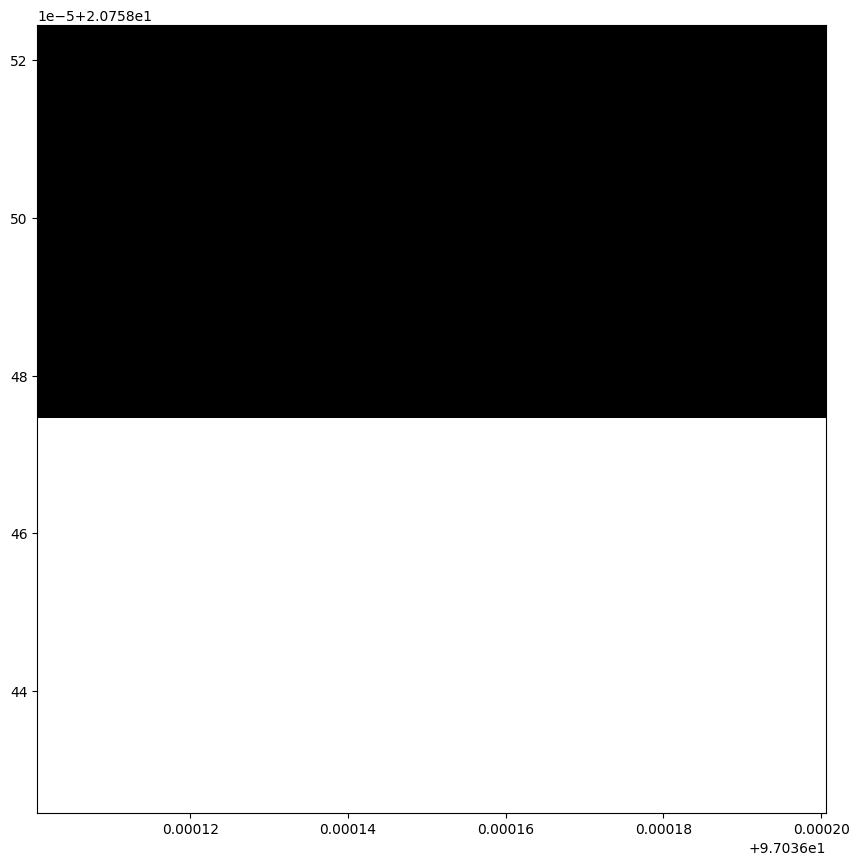

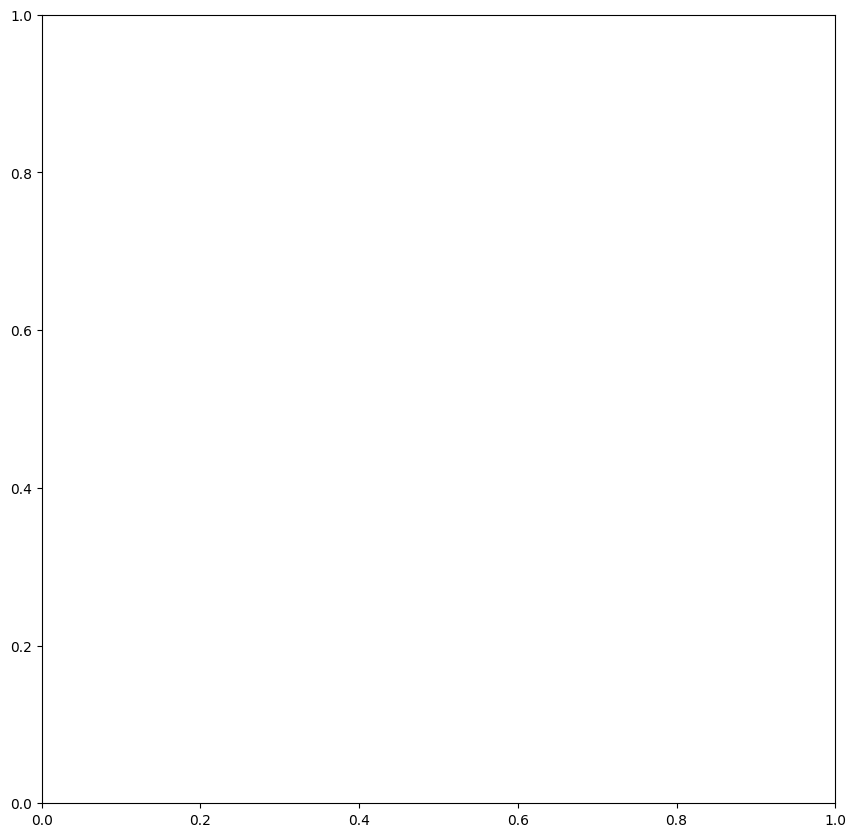

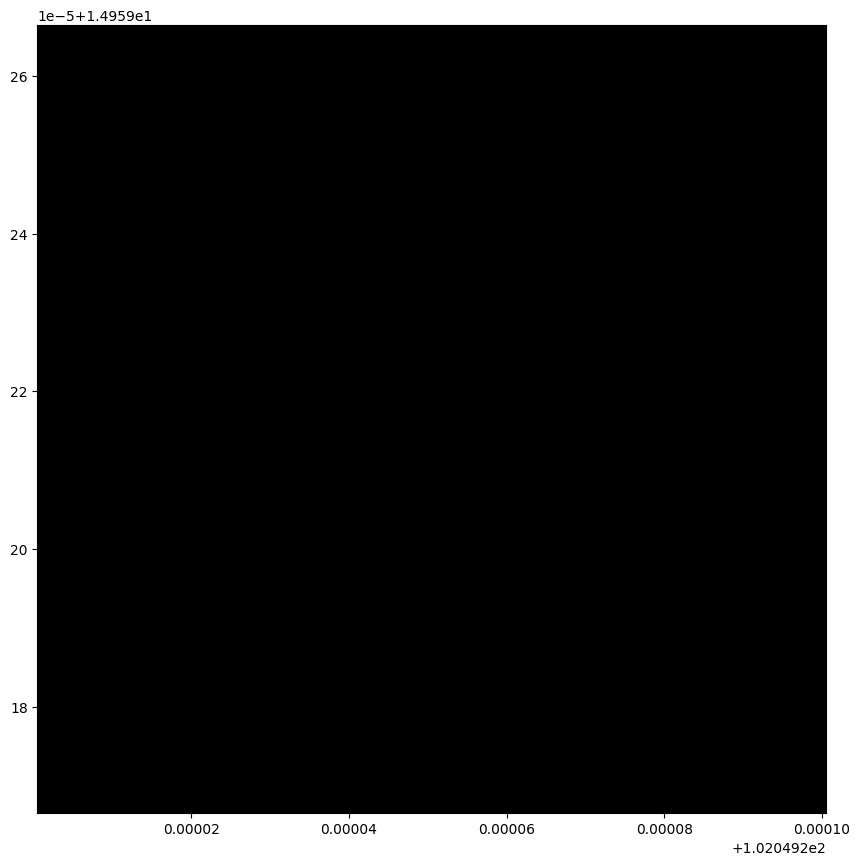

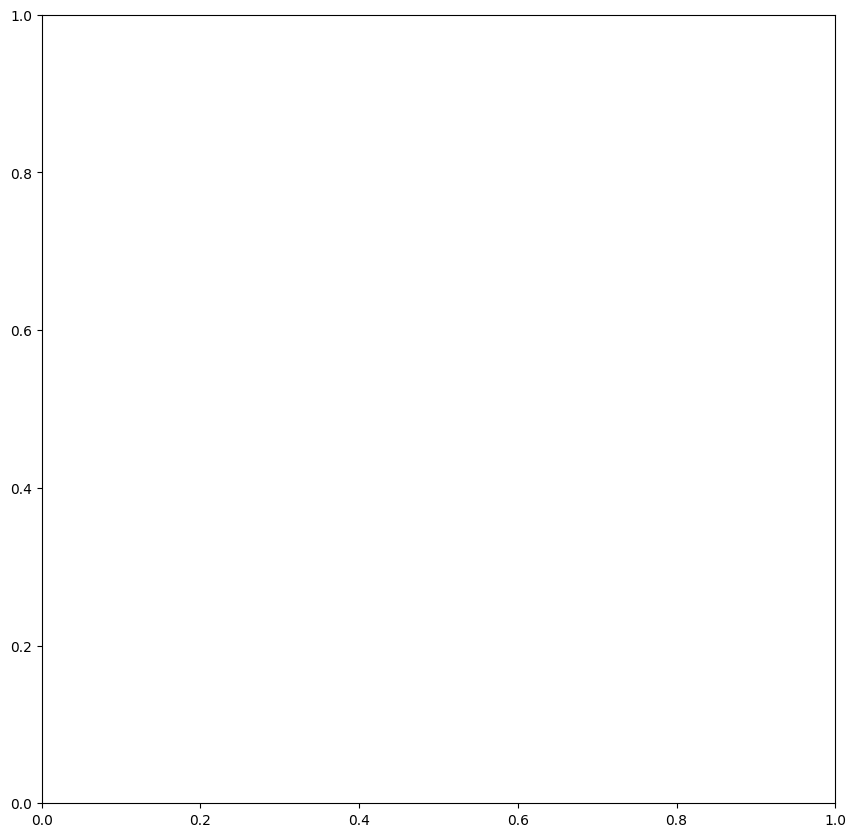

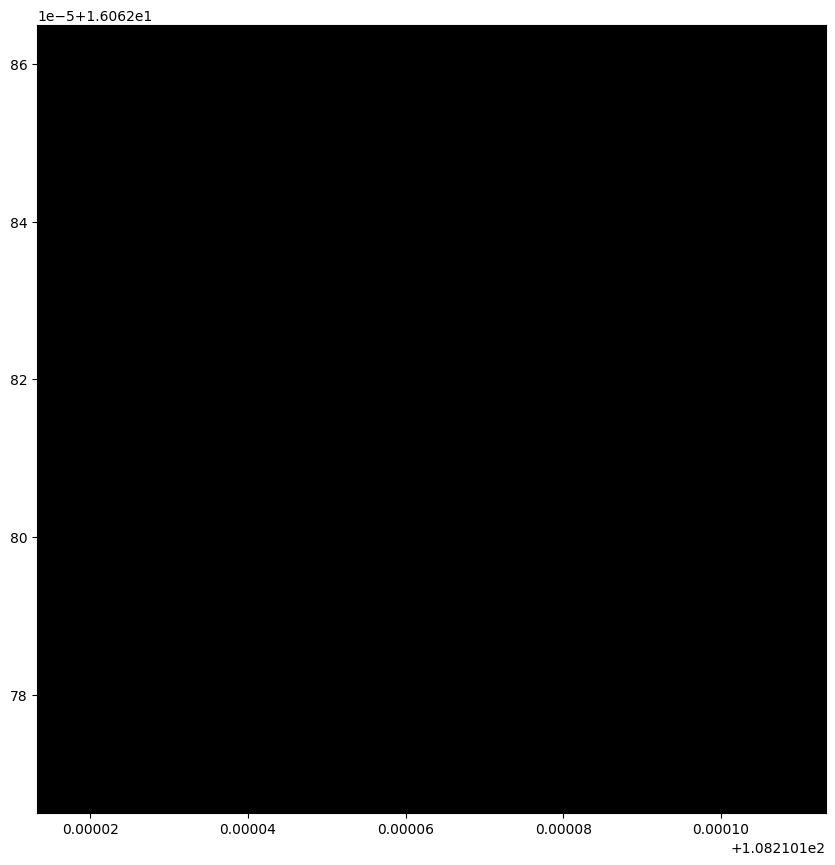

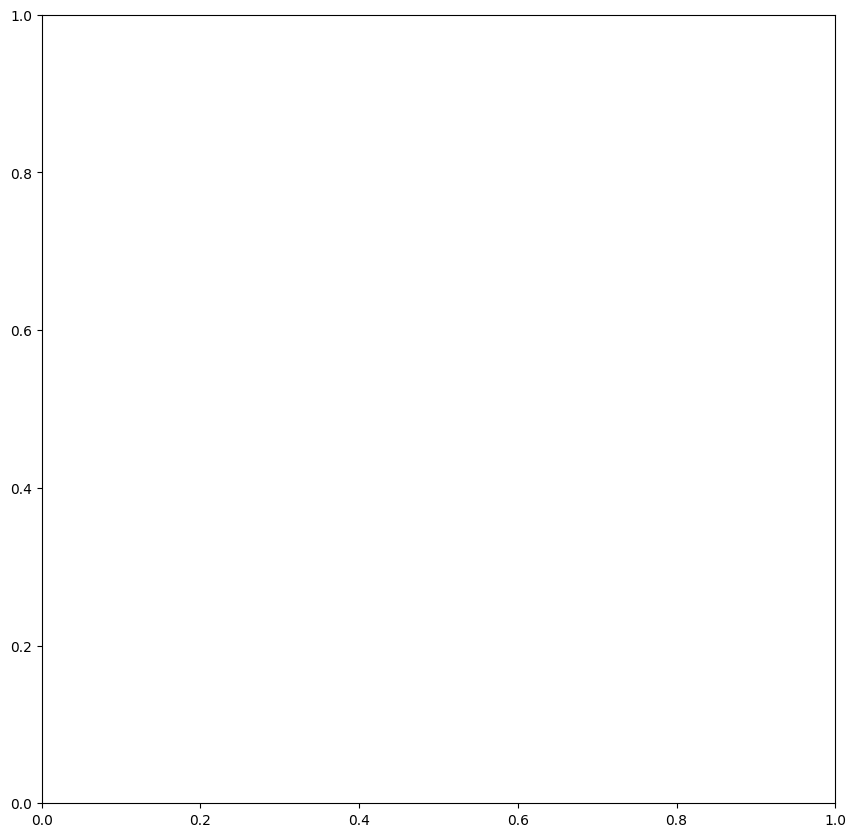

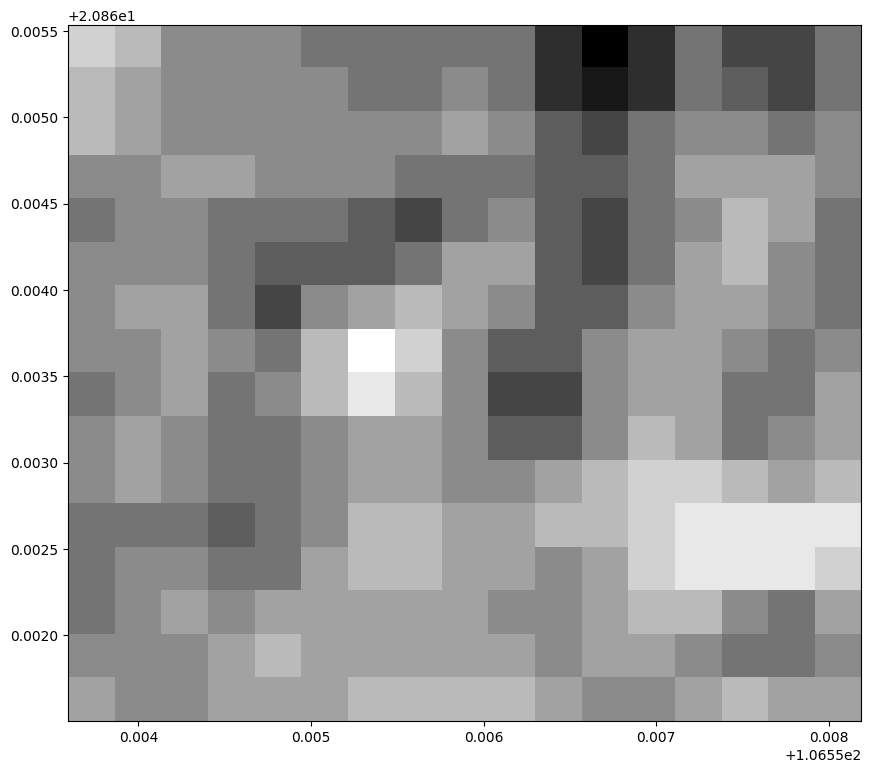

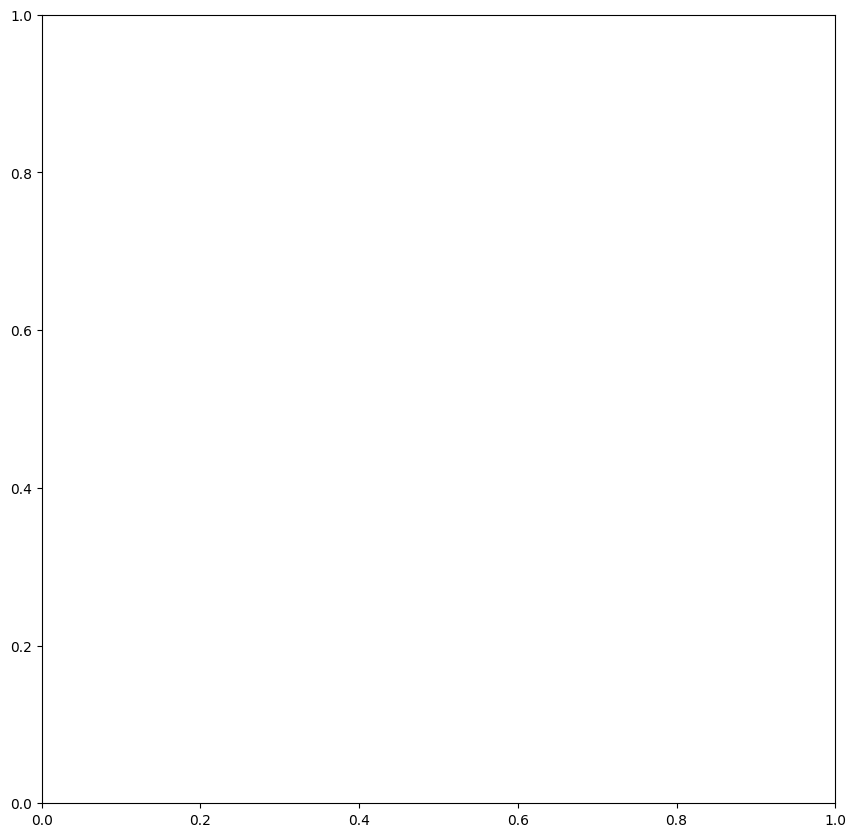

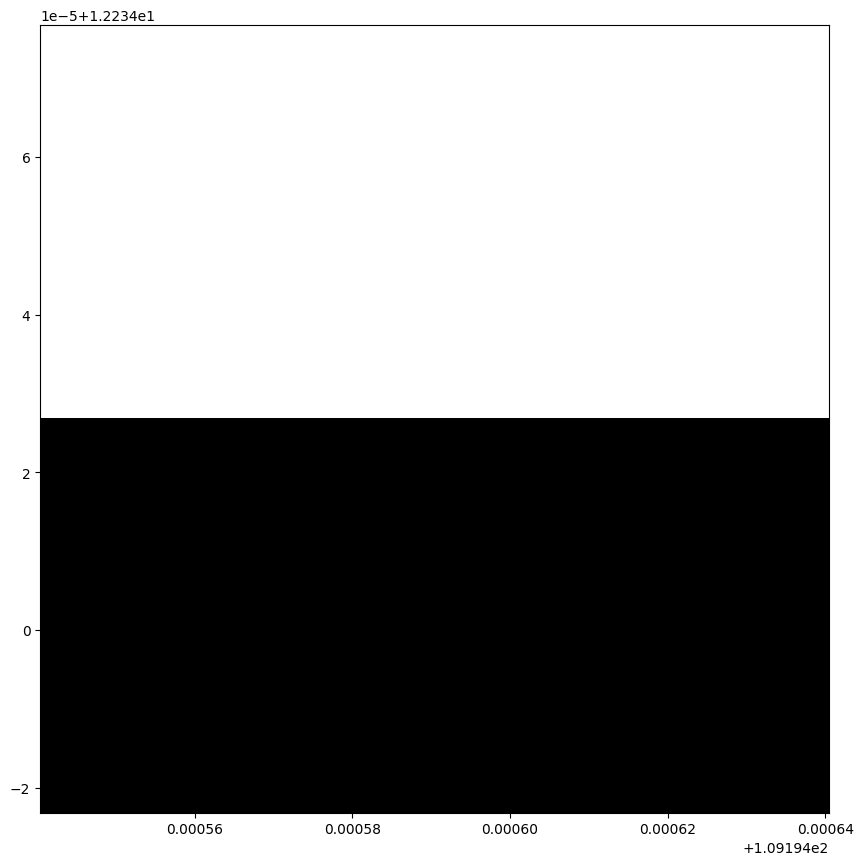

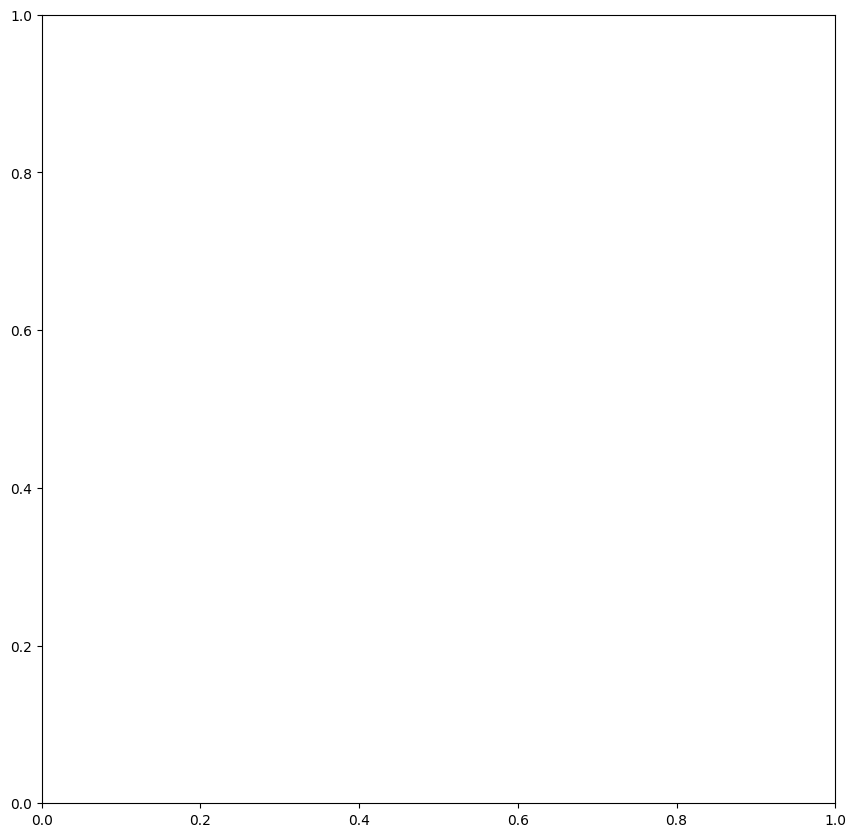

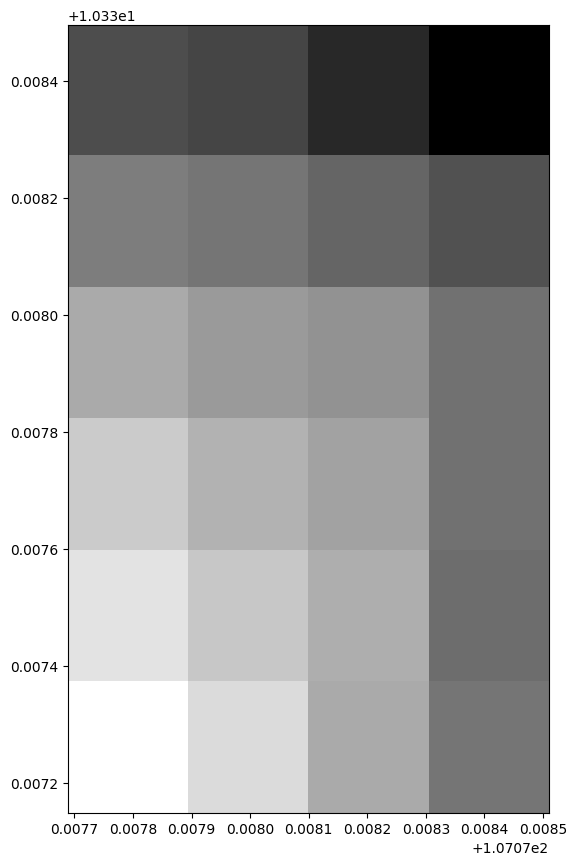

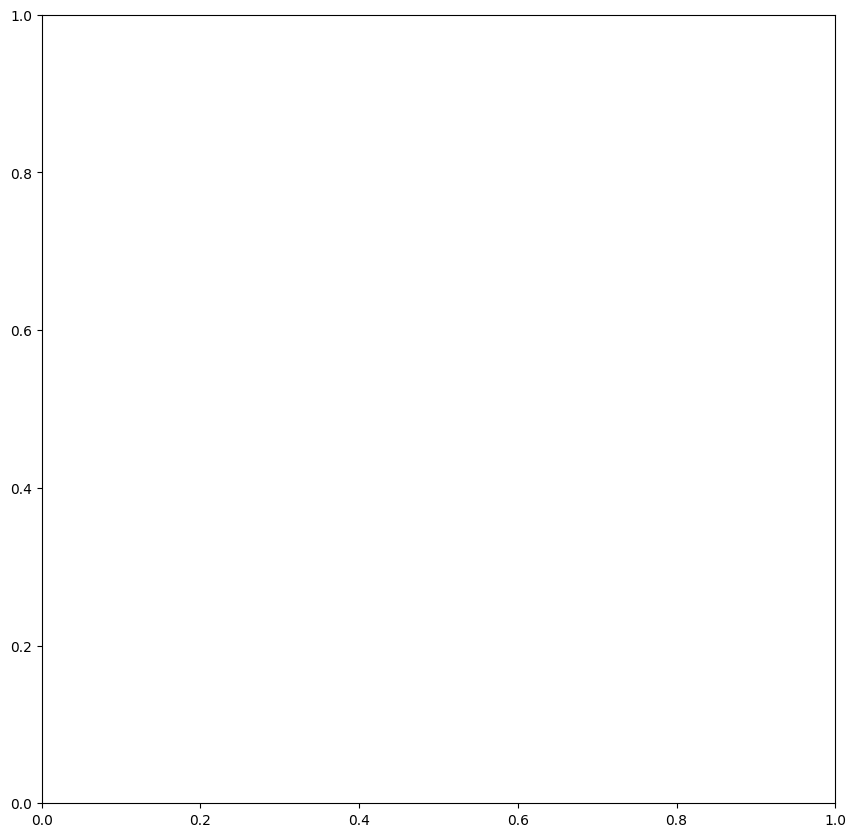

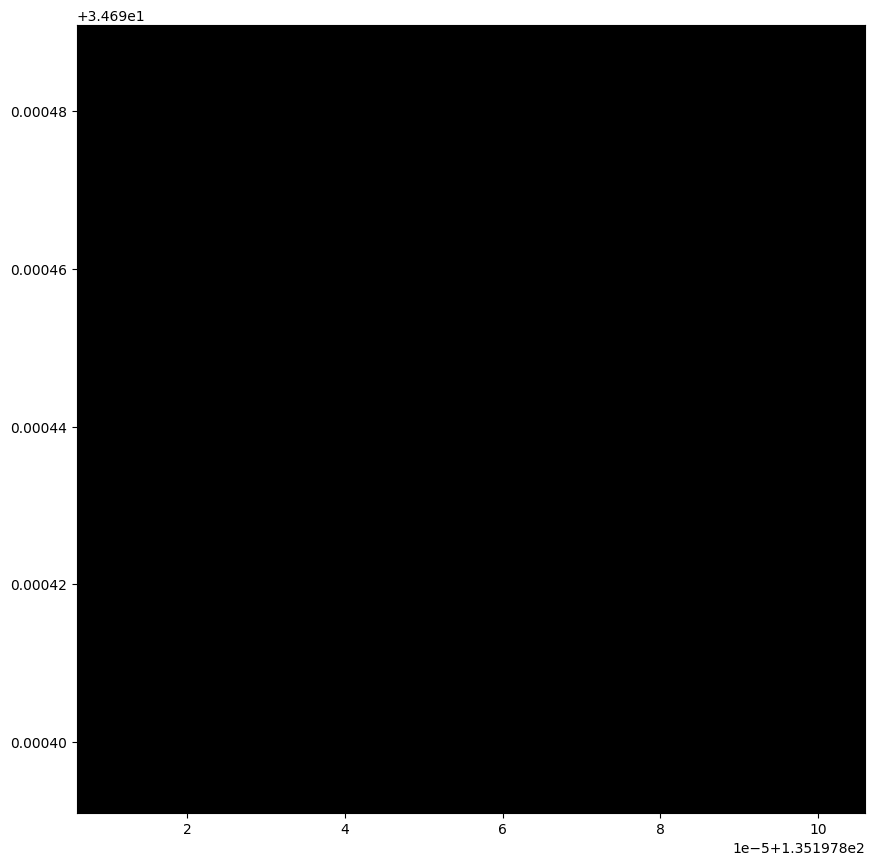

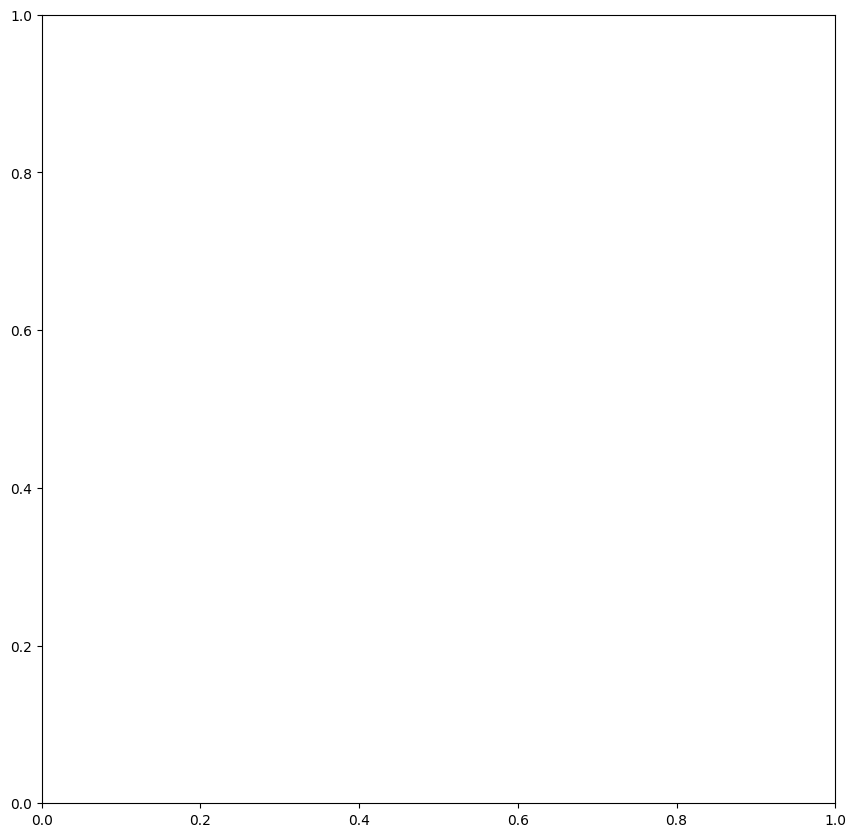

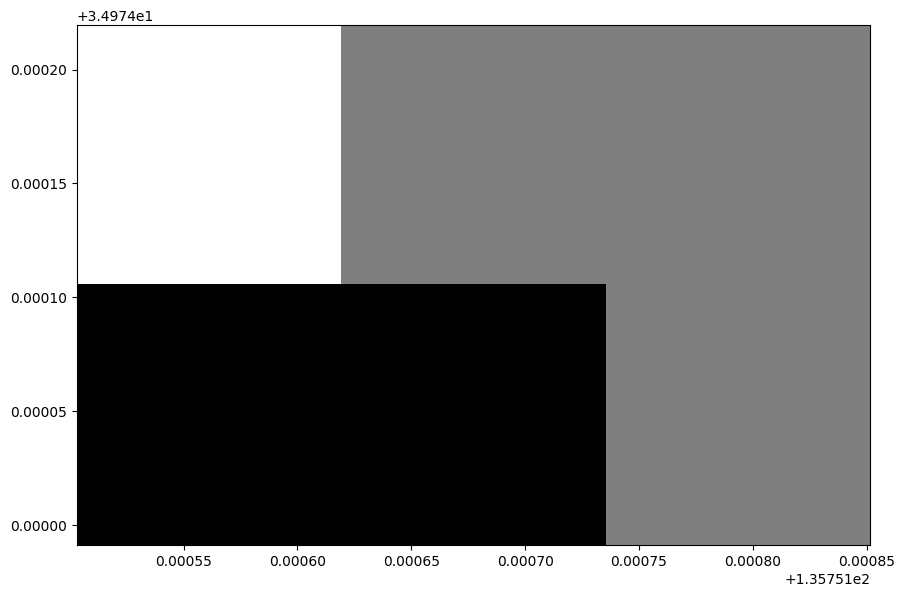

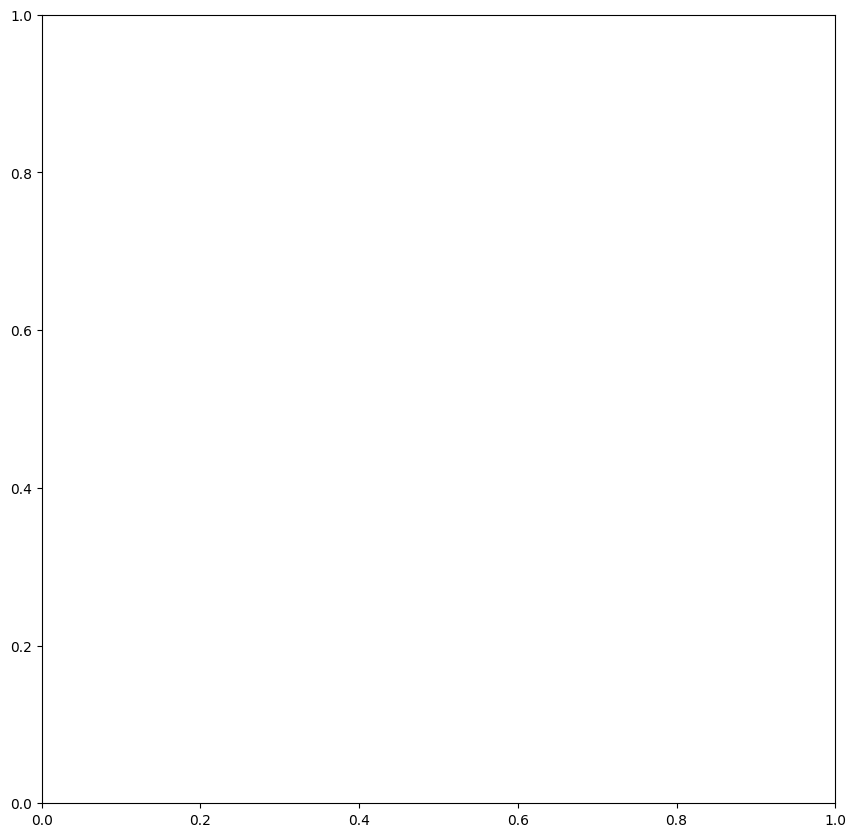

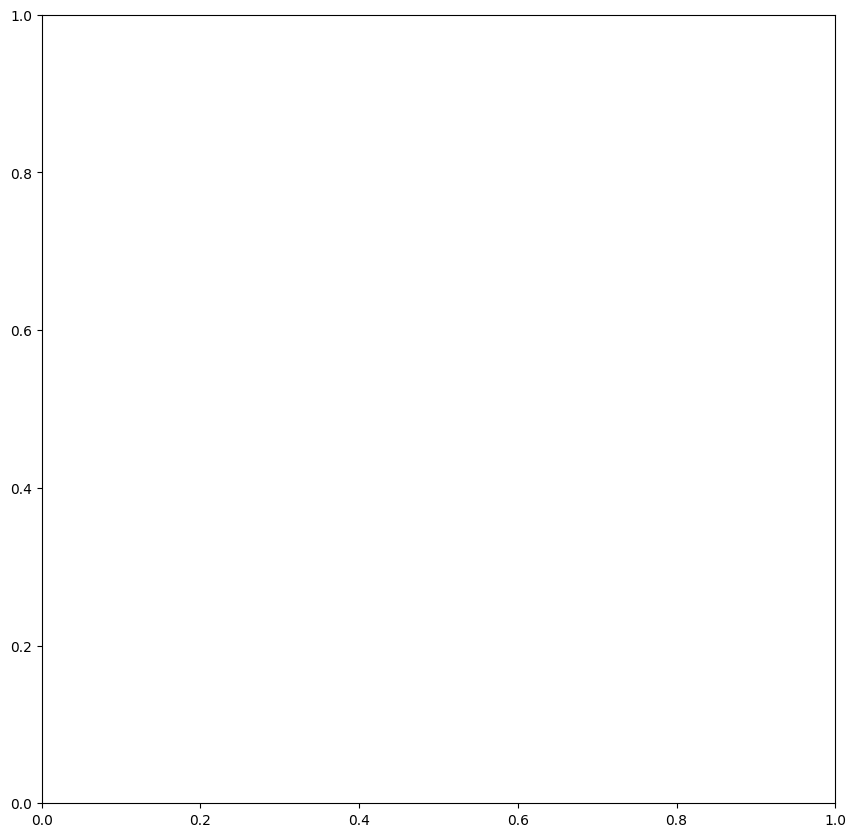

: 

In [ ]:
'''for file_name in file_names:
    # Use regex to extract the city name by removing "_elevation.png"
    match = re.match(r"^(.*)_elevation\.png$", file_name)
    if match:
        city_name = match.group(1)  # Extract the city name'''
for region in world_regions:
    for countries in region:
        for city_name in countries:
            print(f"Initializing CityMapProcessor for city: {city_name}")

            output_dir = "/home/salvador_cb/3_term/Applied_research_studio/data/img/train"
            elevation_path = os.path.join(output_dir, f"elevation/{city_name}_elevation.png")
            street_layout_path = os.path.join(output_dir, f"street/{city_name}_street_network.png")
            overlap_path = os.path.join(output_dir, f"overlap/{city_name}_overlap.png")

            # Check if all images already exist
            if os.path.exists(elevation_path) and os.path.exists(street_layout_path) and os.path.exists(overlap_path):
                print(f"Images for {city_name} already exist. Skipping...")
                continue
            
            # Initialize the class with the city name
            city_processor = CityMapProcessor(city_name)
            city_processor.process()